# Reporting — granular varieties, comparative advantage at the attraction-area level

Companion to `analysis.ipynb` (the continuum / ZE-level reporting), for runs made with
`./run.sh <industry> --granular=true --ca_level=aa`.

What differs from the old notebook:

* the moment vector has a sixth block, $\bar G_s(0)$, and the $\gamma$ block lives at the
  **attraction-area** level rather than the ZE level;
* the combined table reports the labor share and the industry shares only;
* the cloglog distance coefficients and $\bar G_s(0)$ get their own figures, empirical
  against simulated, **with standard errors**;
* the Jacobian and the moment variance-covariance matrices get block-structured
  heatmaps, so which parameter block moves which moment block can be read off. The
  parameter axis now includes the **variety counts** $N_s$, on the same footing as the
  comparative advantages $T_{as}$: both are calibrated inside the model rather than
  searched over, and both belong in a picture of what the model's parameters do;
* every elasticity heatmap comes as a **triptych** — the matrix, the cells whose
  elasticity is drowned in simulation noise, and the matrix with those cells blanked —
  because an elasticity estimated from simulated moments is only readable where its
  Monte-Carlo standard deviation is small relative to its own size;
* a sensitivity / identification section thresholds the same elasticities, so the
  near-orthogonality of the $\alpha$ / $T_{as}$ / $N_s$ channels can be read off directly;
* an untargeted-moment section estimates, by Poisson pseudo-maximum-likelihood
  (`pyfixest.fepois`) on the simulated firm-level economy, the distance elasticity
  $\eta$ of $\mathbb{E}[a_{ir}]$ — under a sector $\times$ buyer-region effect, a
  **supplier** effect and both — and compares it with the reduced-form $\delta/\gamma$
  of Table 3, on the reduced form's own scale rather than as a raw elasticity;
* a comparative-advantage section weighs $T_{as}$ against distance within each sector, as
  **six tests taken one at a time**: the spread of $\hat T$, what it is worth in distance,
  whether the favoured area actually wins buyer by buyer, which force disperses the
  competition, what the Sinkhorn inversion implies for the covariance term, and the
  allocation of winners with one force switched off;
* an amplification section reproduces Figure 6 — the coefficient $D_r$ and the share
  of upstream sales within a radius of the shock, the radius being a free parameter;
* the loader takes `mu = 1` (step-1 best parameters) or `mu = 2` (step-3 best parameters).

`load_granular_data` returns a flat dict, so the `analysis.ipynb` pattern still works:

```python
data = load_granular_data(industry, mu=2)
globals().update(data)
```

**How the notebook is organised.** Every section is a pair: one cell that *defines* its
functions, one cell that *runs* it on both industries and writes its figures. Each pair
can be executed on its own, and the last cell of the notebook (`Full Run`) re-executes
all of them in order for a clean end-to-end pass. A new figure therefore has to be added
in two places: its own section's run cell, and the full run.


## Setup

In [1]:
%pip install matplotlib pandas statsmodels seaborn geopandas pyfixest pyarrow



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import statsmodels.api as sm
import pyfixest as pf          # PPML with absorbed fixed effects (ppmlhdfe)

try:
    import geopandas as gpd
except Exception:            # maps are optional in this notebook
    gpd = None
try:
    import seaborn as sns
except Exception:
    sns = None

# ---------------------------------------------------------------- style
document_width_pt = 511.0
plt.rc("font", family="serif")
toulouse_color = (132 / 255, 46 / 255, 27 / 255)
reference_color = toulouse_color#(0.75, 0.30, 0.20)
sim_color = (0.247, 0.404, 0.667)
font_size = 15
plt.rcParams.update({
    "font.size": font_size,
    "axes.labelsize": font_size,
    "axes.titlesize": font_size + 2,
    "xtick.labelsize": font_size - 3,
    "ytick.labelsize": font_size - 3,
    "legend.fontsize": font_size - 3,
    "legend.title_fontsize": font_size,
    "figure.titlesize": font_size,
})


def get_figsize(document_width_pt=document_width_pt, wf=1.0, hf=0.5):
    """Figure size in inches from a LaTeX \\showthe\\columnwidth width in points."""
    fig_width = document_width_pt * wf / 72.27
    return [fig_width, fig_width * hf]


def _despine(ax=None):
    if sns is not None:
        sns.despine(ax=ax)
    else:
        for side in ("top", "right"):
            (ax or plt.gca()).spines[side].set_visible(False)


## Loading

`load_granular_data` rebuilds on the Python side the moment layout that
`load_parameters.jl` builds under `--granular=true --ca_level=aa`. The full (unmasked)
moment vector stacks six blocks in this order:

| # | block | length | content |
|---|-------|--------|---------|
| 1 | labor          | 1 | aggregate labor share |
| 2 | industry share | $S$ | share of the downstream industry's input bill going to each sector |
| 3 | $\pi_r$        | $R_d$ | share of downstream sales made in each downstream region |
| 4 | reg_coef       | $N_{REG}$ | distance-bin coefficients of the extensive margin (cloglog) |
| 5 | $\gamma$       | $S \times n_{AA}$ | sourcing shares by (sector, attraction area), sector-major |
| 6 | $\bar G_s(0)$  | $S$ | share of regions hosting no supplier of sector $s$ |

The criterion does not use all of them. `MOMENT_MASK` drops the first industry share and
the first $\pi_r$ (both are implied by the others adding up), every (sector, area) pair
with no observed supplier, and, in each sector, the **reference area** — the one with the
largest observed sourcing share, which the within-sector adding-up constraint determines
once the others are known. Block 6 is never masked.

**Which estimate is being reported.** `mu` selects it, and it selects *everything*
consistently — moments, standard errors, Jacobian, and the simulated firm-level economy:

| `mu` | estimate | moments | inference |
|------|----------|---------|-----------|
| 1 | $\hat\theta_1$, the Step-1 identity-weighted fit | `step1/best_simulated_moments.npy` | `step2/inference/` (inference *at* $\hat\theta_1$ is written there) |
| 2 | $\hat\theta_2$, the Step-3 efficiently-weighted fit | `step3/best_simulated_moments.npy` | `step3/inference/` |

The run folder is reconstructed from the flags rather than passed as a path, so a
mismatch between the flags used for estimation and the flags used here surfaces as a
missing folder instead of a plausible-looking but wrong set of numbers.


In [3]:
# Rebuilds, on the Python side, the moment layout `load_parameters.jl` builds under
# `--granular=true --ca_level=aa`, and reads back everything the reporting needs.
# The block layout, the mask and the meaning of `mu` are documented in the markdown
# cell above.

# mu -> (folder holding the moments, folder holding the inference)
MU_DIRS = {1: ("step1", "step2"), 2: ("step3", "step3")}


def reporting_folder(industry, base="..", profile_T=True, ca_level="aa",
                     granular=True, relax_n_lo=False, optimizer="pso"):
    """Reproduce main.jl's output_folder naming exactly."""
    name = f"reporting_{industry}"
    name += "_profiled" if profile_T else ""
    name += "_aa" if ca_level == "aa" else ""
    name += "_gran" if granular else ""
    name += "_nlo1" if (relax_n_lo and granular) else ""
    name += f"_{optimizer}"
    return Path(base) / name


def _read_named_value(coefs, name):
    """stats.csv scalar by name: a column called `name`, else a labelled row."""
    if name in coefs.columns:
        vals = coefs[name].dropna().values
        if len(vals):
            return float(vals[0])
    if "value" in coefs.columns:
        for col in coefs.columns:
            hit = coefs.index[coefs[col].astype(str).str.strip().str.lower() == name.lower()]
            if len(hit):
                return float(coefs.loc[hit[0], "value"])
    return None


def _gk_col(G_K, cands):
    """Column of G_K.csv by case-insensitive name, mirroring load_parameters.jl's _gk_col."""
    hit = next((c for c in G_K.columns if c.strip().lower() in cands), None)
    if hit is None:
        raise KeyError(f"G_K.csv is missing a column among {cands}; has {list(G_K.columns)}")
    return hit


def _as_ze_string(col):
    """ZE codes as 4-character strings, whether the column came back as int, float or str."""
    if pd.api.types.is_numeric_dtype(col):
        return col.astype("Int64").astype(str).str.zfill(4)
    return col.astype(str).str.strip().str.replace(r"\.0$", "", regex=True).str.zfill(4)


def _aa_names(X_dr, n_AA):
    """
    Attraction-area names, in the model's AA column order.

    AA column `a` is anchored on the a-th downstream region, and the downstream
    regions are enumerated in ZE-index (sorted ze2010) order — which is the row
    order of X_dr.csv restricted to the downstream rows. The names live in
    `X_dr.query('downstream').ze2010_downstream`.
    """
    flag = next((c for c in ("downstream", "downstream_region") if c in X_dr.columns), None)
    if flag is None:
        raise KeyError("X_dr.csv has neither a `downstream` nor a `downstream_region` column")
    sub = X_dr[X_dr[flag].astype(bool)]
    col = next((c for c in ("ze2010_downstream", "ze2010") if c in sub.columns), None)
    if col is None:
        raise KeyError("X_dr.csv has neither `ze2010_downstream` nor `ze2010`")
    names = _as_ze_string(sub[col]).tolist()
    if len(names) != n_AA:
        raise ValueError(f"{len(names)} downstream rows in X_dr.csv vs n_AA = {n_AA} "
                         "attraction areas in attraction_area_linkages.npy")
    return names


def _region_labels(data):
    """
    Model region index (1..R) -> ZE code -> display NAME.

    The model orders regions by sorted `ze2010`, exactly as `load_parameters.jl` builds
    `X_rs`, so the l-th row of the distance matrix and the integer codes in
    `suppliers.parquet` are the l-th entry of that sorted list. `france` covers more
    commuting zones than the model does, so the join is on the CODE, and a zone with no
    name falls back to its code rather than to NaN.
    """
    fdf = data.get("filter_N_upstream_df")
    if fdf is None:
        codes = [str(i) for i in range(1, data["R"] + 1)]
    else:
        codes = sorted(_as_ze_string(fdf["ze2010"]).unique())
    if len(codes) != data["R"]:
        raise ValueError(f"{len(codes)} ZE codes in filter_N_upstream.csv but R = "
                         f"{data['R']} regions in the model.")
    out = pd.DataFrame({"index": np.arange(1, data["R"] + 1), "ze2010": codes})
    fr = data.get("france")
    if fr is not None and "ze2010_name" in fr.columns:
        names = fr[["ze2010", "ze2010_name"]].copy()
        names["ze2010"] = _as_ze_string(names["ze2010"])
        out = out.merge(names.drop_duplicates("ze2010"), on="ze2010", how="left")
    else:
        out["ze2010_name"] = out["ze2010"]
    out["ze2010_name"] = out["ze2010_name"].fillna(out["ze2010"])
    return out


def ze_name_of_code(data):
    """ZE code -> display name, for anything keyed on the code rather than the index."""
    lab = _region_labels(data)
    return dict(zip(lab["ze2010"], lab["ze2010_name"]))


def aa_display_names(data):
    """
    Attraction-area display names, in AA column order.

    Area `a` is anchored on the a-th downstream region, so its name is that commuting
    zone's name — which is what a reader recognises, unlike the bare ZE code.
    """
    m = ze_name_of_code(data)
    return [m.get(str(a), str(a)) for a in data["aa_names"]]


def load_granular_data(industry, mu=2, base="..", profile_T=True, ca_level="aa",
                       granular=True, relax_n_lo=False, optimizer="pso", K=-1):
    """
    Load everything the granular / attraction-area reporting needs.

    Parameters
    ----------
    industry : str          "aero", "auto", ...
    mu       : 1 or 2       1 = step1 best parameters (mu_1), 2 = step3 best
                            parameters (mu_2, the efficient estimate).
    K        : int          which stage column of best_simulated_moments to read
                            (-1 = the last, i.e. the final stage of the step).

    Returns a flat dict meant to be splatted into the namespace, exactly like
    `load_industry_data` in analysis.ipynb:

        data = load_granular_data(industry, mu=2)
        globals().update(data)        # in a script / notebook cell

    which binds `input_folder`, `folder`, `coefs`, `agg_labor_share`, `epsilon`,
    `agg_industry_share`, `emp_pi_r`, `reg_coef`, `emp_gamma_ls`, `X_dr`, `X_rs`,
    `filter_N_upstream_df`, `distances`, `france`, `ref`, `idf_ze`, `N_downstream`,
    `regional_wage`, `best_params`, `best_simulated_moments`,
    `suppliers`, `empirical_moments`, `empirical_moments_dict`
    and `best_simulated_moments_dict` under the same names the old notebook used —
    plus the granular / attraction-area additions (`emp_gamma_aa`, `AA_ACTIVE`,
    `CELL_MASK`, `aa_of_ze`, `aa_names`, `T_REF_AA`, `G_target`, `se_empirical`,
    `se_simulated`, `granular_diagnostics`, ...). The gamma blocks are at the
    ATTRACTION-AREA level and keyed `gamma_aa`, not `emp_gamma_ls`.
    """
    if mu not in MU_DIRS: # Load the best parameter index, either one or two. 
        raise ValueError(f"mu must be 1 (step1) or 2 (step3), got {mu}")
    step_dir, inf_step = MU_DIRS[mu]

    input_folder = Path(base) / f"baseline_{industry}"
    folder = reporting_folder(industry, base=base, profile_T=profile_T, ca_level=ca_level, 
                              granular=granular, relax_n_lo=relax_n_lo, optimizer=optimizer) # Given the argument, construct the folder name. 
    if not folder.exists():
        raise FileNotFoundError(f"run folder {folder} not found — check profile_T / ca_level / "
                                "granular / relax_n_lo / optimizer against main.jl's naming")

    n_coef = int(np.load(folder / "n_reg_coef.npy")) # Number of regression coefficients. 
    n_tau_path = folder / "n_tau.npy" 
    n_tau = int(np.load(n_tau_path)) if n_tau_path.exists() else n_coef  # Number of coefficients parametrizing the trade costs.  

    # ---------------------------------------------------------------- targets
    coefs = pd.read_csv(input_folder / "stats.csv")
    epsilon = coefs.loc[0, "value"]
    agg_labor_share = coefs.loc[1, "value"]

    agg_industry_share = np.load(input_folder / "input_share.npy").ravel()
    emp_gamma_ls = np.load(input_folder / "emp_gamma_ls.npy")          # (S, R)
    filter_N_upstream = np.load(input_folder / "filter_N_upstream.npy")  # (S, R), binary
    X_rs = np.load(input_folder / "X_rs.npy")                          # (S, R)
    domestic_share = np.load(input_folder / "domestic_share.npy").ravel()
    N_downstream = np.load(input_folder / "N_downstream_per_region.npy").ravel()
    S, R = filter_N_upstream.shape

    X_dr = pd.read_csv(input_folder / "X_dr.csv")
    if "ze2010" in X_dr.columns:
        X_dr["ze2010"] = _as_ze_string(X_dr["ze2010"])
    emp_pi_r = X_dr["X_dr"].values[N_downstream != 0].astype(float)
    emp_pi_r = emp_pi_r / emp_pi_r.sum()

    if n_coef == 1:
        reg_coef = np.array([_read_named_value(coefs, "reg_coef_cloglog_1")], dtype=float)
    else:
        reg_coef = np.load(input_folder / f"reg_coef_cloglog_{n_coef}.npy").ravel()

    # ------------------------------------------------- attraction-area mapping
    AA_link = np.load(input_folder / "attraction_area_linkages.npy")   # (R, R_downstream)
    if AA_link.shape[0] != R:
        raise ValueError(f"attraction_area_linkages.npy is {AA_link.shape}, expected ({R}, R_d)")
    if not np.all(AA_link.sum(axis=1) == 1):
        raise ValueError("every ZE must belong to exactly one attraction area")
    aa_of_ze = AA_link.argmax(axis=1)          # 0-based AA index per ZE
    n_AA = AA_link.shape[1]
    aa_names = _aa_names(X_dr, n_AA)

    # 𝒜⁺_s : (sector, AA) hosting at least one observed supplier; CELL_MASK: simulated cells
    supplier_cells = (filter_N_upstream == 1) & (X_rs > 0)
    AA_ACTIVE = np.zeros((S, n_AA), dtype=bool)
    for s in range(S):
        AA_ACTIVE[s, aa_of_ze[supplier_cells[s]]] = True
    CELL_MASK = (filter_N_upstream == 1) & AA_ACTIVE[:, aa_of_ze]

    # gamma target at the AA level: sum over EVERY cell of the area, controls included
    emp_gamma_aa = np.zeros((S, n_AA))                                 # (S, n_AA)
    for s in range(S):
        np.add.at(emp_gamma_aa[s], aa_of_ze[CELL_MASK[s]], emp_gamma_ls[s][CELL_MASK[s]])

    # reference AA per sector = largest empirical share among the active columns
    T_REF_AA = np.full(S, -1, dtype=int)
    for s in range(S):
        act = np.flatnonzero(AA_ACTIVE[s])
        if act.size:
            T_REF_AA[s] = act[np.argmax(emp_gamma_aa[s, act])]

    # ------------------------------------------------------------- count moment
    G_target = np.full(S, np.nan)
    N_supplier_s = np.full(S, np.nan)
    sector_codes = None
    gk_path = input_folder / "G_K.csv"
    if granular:
        # G_K.csv is `group, A129, G, K, N_supplier_s`: `G` is the value column,
        # G = Pr(K_ls <= K), and the K = 0 row is the targeted moment Gbar_s(0).
        # Names are matched case-insensitively, as load_parameters.jl does.
        G_K = pd.read_csv(gk_path)
        c_sector = _gk_col(G_K, ("a129", "sector"))
        c_K = _gk_col(G_K, ("k",))
        c_G = _gk_col(G_K, ("g",))
        c_N = _gk_col(G_K, ("n_supplier_s", "n_supplier", "n_suppliers"))
        sector_codes = sorted(G_K[c_sector].unique())
        if len(sector_codes) != S:
            raise ValueError(f"G_K.csv covers {len(sector_codes)} sectors, expected S = {S}")
        for s, code in enumerate(sector_codes):
            sub = G_K[G_K[c_sector] == code]
            row = sub[sub[c_K].astype(float).round().astype(int) == 0]
            if row.empty:
                raise ValueError(f"G_K.csv has no K=0 row for A129={code}")
            G_target[s] = float(row[c_G].values[0])
            N_supplier_s[s] = float(pd.unique(sub[c_N])[0])

    # sector names, in the model's 1..S order (sorted A129), as in load_parameters.jl
    fdf_path = input_folder / "filter_N_upstream.csv"
    if fdf_path.exists():
        filter_N_upstream_df = pd.read_csv(fdf_path)
        filter_N_upstream_df["ze2010"] = filter_N_upstream_df["ze2010"].astype(str).str.zfill(4)
        sector_names = [str(a) for a in sorted(filter_N_upstream_df["A129"].unique())]
    else:
        filter_N_upstream_df = None
        sector_names = [str(s + 1) for s in range(S)]
    if len(sector_names) != S:
        sector_names = [str(s + 1) for s in range(S)]

    # ------------------------------------------------ FULL empirical moment vector
    blocks_emp = [np.array([agg_labor_share], dtype=float),
                  agg_industry_share.astype(float),
                  emp_pi_r,
                  reg_coef.astype(float),
                  emp_gamma_aa.ravel()]            # C-order on (S, n_AA) == Julia vec((n_AA, S))
    if granular:
        blocks_emp.append(G_target)
    block_sizes = [b.size for b in blocks_emp]
    empirical_moments_full = np.concatenate(blocks_emp)

    # MOMENT_MASK, exactly as load_parameters.jl builds it
    mask = np.ones(empirical_moments_full.size, dtype=bool)
    # Indices at where each moment starts.
    off_ind, off_pi = 1, 1 + S
    off_reg = off_pi + emp_pi_r.size
    off_gam = off_reg + reg_coef.size
    mask[off_ind] = False                              # first industry share
    mask[off_pi] = False                               # first pi_r
    mask[off_gam:off_gam + S * n_AA] = AA_ACTIVE.ravel()
    for s in range(S):
        if T_REF_AA[s] >= 0:
            mask[off_gam + s * n_AA + T_REF_AA[s]] = False

    # ------------------------------------------------------- simulated moments
    sim_path = folder / step_dir / "best_simulated_moments.npy"
    if not sim_path.exists():
        raise FileNotFoundError(
            f"{sim_path} not found. main.jl writes it via run_reporting(<run>/{step_dir}); "
            "for mu = 2 the step-3 reporting call must have run.")
    best_simulated_moments = np.load(sim_path)
    if best_simulated_moments.ndim == 1:
        best_simulated_moments = best_simulated_moments[:, None]
    if best_simulated_moments.shape[0] != empirical_moments_full.size:
        raise ValueError(
            f"simulated moment vector has {best_simulated_moments.shape[0]} rows but the "
            f"empirical layout has {empirical_moments_full.size}. The run's "
            "granular/ca_level flags and the ones passed here disagree.")
    sim_vec = best_simulated_moments[:, K]

    keys = ["agg_labor_share", "agg_industry_share", "emp_pi_r", "reg_coef", "gamma_aa"] # Moment name
    if granular:
        keys.append("G0")
    edges = np.cumsum(block_sizes)[:-1]
    emp_blocks = dict(zip(keys, np.split(empirical_moments_full, edges)))
    sim_blocks = dict(zip(keys, np.split(sim_vec, edges)))
    emp_blocks["gamma_aa"] = emp_blocks["gamma_aa"].reshape(S, n_AA)
    sim_blocks["gamma_aa"] = sim_blocks["gamma_aa"].reshape(S, n_AA)

    # All stages, block by block, with the STAGE axis last — the layout
    # analysis.ipynb's `best_simulated_moments_dict[key][..., K]` expects.
    stage_blocks = {}
    for k, b in zip(keys, np.split(best_simulated_moments, edges, axis=0)):
        stage_blocks[k] = (b.reshape(S, n_AA, b.shape[1]) if k == "gamma_aa" else b)

    best_parameters_list, best_params = None, None
    bp_path = folder / step_dir / "best_parameters_list.npy"
    if bp_path.exists():
        best_parameters_list = np.load(bp_path)
        best_params = best_parameters_list[:, K] if best_parameters_list.ndim > 1 \
            else best_parameters_list

    # --------------------------------------------------------- standard errors
    # The inference subsystem stacks three moment blocks in a fixed order — the
    # extensive-margin coefficients, the sourcing shares, the zero-supplier shares (the
    # "beta, gamma, G" ordering invariant of CLAUDE.md; the arrows used elsewhere in the
    # code name that stacking order, nothing causal).
    #   Sigma_data       : the bootstrap covariance of the EMPIRICAL moments — how
    #                      precisely each target is measured in the data;
    #   se_moments_fitted: sqrt(diag(G V G')), the SE of the FITTED moment. Under
    #                      profile_T, V is the SANDWICH covariance of alpha_hat and G the
    #                      PROFILED Jacobian dm/dalpha (alpha moved, T following through
    #                      the Sinkhorn inversion), so this is the delta-method
    #                      propagation of alpha_hat's sandwich SE — not an efficient SE
    #                      from the free-parameter Jacobian, which under profiling would
    #                      treat T as free when it is not.
    n_gamma_kept = int(mask[off_gam:off_gam + S * n_AA].sum())
    n_gb = reg_coef.size + n_gamma_kept + (S if granular else 0)

    def _gb_split(v, what):
        v = np.asarray(v).ravel()
        if v.size != n_gb:
            raise ValueError(f"{what} has length {v.size}, expected n_gb = {n_gb} "
                             f"(= {reg_coef.size} beta + {n_gamma_kept} gamma"
                             + (f" + {S} G0)" if granular else ")"))
        out = {"reg_coef": v[:reg_coef.size],
               "gamma_aa": v[reg_coef.size:reg_coef.size + n_gamma_kept]}
        if granular:
            out["G0"] = v[-S:]
        return out

    se_emp, se_sim = None, None
    sigma_path = folder / "step2" / "Sigma_data.npy"
    if sigma_path.exists():
        Sigma_data = np.load(sigma_path)
        se_emp = _gb_split(np.sqrt(np.maximum(np.diag(Sigma_data), 0.0)), "diag(Sigma_data)")
    else:
        Sigma_data = None
    fitted_path = folder / inf_step / "inference" / "se_moments_fitted.npy"
    if fitted_path.exists():
        se_sim = _gb_split(np.load(fitted_path), "se_moments_fitted.npy")

    # ----------------------------------------- moment and parameter labels ----
    # Both axes of the Jacobian, rebuilt exactly as load_parameters.jl SECTION 13 does.
    #   rows    : the MASKED moment vector, six blocks;
    #   columns : the IDENTIFIED parameters, layout [Omega_L | Omega_s(S) | A(R_d) |
    #             alpha(N_TAU) | T(active (s,AA), s-major)], minus the S+2 directions
    #             the internal normalisations kill (Omega_s[1], A[1], each sector's
    #             reference T).
    moment_labels, moment_block_sizes = [], []
    moment_labels.append("labor")
    moment_block_sizes.append(1)
    moment_labels += [f"Omega_s[{sector_names[s]}]" for s in range(1, S)]
    moment_block_sizes.append(S - 1)
    moment_labels += [f"pi_r[{a}]" for a in aa_names[1:]]
    moment_block_sizes.append(len(aa_names) - 1)
    moment_labels += ([f"reg_coef[{b + 1}]" for b in range(n_coef)] if n_coef > 1
                      else ["reg_coef"])
    moment_block_sizes.append(n_coef)
    gam_free = AA_ACTIVE.copy()
    for s in range(S):
        if T_REF_AA[s] >= 0:
            gam_free[s, T_REF_AA[s]] = False
    moment_labels += [f"gamma[{sector_names[s]}-AA{aa_names[a]}]"
                      for s in range(S) for a in range(n_AA) if gam_free[s, a]]
    moment_block_sizes.append(int(gam_free.sum()))
    if granular:
        moment_labels += [f"G0[{sector_names[s]}]" for s in range(S)]
        moment_block_sizes.append(S)

    param_labels, param_block_sizes = [], []
    param_labels.append("Omega_L")
    param_block_sizes.append(1)
    param_labels += [f"Omega_s[{sector_names[s]}]" for s in range(1, S)]   # Omega_s[1] normalised out
    param_block_sizes.append(S - 1)
    param_labels += [f"A[{a}]" for a in aa_names[1:]]                      # A[1] normalised out
    param_block_sizes.append(len(aa_names) - 1)
    param_labels += (["alpha"] if n_tau == 1 else [f"alpha_{b + 1}" for b in range(n_tau)])
    param_block_sizes.append(n_tau)
    param_labels += [f"T[{sector_names[s]}-AA{aa_names[a]}]"
                     for s in range(S) for a in range(n_AA) if gam_free[s, a]]
    param_block_sizes.append(int(gam_free.sum()))

    moment_block_names = ["Labor share", "Industry shares", "Downstream sales",
                          "Extensive margin", "Regional sourcing shares"] \
        + (["Zero-supplier share"] if granular else [])
    param_block_names = ["Omega_L", "Industry shares", "Productivity",
                         "Trade cost", "Comparative advantage"]

    # ------------------------------------------------------------- Jacobian ---
    # Rows = the masked moments, columns = the parameters. The full free-parameter
    # Jacobian is saved for diagnostics at both estimates, even under profile_T (where
    # INFERENCE runs on the alpha-only profiled Jacobian instead).
    #
    # Under GRANULAR the Julia side appends the S VARIETY-COUNT columns dm/dN_s on the
    # right (compute_jacobian's `append_N_s`): N_s is calibrated by the integer bisection
    # exactly as T is calibrated by the Sinkhorn inversion, so both belong on the
    # parameter axis. `<file>_n_s_columns.npy` records how many were appended; older
    # trees have none, and the width settles it.
    jac_file = "jacobian_all.npy" if mu == 1 else "jacobian_all_step3.npy"
    jac_dir = folder / inf_step
    jac = {}
    for key, suffix in (("J", ""), ("J_elast", "_elasticity"),
                        ("J_sd", "_sd"), ("J_elast_sd", "_elasticity_sd"),
                        ("jacobian_param_indices", "_param_indices")):
        p = jac_dir / jac_file.replace(".npy", f"{suffix}.npy")
        jac[key] = np.load(p) if p.exists() else None
    n_N_path = jac_dir / jac_file.replace(".npy", "_n_s_columns.npy")
    n_N_cols = int(np.load(n_N_path).ravel()[0]) if n_N_path.exists() else None
    if jac["J"] is not None:
        n_r, n_c = jac["J"].shape
        if n_N_cols is None:
            n_N_cols = n_c - len(param_labels)
        if (n_r != int(mask.sum()) or n_c != len(param_labels) + n_N_cols
                or n_N_cols not in (0, S)):
            raise ValueError(
                f"{jac_file} is {n_r}x{n_c} but the layout rebuilt here is "
                f"{int(mask.sum())} moments x {len(param_labels)} parameters "
                f"(+{n_N_cols} variety counts) — the run's flags and the ones passed "
                "here disagree.")
        if n_N_cols:
            param_labels += [f"N_s[{sector_names[s]}]" for s in range(S)]
            param_block_sizes.append(S)
            param_block_names.append("Variety count")
    else:
        n_N_cols = n_N_cols or 0

    # --------------------------------------------------- variance-covariance ---
    # Sigma_data (bootstrap, empirical) and Sigma_sim (K re-simulations) over the same
    # three-block subsystem; Omega = Sigma_data + Sigma_sim is what the estimator
    # actually weighted with, and W_step3 = inv(Omega).
    def _npy(p):
        return np.load(p) if p.exists() else None

    Sigma_sim = _npy(folder / "step2" / "Sigma_sim.npy")
    Omega = _npy(folder / "step2" / "Omega.npy")
    W_step3 = _npy(folder / "step2" / "W_step3.npy")
    if Omega is None and Sigma_data is not None and Sigma_sim is not None:
        Omega = Sigma_data + Sigma_sim

    # ------------------------------------------------- granular diagnostics
    granular_diag = None
    diag_path = folder / inf_step / "granular_diagnostics.npz"
    if granular and diag_path.exists():
        with np.load(diag_path) as z:
            granular_diag = {k: z[k] for k in z.files}

    # ------------------------------- optional artefacts (geography, panels) -----
    # Everything below is best-effort: it is what the DOWNSTREAM cells of the old
    # notebook reach for after `globals().update(data)`, and none of it is needed by
    # the moment reporting, so a missing file leaves a None rather than failing.
    idf_ze = ['1101', '1111', '1102', '1104', '1118', '1115', '1116', '1105',
              '1117', '1110', '1119', '1112', '1103', '1109', '1106', '1114',
              '1113', '1108', '1107']

    def _opt(fn, *a, **kw):
        try:
            return fn(*a, **kw)
        except Exception:
            return None

    distances = _opt(np.load, input_folder / "full_distances.npy")
    regional_wage = _opt(np.load, input_folder / "regional_wages.npy")
    france = None if gpd is None else _opt(
        lambda: gpd.read_file(input_folder / "france.gpkg", encoding="utf-8").sort_values(by="ze2010"))
    ref = None
    if france is not None and distances is not None:
        def _build_ref():
            n = len(france)
            r = pd.DataFrame(distances[:n, :n], index=france["ze2010"].values,
                             columns=france["ze2010"].values).reset_index()
            r.rename(columns={"index": "ze2010_i"}, inplace=True)
            return r.melt(id_vars="ze2010_i", var_name="ze2010_j", value_name="M_ij")
        ref = _opt(_build_ref)

    # Firm-level artefacts. main.jl writes them into the STEP folder of the estimate
    # they were computed at — step1 for theta_hat_1, step3 for theta_hat_2 — so `mu`
    # selects the simulated economy exactly as it selects the moments and the inference.
    suppliers_path = folder / step_dir / "suppliers.parquet"
    suppliers = _opt(pd.read_parquet, suppliers_path) if suppliers_path.exists() else None
    w_srd_r_path = folder / step_dir / "w_srd_r.npy"
    w_srd_r = _opt(np.load, w_srd_r_path) if w_srd_r_path.exists() else None

    return {
        # identity / paths
        "industry": industry, "mu": mu, "K": K,
        "input_folder": input_folder, "folder": folder,
        "step_dir": step_dir, "inference_step": inf_step,
        "granular": granular, "ca_level": ca_level,
        # dimensions
        "S": S, "R": R, "n_AA": n_AA, "n_coef": n_coef, "n_tau": n_tau,
        "sector_names": sector_names, "sector_codes": sector_codes, "aa_names": aa_names,
        # structure
        "aa_of_ze": aa_of_ze, "AA_ACTIVE": AA_ACTIVE, "CELL_MASK": CELL_MASK,
        "T_REF_AA": T_REF_AA, "domestic_share": domestic_share,
        "filter_N_upstream": filter_N_upstream, "filter_N_upstream_df": filter_N_upstream_df,
        "X_rs": X_rs, "X_dr": X_dr, "emp_gamma_ls": emp_gamma_ls,
        # scalars / targets
        "epsilon": epsilon, "agg_labor_share": agg_labor_share,
        "agg_industry_share": agg_industry_share, "emp_pi_r": emp_pi_r,
        "reg_coef": reg_coef, "G_target": G_target, "N_supplier_s": N_supplier_s,
        "emp_gamma_aa": emp_gamma_aa, "coefs": coefs,
        "d": "C30C" if industry == "aero" else "C29A",
        # moments
        "block_sizes": block_sizes, "moment_mask": mask,
        "empirical_moments_full": empirical_moments_full,
        "empirical_moments": empirical_moments_full.reshape(-1, 1),
        "reference_empirical_moments": blocks_emp,
        "best_simulated_moments": best_simulated_moments,
        "best_parameters_list": best_parameters_list, "best_params": best_params,
        "empirical_moments_dict": emp_blocks,
        "simulated_moments_dict": sim_blocks,
        # every stage, stage axis LAST — the analysis.ipynb layout
        # (`best_simulated_moments_dict[key][..., K]`)
        "best_simulated_moments_dict": stage_blocks,
        # geography / panels (None when the file is absent)
        "idf_ze": idf_ze, "distances": distances, "france": france, "ref": ref,
        "regional_wage": regional_wage, "N_downstream": N_downstream,
        "suppliers": suppliers, "suppliers_path": suppliers_path, "w_srd_r": w_srd_r,
        # labels / block layout (both Jacobian axes)
        "moment_labels": moment_labels, "moment_block_sizes": moment_block_sizes,
        "moment_block_names": moment_block_names,
        "param_labels": param_labels, "param_block_sizes": param_block_sizes,
        "param_block_names": param_block_names,
        # Jacobian (None when the file is absent)
        "J": jac["J"], "J_elast": jac["J_elast"], "J_sd": jac["J_sd"],
        "J_elast_sd": jac["J_elast_sd"], "n_N_cols": n_N_cols,
        "jacobian_param_indices": jac["jacobian_param_indices"],
        # inference
        "Sigma_data": Sigma_data, "Sigma_sim": Sigma_sim, "Omega": Omega,
        "W_step3": W_step3,
        "se_empirical": se_emp, "se_simulated": se_sim,
        "granular_diagnostics": granular_diag,
    }


## Constants

In [4]:
# mu = 1 -> step1 best parameters (theta_hat_1)
# mu = 2 -> step3 best parameters (theta_hat_2, the efficient estimate)
MU = 2
THETA_DEFAULT = 1.

# Joint reporting: both industries in one table, one figure set each.
INDUSTRIES = [{"industry": "auto", "display_name": "Motor Vehicles"},
              {"industry": "aero", "display_name": "Aerospace"}]
RUN_KWARGS = dict(base="..", profile_T=True, ca_level="aa",
                  granular=True, relax_n_lo=True, optimizer="pso")

# Radii for the amplification section; the FIRST is the headline one, used by the
# bar chart and the scatter. Any tuple works — (100,), (100, 200), (50, 100, 200)...
AMPLIFICATION_RADII = (100, 200)

# Mean of log Dist in the EMPIRICAL estimation sample of the spatial-comovement
# regression (both industries). The reduced form is linear in the level of the exposure,
# so its delta/gamma is a compressed reading of an elasticity and the compression depends
# on this number — it is what puts the model's eta and the published delta/gamma on the
# same scale. See the untargeted-moment section.
EMPIRICAL_MEAN_LOG_D = 5.8

out_folder = "../reporting_combined"
os.makedirs(out_folder, exist_ok=True)

# Reporting

## Moment table

Empirical against simulated for the two blocks that read naturally as a table: the
aggregate labor share (Panel A) and the sectoral industry shares (Panel B), both
industries side by side, with `---` where a sector is absent from an industry's sample.

The distance coefficients and the zero-supplier shares are *not* table panels here. They
are few enough to plot, and they are the two blocks where the sampling uncertainty
matters for reading the fit, so they get their own figures with standard errors below.


In [5]:
def generate_combined_table(industries_config, output_file="moments_comparison_combined.tex",
                            mu=2, name_A129_path="../external/A129_name_fr_eng.csv", **load_kwargs):
    """
    LaTeX table with one {Emp., Sim.} column pair per industry.

    Panel A: aggregate labor share.  Panel B: aggregate industry shares.

    industries_config : [{'industry': 'aero', 'display_name': 'Aerospace'}, ...]
    mu                : 1 (step1 best parameters) or 2 (step3 best parameters)
    """
    all_data = {c["industry"]: load_granular_data(c["industry"], mu=mu, **load_kwargs)
                for c in industries_config}

    try:
        name_A129 = pd.read_csv(name_A129_path)
    except Exception:
        name_A129 = None

    n_ind = len(industries_config)
    col_spec = "l " + " ".join(["S[table-format=1.4] S[table-format=1.4]"] * n_ind)
    header_row1 = " & " + " & ".join(
        [f"\\multicolumn{{2}}{{c}}{{{c['display_name']}}}" for c in industries_config]) + r" \\"
    cmidrules = " ".join([f"\\cmidrule(lr){{{2 + 2 * i}-{3 + 2 * i}}}" for i in range(n_ind)])
    header_row2 = " & " + " & ".join(["{Emp.} & {Sim.}"] * n_ind) + r" \\"

    # --- Panel A -------------------------------------------------------------
    row_A = ["Aggregate Labor Share"]
    for c in industries_config:
        d = all_data[c["industry"]]
        row_A += [float(d["empirical_moments_dict"]["agg_labor_share"][0]),
                  float(d["simulated_moments_dict"]["agg_labor_share"][0])]

    # --- Panel B -------------------------------------------------------------
    all_codes = sorted({code for d in all_data.values() for code in d["sector_names"]})
    shares = {}
    for c in industries_config:
        d = all_data[c["industry"]]
        shares[c["industry"]] = pd.DataFrame({
            "A129": d["sector_names"],
            "Empirical": d["empirical_moments_dict"]["agg_industry_share"],
            "Simulated": d["simulated_moments_dict"]["agg_industry_share"],
        })

    panel_B_rows = []
    for code in all_codes:
        label = code
        if name_A129 is not None and "A129" in name_A129.columns:
            hit = name_A129.loc[name_A129["A129"].astype(str) == str(code), "name"].values
            if len(hit):
                label = hit[0]
        row = [label]
        for c in industries_config:
            df = shares[c["industry"]]
            m = df[df["A129"].astype(str) == str(code)]
            row += ([float(m.iloc[0]["Empirical"]), float(m.iloc[0]["Simulated"])]
                    if len(m) else ["---", "---"])
        panel_B_rows.append(row)

    def fmt(v, decimals=4):
        if isinstance(v, str) or (isinstance(v, float) and np.isnan(v)):
            return "{---}"
        return f"{v:.{decimals}f}"

    mu_label = r"$\hat{\mu}_1$ (Step~1)" if mu == 1 else r"$\hat{\mu}_2$ (Step~3)"
    tex = (r"\begin{table}[H]" "\n" r"\centering" "\n"
           r"\caption{Empirical and Simulated Moments: Comparison Across Industries}" "\n"
           r"\label{tab:moments_comparison_combined}" "\n"
           r"\renewcommand{\arraystretch}{1.2}" "\n" r"\small" "\n"
           r"\begin{tabular}{" + col_spec + "}\n" r"\toprule" "\n"
           + header_row1 + "\n" + cmidrules + "\n" + header_row2 + "\n")

    tex += "\\midrule\n"
    tex += f"\\multicolumn{{{1 + 2 * n_ind}}}{{l}}{{\\textbf{{Panel A: Aggregate Labor Share}}}} \\\\\n"
    tex += "\\midrule\n"
    tex += row_A[0] + " & " + " & ".join(fmt(v) for v in row_A[1:]) + " \\\\\n"

    tex += "\\midrule\n"
    tex += f"\\multicolumn{{{1 + 2 * n_ind}}}{{l}}{{\\textbf{{Panel B: Aggregate Industry Shares}}}} \\\\\n"
    tex += "\\midrule\n"
    for row in panel_B_rows:
        tex += str(row[0]) + " & " + " & ".join(fmt(v) for v in row[1:]) + " \\\\\n"

    tex += "\\bottomrule\n" + r"\end{tabular}" + "\n\n"
    tex += (r"\vspace{0.3cm}" "\n"
            r"\caption*{\footnotesize \emph{Notes}: Empirical moments against moments simulated "
            r"from the model calibrated on each industry, evaluated at " + mu_label + r". "
            r"``Emp.'' = Empirical, ``Sim.'' = Simulated. Panel~A reports the aggregate labor "
            r"share, Panel~B the sectoral industry shares. ``---'' indicates the sector is not "
            r"present in that industry's sample. The distance-bin (cloglog) coefficients and the "
            r"zero-supplier shares $\bar{G}_s(0)$ are reported in separate figures, with standard "
            r"errors.}" "\n" r"\end{table}" "\n")

    if output_file is not None:
        os.makedirs(os.path.dirname(output_file) or ".", exist_ok=True)
        with open(output_file, "w") as f:
            f.write(tex)
        print(f"Combined table saved to: {output_file}")
    return tex


In [6]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
tex = generate_combined_table(INDUSTRIES, mu=MU, **RUN_KWARGS,
                              output_file=os.path.join(out_folder, f"moments_comparison_combined_mu{MU}.tex"))
print(tex)


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


Combined table saved to: ../reporting_combined/moments_comparison_combined_mu2.tex
\begin{table}[H]
\centering
\caption{Empirical and Simulated Moments: Comparison Across Industries}
\label{tab:moments_comparison_combined}
\renewcommand{\arraystretch}{1.2}
\small
\begin{tabular}{l S[table-format=1.4] S[table-format=1.4] S[table-format=1.4] S[table-format=1.4]}
\toprule
 & \multicolumn{2}{c}{Motor Vehicles} & \multicolumn{2}{c}{Aerospace} \\
\cmidrule(lr){2-3} \cmidrule(lr){4-5}
 & {Emp.} & {Sim.} & {Emp.} & {Sim.} \\
\midrule
\multicolumn{5}{l}{\textbf{Panel A: Aggregate Labor Share}} \\
\midrule
Aggregate Labor Share & 0.1551 & 0.1759 & 0.1489 & 0.1808 \\
\midrule
\multicolumn{5}{l}{\textbf{Panel B: Aggregate Industry Shares}} \\
\midrule
Rubber Manufacturing & 0.0367 & 0.0071 & {---} & {---} \\
Plastic Manufacturing & 0.0673 & 0.0740 & 0.0149 & 0.0033 \\
Steel Manufacturing & 0.0314 & 0.0319 & {---} & {---} \\
Forging \& Metal Machining & 0.0797 & 0.0827 & 0.0132 & 0.0120 \\
Instrume

/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


## Fit: sourcing shares and downstream sales

Simulated against empirical, on the 45-degree line. Bubble area is proportional to the
empirical value, so a visually large miss on a small moment is seen for what it is.

For the sourcing shares $\gamma_{s,a}$ the figure reproduces the first panel of the Julia
dashboard. Each sector's **reference area** is dropped from the criterion, so its
simulated value is not fitted directly; it is reconstructed from the within-sector
adding-up constraint

$$\gamma_{\text{ref},s} \;=\; c_s - \sum_{a \neq \text{ref}} \gamma_{s,a},$$

and drawn in a separate colour. The fit statistics annotated on the panel (a weighted
regression through the origin) use the non-reference points only — the reconstructed
ones are an identity, not an independent observation.


In [7]:
def bubble_scatter(ax, x, y, xlabel, ylabel, title, size_scale=300,
                   regression_line=False, weights=None, color=None, label=None):
    """Bubble scatter of simulated against empirical, with a WLS-through-origin fit."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    keep = x > 0
    x, y = x[keep], y[keep]
    w = np.ones_like(x) if weights is None else np.asarray(weights, float)[keep]

    lims = [min(x.min(), y.min()) * 0.9, max(x.max(), y.max()) * 1.1]
    ax.scatter(x, y, s=size_scale * x / x.max(), alpha=1, edgecolor="black",
               linewidths=0.5, color=color or toulouse_color, label=label)

    b, t = wls_through_origin(x, y, w)
    ax.text(0.98, 0.09, rf"Coefficient: ${np.round(b, 3)}$", ha="right", va="bottom",
            fontsize=10, transform=ax.transAxes)
    ax.text(0.98, 0.01, rf"t-stat: ${np.round(t, 1)}$", ha="right", va="bottom",
            fontsize=10, transform=ax.transAxes)

    if regression_line:
        xx = np.linspace(0, lims[1], 100)
        ax.plot(xx, b * xx, linestyle="--", color="green")
    else:
        ax.plot(lims, lims, color="black")

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(linestyle="dashed", alpha=0.5)
    _despine(ax)
    return b, t


def wls_through_origin(x, y, weights=None):
    """b and its t-stat for y = b*x (no intercept); weights default to x."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    w = x if weights is None else np.asarray(weights, float)
    denom = np.sum(w * x ** 2)
    b = np.sum(w * x * y) / denom
    resid = y - b * x
    s2 = np.sum(w * resid ** 2) / max(len(x) - 1, 1)
    se = np.sqrt(s2 / denom)
    return b, (b / se if se > 0 else np.inf)


def gamma_aa_points(data):
    """
    Split the AA-level gamma moments into the two series the dashboard panel plots.

    Returns (x_free, y_free, x_ref, y_ref):
      * free      — active, non-reference (sector, AA) pairs, i.e. the moments that
                    actually enter the criterion;
      * reference — each sector's dropped reference area, RECONSTRUCTED from the
                    within-sector adding-up constraint
                        gamma_ref,s = domestic_share_s - sum_{a != ref} gamma_{s,a},
                    applied to the SIMULATED gammas; its x is the observed share.
    """
    emp, sim = data["empirical_moments_dict"]["gamma_aa"], data["simulated_moments_dict"]["gamma_aa"]
    S, ref, act, c = data["S"], data["T_REF_AA"], data["AA_ACTIVE"], data["domestic_share"]

    free = act.copy()
    for s in range(S):
        if ref[s] >= 0:
            free[s, ref[s]] = False

    x_free, y_free = emp[free], sim[free]
    x_ref, y_ref = [], []
    for s in range(S):
        if ref[s] < 0 or not free[s].any() or emp[s, ref[s]] <= 0:
            continue
        x_ref.append(emp[s, ref[s]])
        y_ref.append(c[s] - sim[s, free[s]].sum())
    keep = x_free > 0
    return x_free[keep], y_free[keep], np.array(x_ref), np.array(y_ref)


def plot_gamma_aa(data, ax=None, save_to=None):
    """Empirical vs simulated gamma at the attraction-area level (dashboard panel 1)."""
    x_free, y_free, x_ref, y_ref = gamma_aa_points(data)
    fig, ax = (plt.subplots(figsize=get_figsize()) if ax is None else (ax.figure, ax))

    all_x = np.concatenate([x_free, x_ref]) if len(x_ref) else x_free
    all_y = np.concatenate([y_free, y_ref]) if len(y_ref) else y_free
    lims = [min(all_x.min(), all_y.min()) * 0.9, max(all_x.max(), all_y.max()) * 1.1]

    ax.scatter(x_free, y_free, s=300 * x_free / x_free.max(), alpha=0.6, edgecolor="black",
               linewidths=0.5, color=sim_color, label="Non-reference")
    if len(x_ref):
        ax.scatter(x_ref, y_ref, s=60, marker="D", alpha=0.8, edgecolor="black",
                   linewidths=0.5, color=reference_color, label="Reference")

    # WLS through the origin on the NON-REFERENCE points only.
    b, t = wls_through_origin(x_free, y_free, weights=x_free)
    ax.plot(lims, lims, color="black", linewidth=1)
    ax.text(0.98, 0.09, rf"Coefficient: ${np.round(b, 3)}$", ha="right", va="bottom",
            fontsize=10, transform=ax.transAxes)
    ax.text(0.98, 0.01, rf"t-stat: ${np.round(t, 1)}$", ha="right", va="bottom",
            fontsize=10, transform=ax.transAxes)

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel(r"Empirical ")
    ax.set_ylabel(r"Simulated ")
    ax.grid(linestyle="dashed", alpha=0.5)
    ax.legend(loc="upper left", frameon=False)   # bottom-right is taken by the fit annotation
    _despine(ax)

    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        ax.figure.savefig(save_to, format="pdf", bbox_inches="tight")
    return ax


def plot_pi_r(data, ax=None, save_to=None):
    """Empirical vs simulated downstream sales shares pi_r."""
    fig, ax = (plt.subplots(figsize=get_figsize()) if ax is None else (ax.figure, ax))
    bubble_scatter(ax,
                   data["empirical_moments_dict"]["emp_pi_r"],
                   data["simulated_moments_dict"]["emp_pi_r"],
                   r"Empirical", r"Simulated", None, size_scale=400)
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        ax.figure.savefig(save_to, format="pdf", bbox_inches="tight")
    return ax


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


auto: S=10  n_AA=22  N_REG=4  moments from reporting_auto_profiled_aa_gran_nlo1_pso/step3, SEs from step3/inference


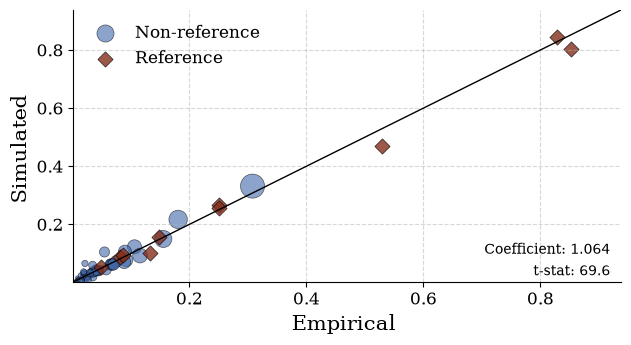

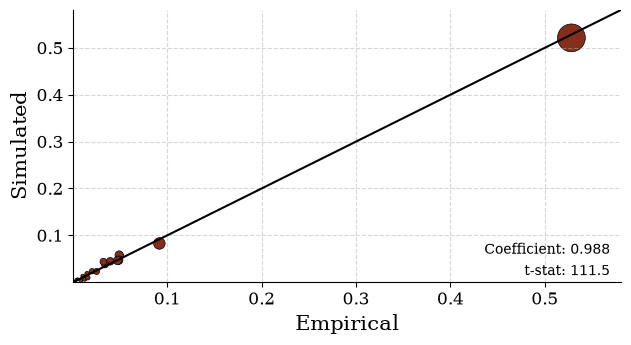

/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


aero: S=10  n_AA=18  N_REG=4  moments from reporting_aero_profiled_aa_gran_nlo1_pso/step3, SEs from step3/inference


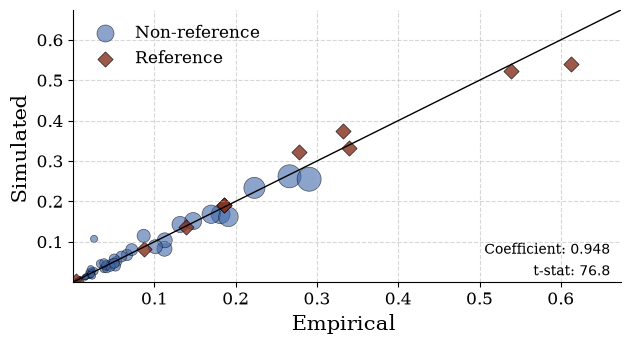

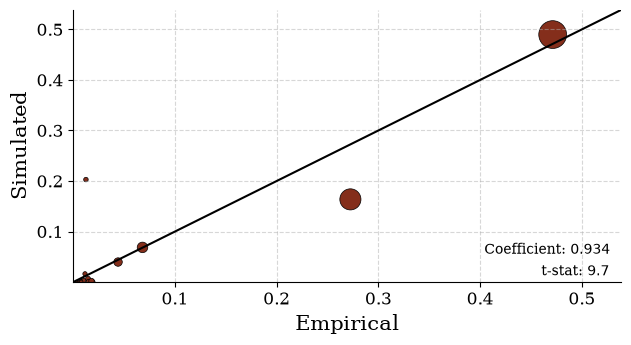

In [8]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)   # the analysis.ipynb pattern: binds input_folder, folder,
                             # coefs, emp_gamma_ls, X_dr, best_params, france, ... by name
    print(f"{industry}: S={data['S']}  n_AA={data['n_AA']}  N_REG={data['n_coef']}  "
          f"moments from {data['folder'].name}/{data['step_dir']}, "
          f"SEs from {data['inference_step']}/inference")

    plot_gamma_aa(data, save_to=f"{out_folder}/emp_sim_gamma_aa_{industry}_mu{MU}.pdf")
    plt.show()
    plot_pi_r(data, save_to=f"{out_folder}/emp_sim_pi_{industry}_mu{MU}.pdf")
    plt.show()


## Fit with standard errors: extensive margin and zero-supplier share

The two blocks where the comparison is only meaningful against sampling uncertainty: the
cloglog distance-bin coefficients (block 4) and the zero-supplier shares $\bar G_s(0)$
(block 6). Each tick carries the empirical value on the left and the simulated one on the
right, both with 95% bars. **Two different objects, deliberately:**

* **Empirical bars** — $\sqrt{\mathrm{diag}(\Sigma_{data})}$, the bootstrap sampling
  standard error of the moment *in the data*. How precisely the target is measured.
* **Simulated bars** — `se_moments_fitted.npy`, the standard error of the *fitted*
  moment, $\sqrt{\mathrm{diag}(G\,V\,G')}$, i.e. the estimation uncertainty of the
  parameters carried through to the moment they generate.

Under the profiled estimator (`--profile_T=true`, what these runs use) $V$ is the
**sandwich** covariance of $\hat\alpha$ and $G = \partial m / \partial \alpha$ is the
*profiled* Jacobian — $\alpha$ moved with $T$ following through the Sinkhorn inversion.
So the simulated bar is the delta-method propagation of $\hat\alpha$'s sandwich standard
error onto that moment, not an efficient standard error built from the free-parameter
Jacobian: under profiling $T$ is not a free parameter, it is a function of $\alpha$ and of
the sourcing-share targets, and the reported bar takes that dependence into account.
Two consequences worth keeping in mind when reading the figure: the bar does *not*
include the data noise of the $\gamma$ targets that $T$ is inverted from (that channel is
reported separately, in Julia's `inference_delta.txt`), and $\bar G_s(0)$'s bar does not
include the uncertainty of $\hat N_s$, which is calibrated on that very moment.

Both numbers come out of the Julia inference step; nothing is re-estimated here.

Each sector of the $\bar G_s(0)$ panel is annotated with its profiled variety count
$\hat N_s$, starred when it sits on a bound: a sector clamped at a bound cannot close its
own count residual through $\hat N_s$, so a visible miss there is expected rather than a
fit failure.


In [9]:
REG_BIN_LABELS_5 = [r"$]0,50]$", r"$]50,100]$", r"$]100,150]$", r"$]150,200]$", r"$>200$"]


def reg_bin_labels(n_coef):
    if n_coef == 1:
        return [r"$\log d$"]
    if n_coef == 4:
        return REG_BIN_LABELS_5[1:]
    if n_coef == 5:
        return list(REG_BIN_LABELS_5)
    return [rf"$\beta_{{{i + 1}}}$" for i in range(n_coef)]


def _paired_errorbar(ax, labels, emp, sim, se_emp=None, se_sim=None, ci=1.96,
                     ylabel="", xlabel="", title=None, rotate=0):
    """Empirical (left) against simulated (right) at each tick, with +/- ci*SE bars."""
    x = np.arange(len(labels), dtype=float)
    off = 0.12
    ax.errorbar(x - off, emp, yerr=None if se_emp is None else ci * np.asarray(se_emp),
                fmt="o", color=toulouse_color, capsize=3, markersize=7,
                markeredgecolor="black", markeredgewidth=0.5, linestyle="none",
                label="Empirical")
    ax.errorbar(x + off, sim, yerr=None if se_sim is None else ci * np.asarray(se_sim),
                fmt="D", color=sim_color, capsize=3, markersize=6,
                markeredgecolor="black", markeredgewidth=0.5, linestyle="none",
                label="Simulated")
    ax.axhline(0, color="black", linewidth=0.6, alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=rotate, ha="right" if rotate else "center")
    ax.set_xlim(-0.6, len(labels) - 0.4)
    ax.set_ylabel(ylabel)
    ax.set_xlabel(xlabel)
    if title:
        ax.set_title(title)
    ax.grid(axis="y", linestyle="dashed", alpha=0.5)
    ax.legend(frameon=False)
    _despine(ax)
    return ax


def plot_reg_coef(data, ax=None, save_to=None, ci=1.96):
    """Empirical vs simulated cloglog distance coefficients, with SEs."""
    emp = np.asarray(data["empirical_moments_dict"]["reg_coef"], float)
    sim = np.asarray(data["simulated_moments_dict"]["reg_coef"], float)
    se_e = data["se_empirical"]["reg_coef"] if data["se_empirical"] else None
    se_s = data["se_simulated"]["reg_coef"] if data["se_simulated"] else None

    fig, ax = (plt.subplots(figsize=get_figsize(hf=0.62)) if ax is None else (ax.figure, ax))
    _paired_errorbar(ax, reg_bin_labels(data["n_coef"]), emp, sim, se_e, se_s, ci=ci,
                     ylabel=r"Extensive margin coefficient",
                     xlabel="Distance bin (km)")
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        ax.figure.savefig(save_to, format="pdf", bbox_inches="tight")
    return ax


def plot_G0(data, ax=None, save_to=None, ci=1.96, annotate_N=True):
    """Empirical vs simulated Gbar_s(0) — the share of cells with no supplier."""
    if not data["granular"]:
        raise ValueError("Gbar_s(0) only exists under --granular=true")
    emp = np.asarray(data["empirical_moments_dict"]["G0"], float)
    sim = np.asarray(data["simulated_moments_dict"]["G0"], float)
    se_e = data["se_empirical"]["G0"] if data["se_empirical"] else None
    se_s = data["se_simulated"]["G0"] if data["se_simulated"] else None

    fig, ax = (plt.subplots(figsize=get_figsize(hf=0.62)) if ax is None else (ax.figure, ax))
    _paired_errorbar(ax, data["sector_names"], emp, sim, se_e, se_s, ci=ci,
                     ylabel=r"$\bar{G}_s(0)$", xlabel="Sector (A129)", rotate=45)

    # The profiled variety count is what the model moves to hit this moment, so
    # print it next to each sector — a clamped sector cannot close its own residual.
    diag = data.get("granular_diagnostics")
    if annotate_N and diag is not None and "N_hat" in diag:
        N_hat = np.asarray(diag["N_hat"]).ravel()
        clamped = np.asarray(diag.get("clamped", np.zeros_like(N_hat))).ravel()
        top = ax.get_ylim()[1]
        for i, (n, cl) in enumerate(zip(N_hat, clamped)):
            ax.text(i, top, rf"$\hat{{N}}_s={int(n)}$" + ("*" if cl != 0 else ""),
                    ha="center", va="bottom", fontsize=font_size-3, rotation=45)
        ax.set_ylim(ax.get_ylim()[0], top * 1.02)
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        ax.figure.savefig(save_to, format="pdf", bbox_inches="tight")
    return ax


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


auto: S=10  n_AA=22  N_REG=4  moments from reporting_auto_profiled_aa_gran_nlo1_pso/step3, SEs from step3/inference


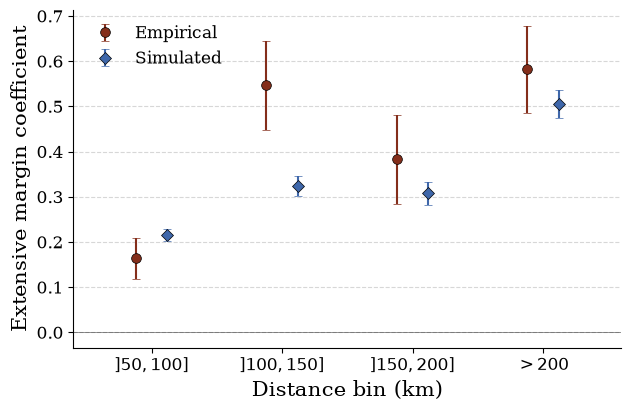

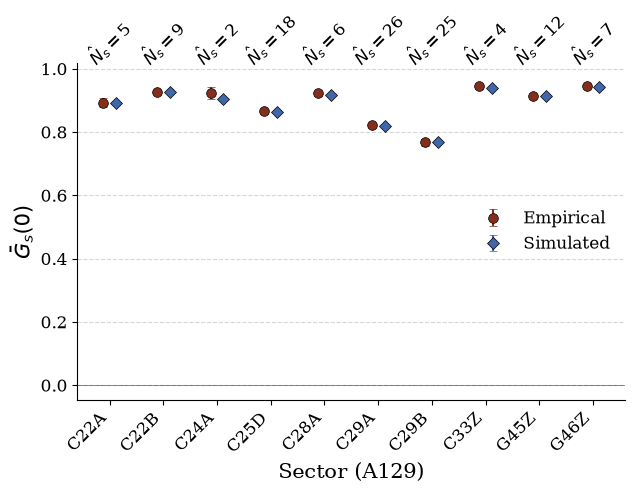

/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


aero: S=10  n_AA=18  N_REG=4  moments from reporting_aero_profiled_aa_gran_nlo1_pso/step3, SEs from step3/inference


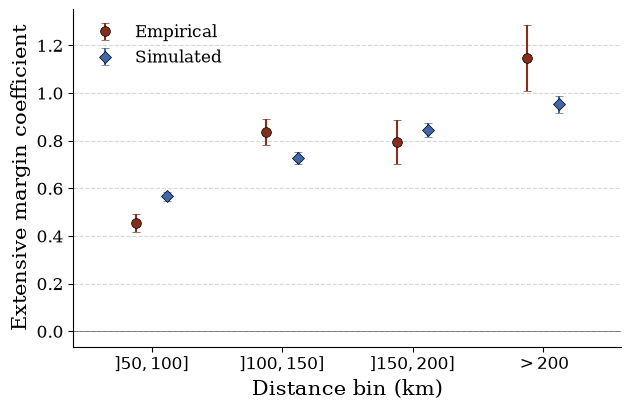

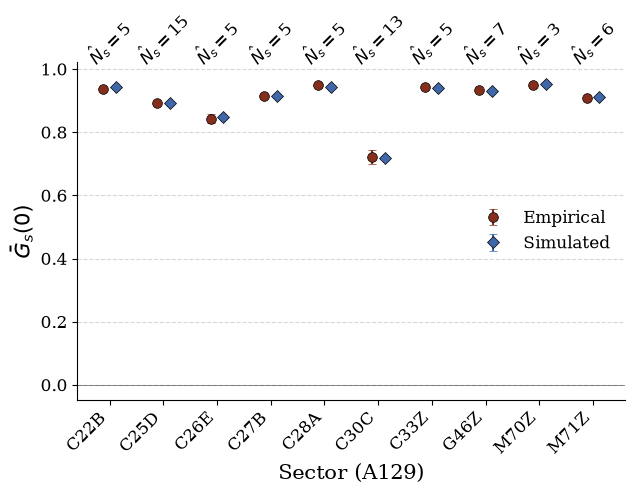

In [10]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)   # the analysis.ipynb pattern: binds input_folder, folder,
                             # coefs, emp_gamma_ls, X_dr, best_params, france, ... by name
    print(f"{industry}: S={data['S']}  n_AA={data['n_AA']}  N_REG={data['n_coef']}  "
          f"moments from {data['folder'].name}/{data['step_dir']}, "
          f"SEs from {data['inference_step']}/inference")

    plot_reg_coef(data, save_to=f"{out_folder}/emp_sim_reg_coef_{industry}_mu{MU}.pdf")
    plt.show()
    plot_G0(data, save_to=f"{out_folder}/emp_sim_G0_{industry}_mu{MU}.pdf")
    plt.show()


# Jacobian and variance-covariance


## Jacobian — which parameter moves which moment

Rows are the moments the criterion actually uses (the masked vector, six blocks),
columns are the parameters. The parameter axis is
$[\Omega^L \mid \Omega^s \mid A \mid \alpha \mid T \mid N_s]$: the head parameters, the
trade-cost elasticity, the comparative advantages, and — appended on the right — the
**variety counts**.

**Why $N_s$ is in the picture.** $T$ and $N_s$ are both *calibrated* rather than
searched over: $T$ is the Sinkhorn image that reproduces the observed sourcing shares at
a given $\alpha$, $N_s$ is the solution of $\bar G_s(n) = \hat G_s$ found by integer
bisection. $T$ appeared in the Jacobian only because it happens to be a coordinate of the
parameter vector and $N_s$ is not — a bookkeeping accident, not a statement about the
model. The Julia side now appends $\partial m/\partial N_s$ to the saved Jacobian, so the
matrix covers every parameter the model has. Two conventions for reading those columns:

* the derivative is a unit **first difference** $m(N_s+1) - m(N_s)$. $N_s$ is an integer,
  so one variety *is* the step and there is no step size to choose;
* the zeros outside block 6 are **structural**, not numerical. The two evaluations share
  the same productivity draws, so any moment with no $N_s$ term differences to exactly
  `0.0`, and Julia asserts it (the extensive margin is $N_s$-free by Proposition 1, the
  win probabilities by Lemma 2). An exact zero in an $N_s$ column is the model saying the
  channel does not exist, not a small number that fell below a threshold.

**What is plotted is the elasticity** $\varepsilon_{jk} = \partial \log m_j / \partial
\log \theta_k$ (for $N_s$, $\hat N_s \cdot \partial m_j/\partial N_s / m_j$). The raw
$\partial m/\partial\theta$ mixes units across blocks and cannot share one colour scale.

**The noise-to-signal triptych.** These derivatives are finite differences of *simulated*
moments, so each entry is itself an estimate: `compute_jacobian` averages over $K$
independent draw sets and reports the across-replication standard deviation
$\sigma_{jk}$. An entry is readable only if $\sigma_{jk}/|\varepsilon_{jk}|$ is small —
a large elasticity with a larger standard deviation is not evidence of a channel, and a
zero there means "not measured", not "not there". So each elasticity figure comes in
three panels:

1. the elasticity Jacobian as it is;
2. the noise-to-signal ratio $\sigma/|\varepsilon|$ alone, with the cells that fail the
   criterion marked — which parts of panel 1 are readable at all;
3. the elasticity Jacobian with those cells blanked to white — what survives.

A cell fails when $\sigma/|\varepsilon| \geq$ `NOISE_MAX` (default 0.5: the Monte-Carlo
standard deviation is at least half the elasticity itself). Entries that are *exactly*
zero are treated as readable, since a structural zero carries no simulation noise —
distinguishing them from unmeasured entries is the whole point of the panel.

**Under `profile_T` this is the FREE-parameter Jacobian**, saved for diagnostics: it
answers "what would move if $T$ were free". The inference itself runs on the $\alpha$-only
profiled Jacobian, where $T$ follows $\alpha$ through the Sinkhorn inversion.


In [11]:
# Jacobian heatmaps. `kind="elasticity"` is what should be read; "raw" mixes units.
# The parameter axis carries the variety counts N_s when the run wrote them (see the
# markdown above); `data["n_N_cols"]` says how many columns they occupy.

JACOBIAN_BOUNDARIES = [-1, -0.1, -0.05, -0.025, -0.01, -0.001,
                       0.001, 0.01, 0.025, 0.05, 0.1, 1]

# An elasticity is unreadable when its Monte-Carlo standard deviation across the K
# Jacobian replications is at least this fraction of the elasticity itself.
NOISE_MAX = 0.5


def _binned_cmap(boundaries, coarse=False):
    from matplotlib.colors import BoundaryNorm, ListedColormap
    if coarse:
        return ListedColormap(["#2166ac", "#f0f0f0", "#b2182b"]), \
            BoundaryNorm([-1, -0.1, 0.1, 1], 3)
    n_bins = len(boundaries) - 1
    cmap = ListedColormap(plt.get_cmap("RdBu_r")(np.linspace(0, 1, n_bins)))
    return cmap, BoundaryNorm(boundaries, n_bins)


def jacobian_matrix(data, kind="elasticity"):
    """The Jacobian to plot, with a clear error when it is not on disk."""
    key = {"elasticity": "J_elast", "raw": "J", "sd": "J_sd",
           "elasticity_sd": "J_elast_sd"}[kind]
    J = data.get(key)
    if J is None:
        step = data["inference_step"]
        raise FileNotFoundError(
            f"no Jacobian in {data['folder']}/{step}/ — main.jl writes "
            f"jacobian_all*.npy at theta_hat_1 (step2) and jacobian_all_step3*.npy at "
            f"theta_hat_2 (step3); the corresponding inference step must have run.")
    return J


def jacobian_noise_ratio(data, kind="elasticity"):
    """
    sigma / |epsilon| entry by entry — the Monte-Carlo standard deviation of the
    elasticity across the K Jacobian replications, relative to the elasticity itself.

    Scale-free: the theta/m rescaling that turns dm/dtheta into an elasticity cancels
    between numerator and denominator, so this is the same number for the raw and the
    elasticity Jacobian. An EXACTLY zero entry gets ratio 0 rather than infinity: a
    structural zero (the N_s columns outside block 6) carries no simulation noise, and
    conflating it with an unmeasured entry is precisely what this diagnostic is for.
    """
    E = np.asarray(jacobian_matrix(data, kind), float)
    sd = data.get("J_elast_sd" if "elast" in kind else "J_sd")
    if sd is None:
        raise FileNotFoundError(
            f"no across-replication SD for the Jacobian in {data['folder']}/"
            f"{data['inference_step']}/ — compute_jacobian writes it as "
            "jacobian_all*_elasticity_sd.npy when K > 1.")
    sd = np.abs(np.asarray(sd, float))
    A = np.abs(E)
    with np.errstate(divide="ignore", invalid="ignore"):
        R = sd / A
    R[(A == 0) & (sd == 0)] = 0.0          # structural zero: measured, and exactly zero
    R[~np.isfinite(R)] = np.inf            # nonzero noise on a zero signal: unreadable
    return R


def jacobian_noise_mask(data, kind="elasticity", noise_max=NOISE_MAX):
    """True where the elasticity is DROWNED in simulation noise and must not be read."""
    return jacobian_noise_ratio(data, kind) >= noise_max


def _edges(sizes):
    return np.cumsum([0] + list(sizes))


def _tick_every(n, target=25):
    """Tick stride that keeps roughly `target` labels on an axis of length n."""
    return max(1, int(np.ceil(n / target)))


def _block_grid(ax, data, m_edges, p_edges, block_names=True):
    """Block separators, plus the block names on the outer margins."""
    for e in m_edges[1:-1]:
        ax.axhline(e - 0.5, color="black", linewidth=1.2, alpha=0.6)
    for e in p_edges[1:-1]:
        ax.axvline(e - 0.5, color="black", linewidth=1.2, alpha=0.6)
    if not block_names:
        return
    ax_top, ax_right = ax.secondary_xaxis("top"), ax.secondary_yaxis("right")
    ax_top.set_xticks((p_edges[:-1] + p_edges[1:]) / 2 - 0.5)
    ax_top.set_xticklabels(data["param_block_names"], fontsize=10, fontweight="bold",
                           rotation=45)
    ax_right.set_yticks((m_edges[:-1] + m_edges[1:]) / 2 - 0.5)
    ax_right.set_yticklabels(data["moment_block_names"], fontsize=10, fontweight="bold")


def _axis_labels(ax, data, shape):
    xs = np.arange(shape[1])[::_tick_every(shape[1])]
    ax.set_xticks(xs)
    ax.set_xticklabels(np.array(data["param_labels"])[xs], rotation=90, fontsize=7)
    ax.xaxis.set_ticks_position("bottom")
    ys = np.arange(shape[0])[::_tick_every(shape[0])]
    ax.set_yticks(ys)
    ax.set_yticklabels(np.array(data["moment_labels"])[ys], fontsize=7)
    ax.set_xlabel("Parameter")
    ax.set_ylabel("Moment")


def plot_jacobian_full(data, kind="elasticity", coarse=False, figsize=(15, 11),
                       mask=None, title=None, save_to=None):
    """
    One heatmap of the whole Jacobian, moment blocks on the rows and parameter blocks on
    the columns — the direct read of which parameter block moves which moment block.

    `mask` (boolean, same shape) blanks entries to white: pass `jacobian_noise_mask(...)`
    for the third panel of the triptych, i.e. the matrix purged of the entries whose
    elasticity is not measured precisely enough to be read.
    """
    J = np.asarray(jacobian_matrix(data, kind), float)
    cmap, norm = _binned_cmap(JACOBIAN_BOUNDARIES, coarse=coarse)
    cmap = cmap.copy()
    cmap.set_bad("white")
    M = np.ma.masked_where(np.asarray(mask, bool), J) if mask is not None else J
    m_edges, p_edges = _edges(data["moment_block_sizes"]), _edges(data["param_block_sizes"])

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.matshow(M, cmap=cmap, norm=norm, aspect="auto")
    _block_grid(ax, data, m_edges, p_edges)
    _axis_labels(ax, data, J.shape)

    if title is None:
        title = (f"Jacobian ({kind}) — {data['industry']}, "
                 rf"$\hat{{\mu}}_{data['mu']}$   ({J.shape[0]}$\times${J.shape[1]})")
        if mask is not None:
            kept = float((~np.asarray(mask, bool)).mean())
            title += f"\nnoise-purged: {100 * kept:.1f}% of entries readable"
    ax.set_title(title, pad=28)
    cbar = fig.colorbar(im, ax=ax, orientation="horizontal", fraction=0.04, pad=0.22,
                        ticks=(None if coarse else JACOBIAN_BOUNDARIES))
    cbar.set_label("Elasticity" if "elast" in kind else "d m / d theta")
    if not coarse:
        cbar.ax.set_xticklabels([f"{t:g}" for t in JACOBIAN_BOUNDARIES],
                                fontsize=8, rotation=45)
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def plot_jacobian_noise(data, kind="elasticity", noise_max=NOISE_MAX, figsize=(15, 11),
                        save_to=None):
    """
    The middle panel of the triptych: the noise-to-signal ratio sigma/|epsilon| alone.

    Dark = the elasticity is well measured relative to its own size; light = it is not.
    Entries at or above `noise_max` are hatched, and those are exactly the ones the
    purged panel blanks out. Reading this panel first says WHICH parts of the Jacobian
    can be interpreted at all, before any statement is made about what they show.
    """
    R = jacobian_noise_ratio(data, kind)
    bad = R >= noise_max
    m_edges, p_edges = _edges(data["moment_block_sizes"]), _edges(data["param_block_sizes"])

    fig, ax = plt.subplots(figsize=figsize)
    cmap = plt.get_cmap("YlOrRd").copy()
    cmap.set_over("black")
    im = ax.matshow(np.clip(R, 0, noise_max * 2), cmap=cmap, aspect="auto",
                    vmin=0, vmax=noise_max * 2)
    # mark the failures explicitly, so a reader is not left inferring them from a colour
    ys, xs = np.where(bad)
    ax.scatter(xs, ys, s=1.5, marker="s", color="black", alpha=0.35, linewidths=0)
    _block_grid(ax, data, m_edges, p_edges)
    _axis_labels(ax, data, R.shape)

    share = float(bad.mean())
    ax.set_title(f"Jacobian noise-to-signal $\\sigma/|\\varepsilon|$ — "
                 f"{data['industry']}, " rf"$\hat{{\mu}}_{data['mu']}$"
                 f"\n{100 * share:.1f}% of entries at or above {noise_max:g} "
                 "(black squares) — not readable", pad=28)
    cbar = fig.colorbar(im, ax=ax, orientation="horizontal", fraction=0.04, pad=0.22,
                        extend="max")
    cbar.set_label(r"$\sigma_{jk} / |\varepsilon_{jk}|$ across the Jacobian replications"
                   f"   (threshold {noise_max:g})")
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def plot_jacobian_triptych(data, kind="elasticity", noise_max=NOISE_MAX,
                           figsize=(15, 11), out_folder=None, tag="jacobian",
                           show=True):
    """
    The three panels together: the elasticity Jacobian, the noise-to-signal map, and the
    Jacobian purged of the entries the map rejects. Saves `<tag>`, `<tag>_noise` and
    `<tag>_purged` under `out_folder` when one is given.
    """
    def _p(name):
        return None if out_folder is None else \
            f"{out_folder}/{name}_{data['industry']}_mu{data['mu']}.pdf"

    mask = jacobian_noise_mask(data, kind=kind, noise_max=noise_max)
    axes = [plot_jacobian_full(data, kind=kind, figsize=figsize, save_to=_p(tag))]
    if show:
        plt.show()
    axes.append(plot_jacobian_noise(data, kind=kind, noise_max=noise_max,
                                    figsize=figsize, save_to=_p(tag + "_noise")))
    if show:
        plt.show()
    axes.append(plot_jacobian_full(data, kind=kind, figsize=figsize, mask=mask,
                                   save_to=_p(tag + "_purged")))
    if show:
        plt.show()
    return axes


def plot_jacobian_blocks(data, kind="elasticity", coarse=True, ncols=3,
                         figsize=(18, 12), mask=None, save_to=None):
    """One panel per MOMENT block, columns spanning all parameters."""
    J = np.asarray(jacobian_matrix(data, kind), float)
    cmap, norm = _binned_cmap(JACOBIAN_BOUNDARIES, coarse=coarse)
    cmap = cmap.copy()
    cmap.set_bad("white")
    if mask is not None:
        J = np.ma.masked_where(np.asarray(mask, bool), J)
    m_edges, p_edges = _edges(data["moment_block_sizes"]), _edges(data["param_block_sizes"])
    blocks = np.split(J, m_edges[1:-1], axis=0)
    names = data["moment_block_names"]

    nrows = int(np.ceil(len(names) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()

    for i, (name, block) in enumerate(zip(names, blocks)):
        ax = axes[i]
        im = ax.matshow(block, cmap=cmap, norm=norm, aspect="auto")
        for e in p_edges[1:-1]:
            ax.axvline(e - 0.5, color="black", linewidth=1.2, alpha=0.5)

        cbar = fig.colorbar(im, ax=ax, orientation="horizontal", fraction=0.05, pad=0.12)
        cbar.set_label("Elasticity", fontsize=9)
        ax.set_title(f"{name}\n({block.shape[0]}x{block.shape[1]})",
                     fontsize=13, fontweight="bold", pad=12)
        ax.set_xlabel("Parameter", fontsize=10)

        xs = np.arange(block.shape[1])[::_tick_every(block.shape[1], 20)]
        ax.set_xticks(xs)
        ax.set_xticklabels(np.array(data["param_labels"])[xs], rotation=90, fontsize=7)
        ax.xaxis.set_ticks_position("bottom")

        row_labels = np.array(data["moment_labels"][m_edges[i]:m_edges[i + 1]])
        ys = np.arange(block.shape[0])[::_tick_every(block.shape[0], 20)]
        ax.set_yticks(ys)
        ax.set_yticklabels(row_labels[ys], fontsize=7)

    for ax in axes[len(names):]:
        ax.axis("off")
    fig.suptitle(f"Jacobian by moment block — {data['industry']}, "
                 rf"$\hat{{\mu}}_{data['mu']}$", fontsize=18, fontweight="bold")
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return axes[:len(names)]


def jacobian_block_summary(data, kind="elasticity", noise_max=NOISE_MAX):
    """
    Per (moment block x parameter block): the mean |elasticity|, and the share of the
    block's entries that are readable at all (noise-to-signal below `noise_max`).

    A large mean elasticity in a block whose readable share is low is a statement about
    the simulation, not about the model.
    """
    E = np.abs(np.asarray(jacobian_matrix(data, kind), float))
    try:
        ok = ~jacobian_noise_mask(data, kind=kind, noise_max=noise_max)
    except FileNotFoundError:
        ok = np.ones_like(E, dtype=bool)
    m_edges, p_edges = _edges(data["moment_block_sizes"]), _edges(data["param_block_sizes"])
    rows = []
    for i, mname in enumerate(data["moment_block_names"]):
        for j, pname in enumerate(data["param_block_names"]):
            sl = (slice(m_edges[i], m_edges[i + 1]), slice(p_edges[j], p_edges[j + 1]))
            sub, sub_ok = E[sl], ok[sl]
            rows.append({"moment_block": mname, "param_block": pname,
                         "mean_abs": sub.mean() if sub.size else np.nan,
                         "max_abs": sub.max() if sub.size else np.nan,
                         "share_readable": sub_ok.mean() if sub.size else np.nan})
    df = pd.DataFrame(rows)
    return df.set_index(["moment_block", "param_block"]).unstack("param_block") \
             .reindex(index=data["moment_block_names"]) \
             .reindex(columns=data["param_block_names"], level=1)


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


auto: S=10  n_AA=22  N_REG=4  10 variety-count columns in the Jacobian


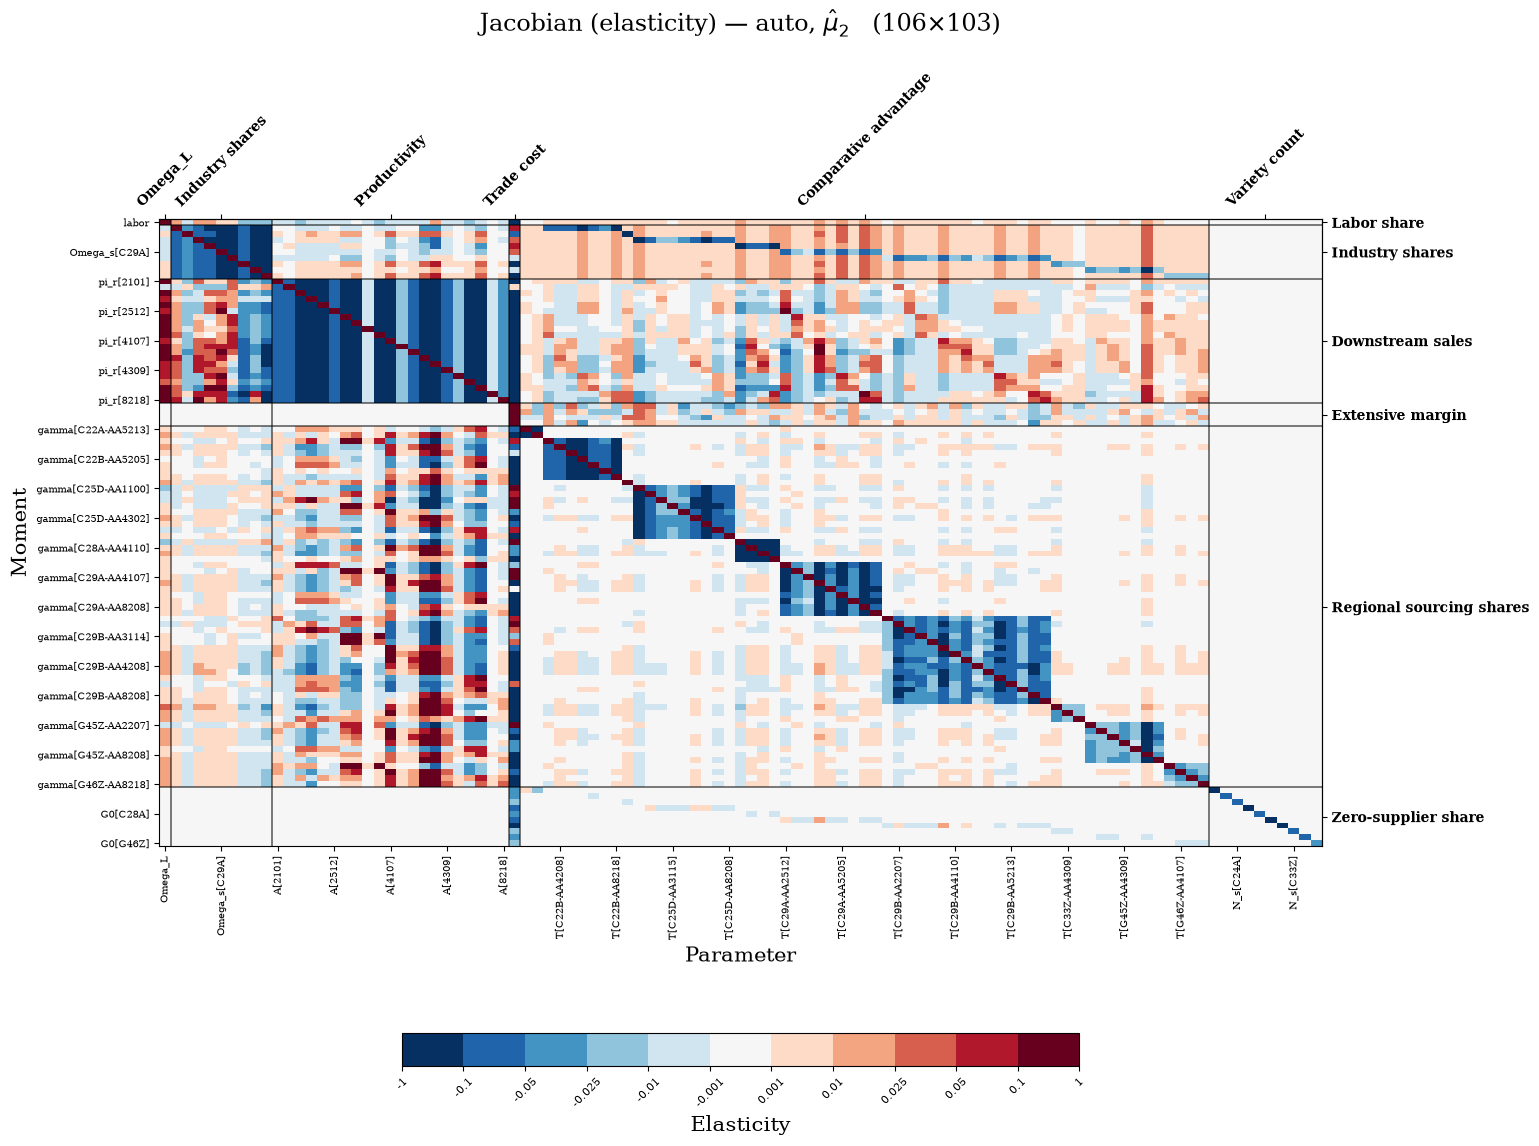

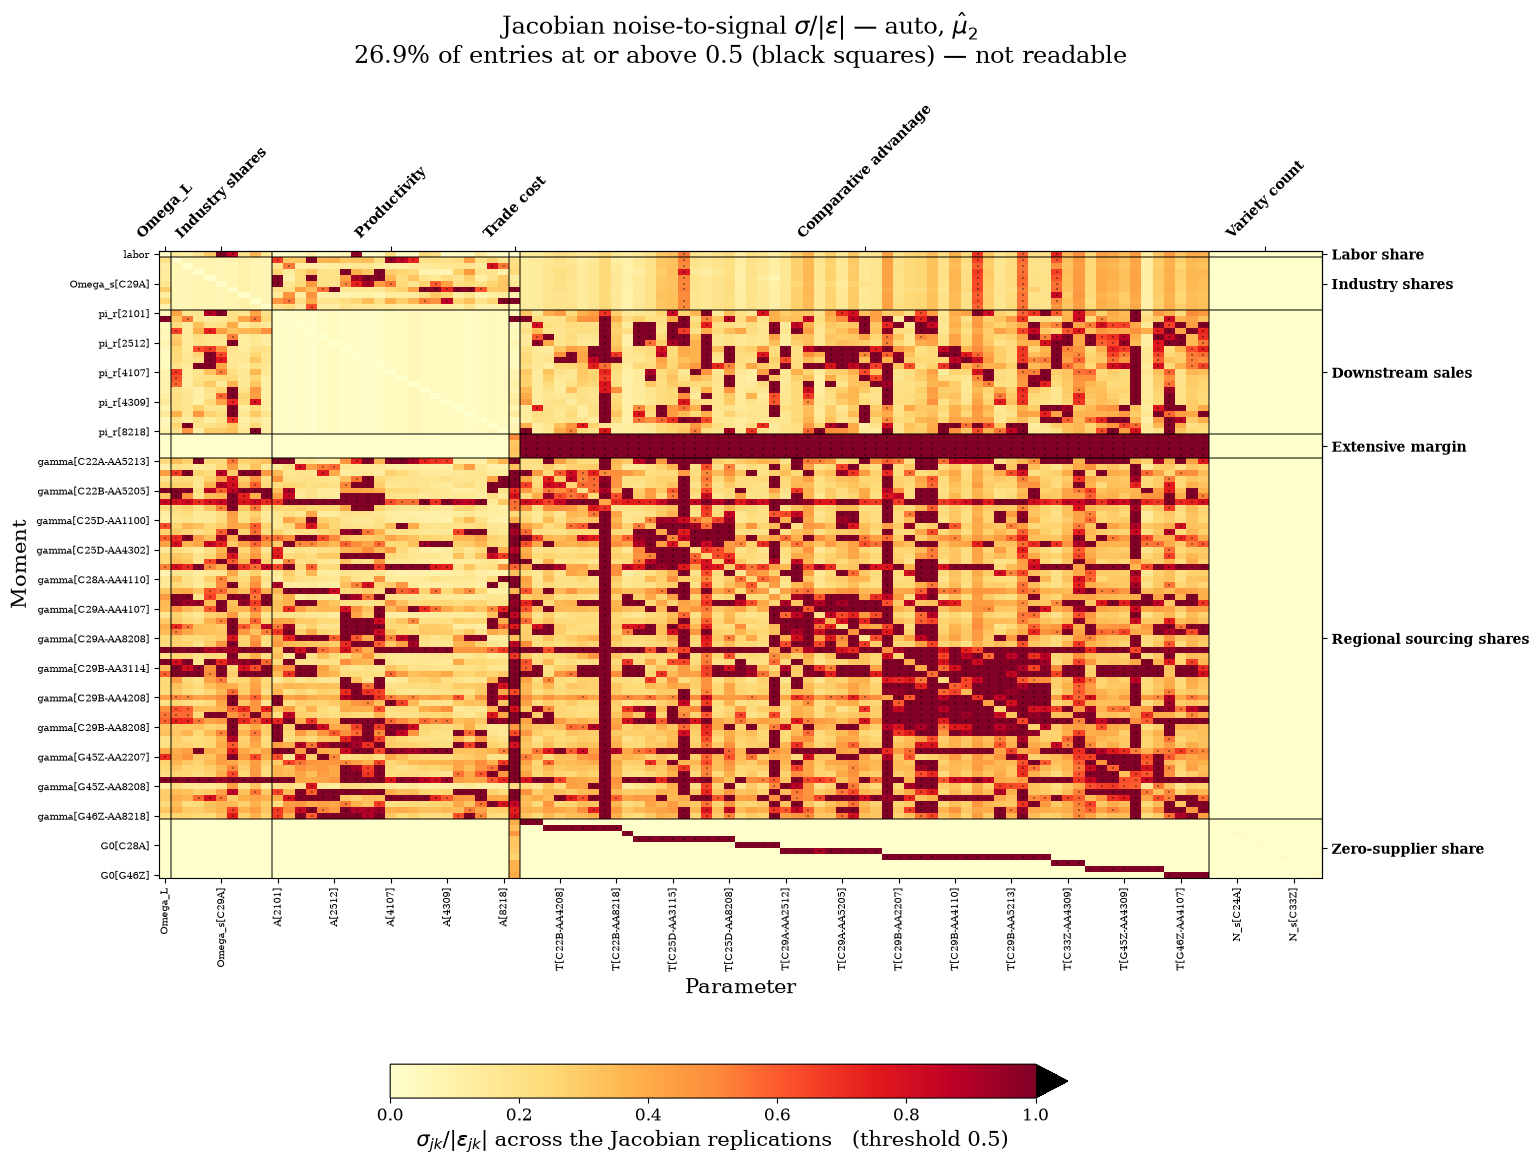

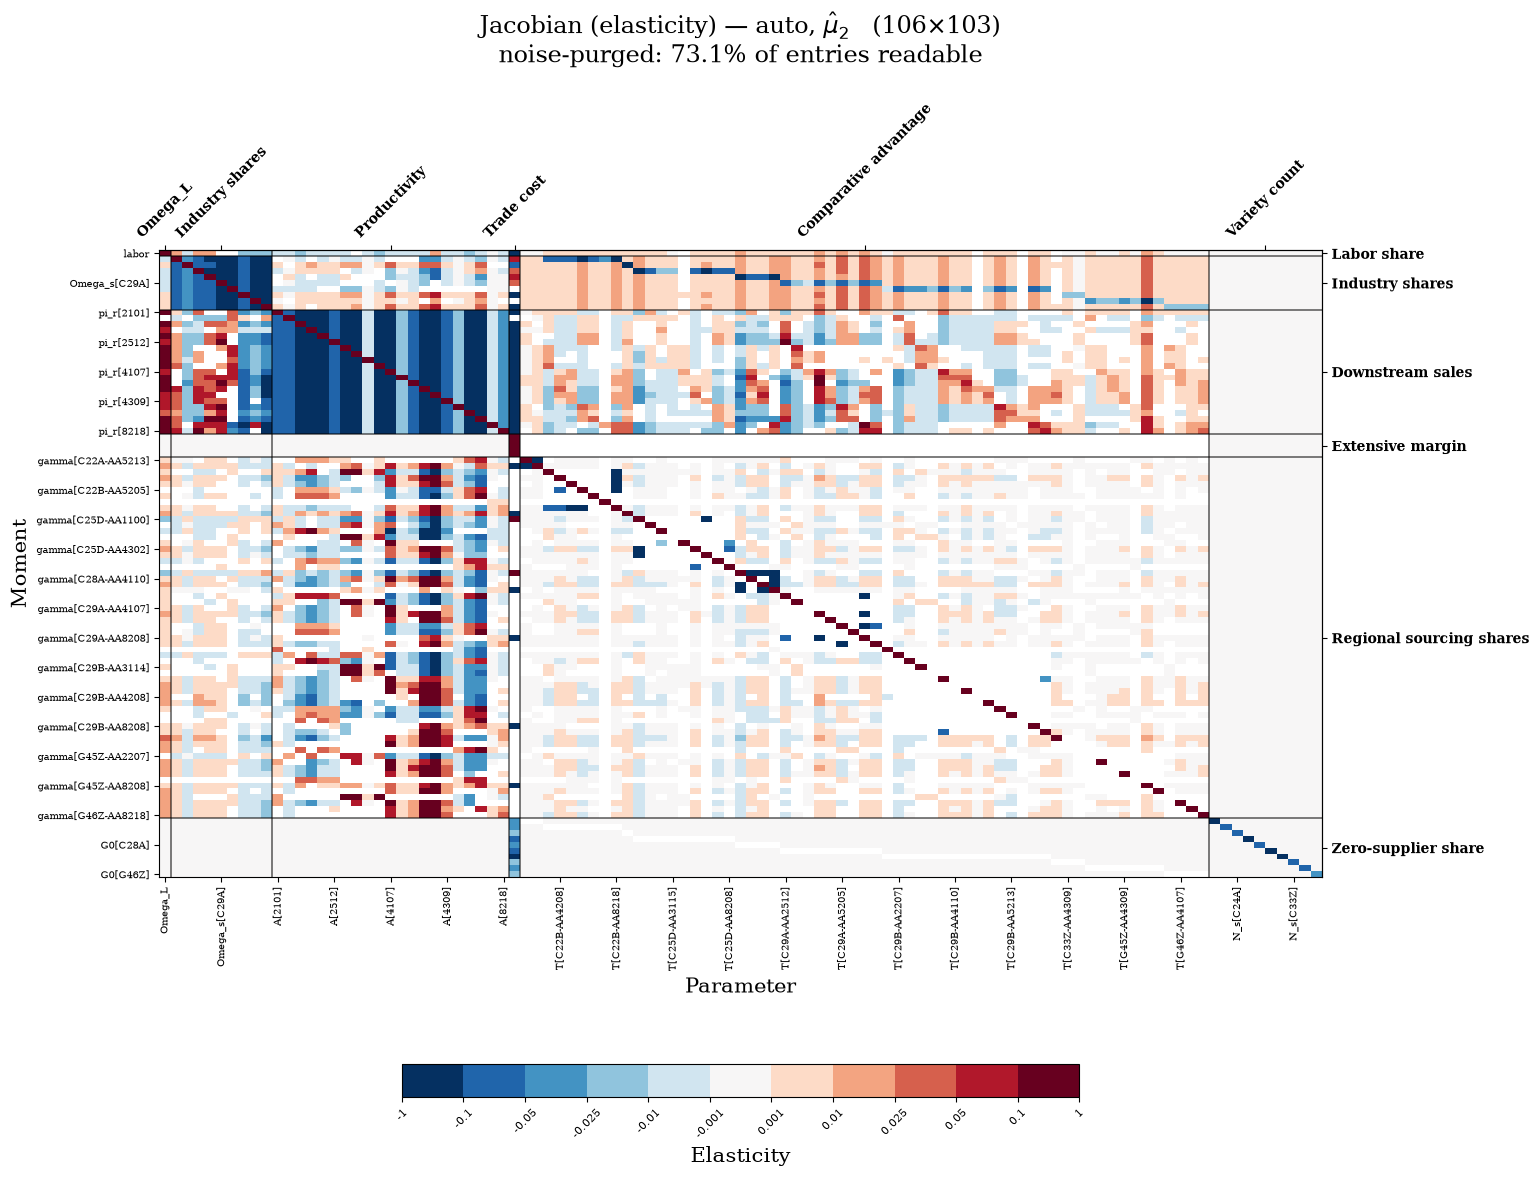

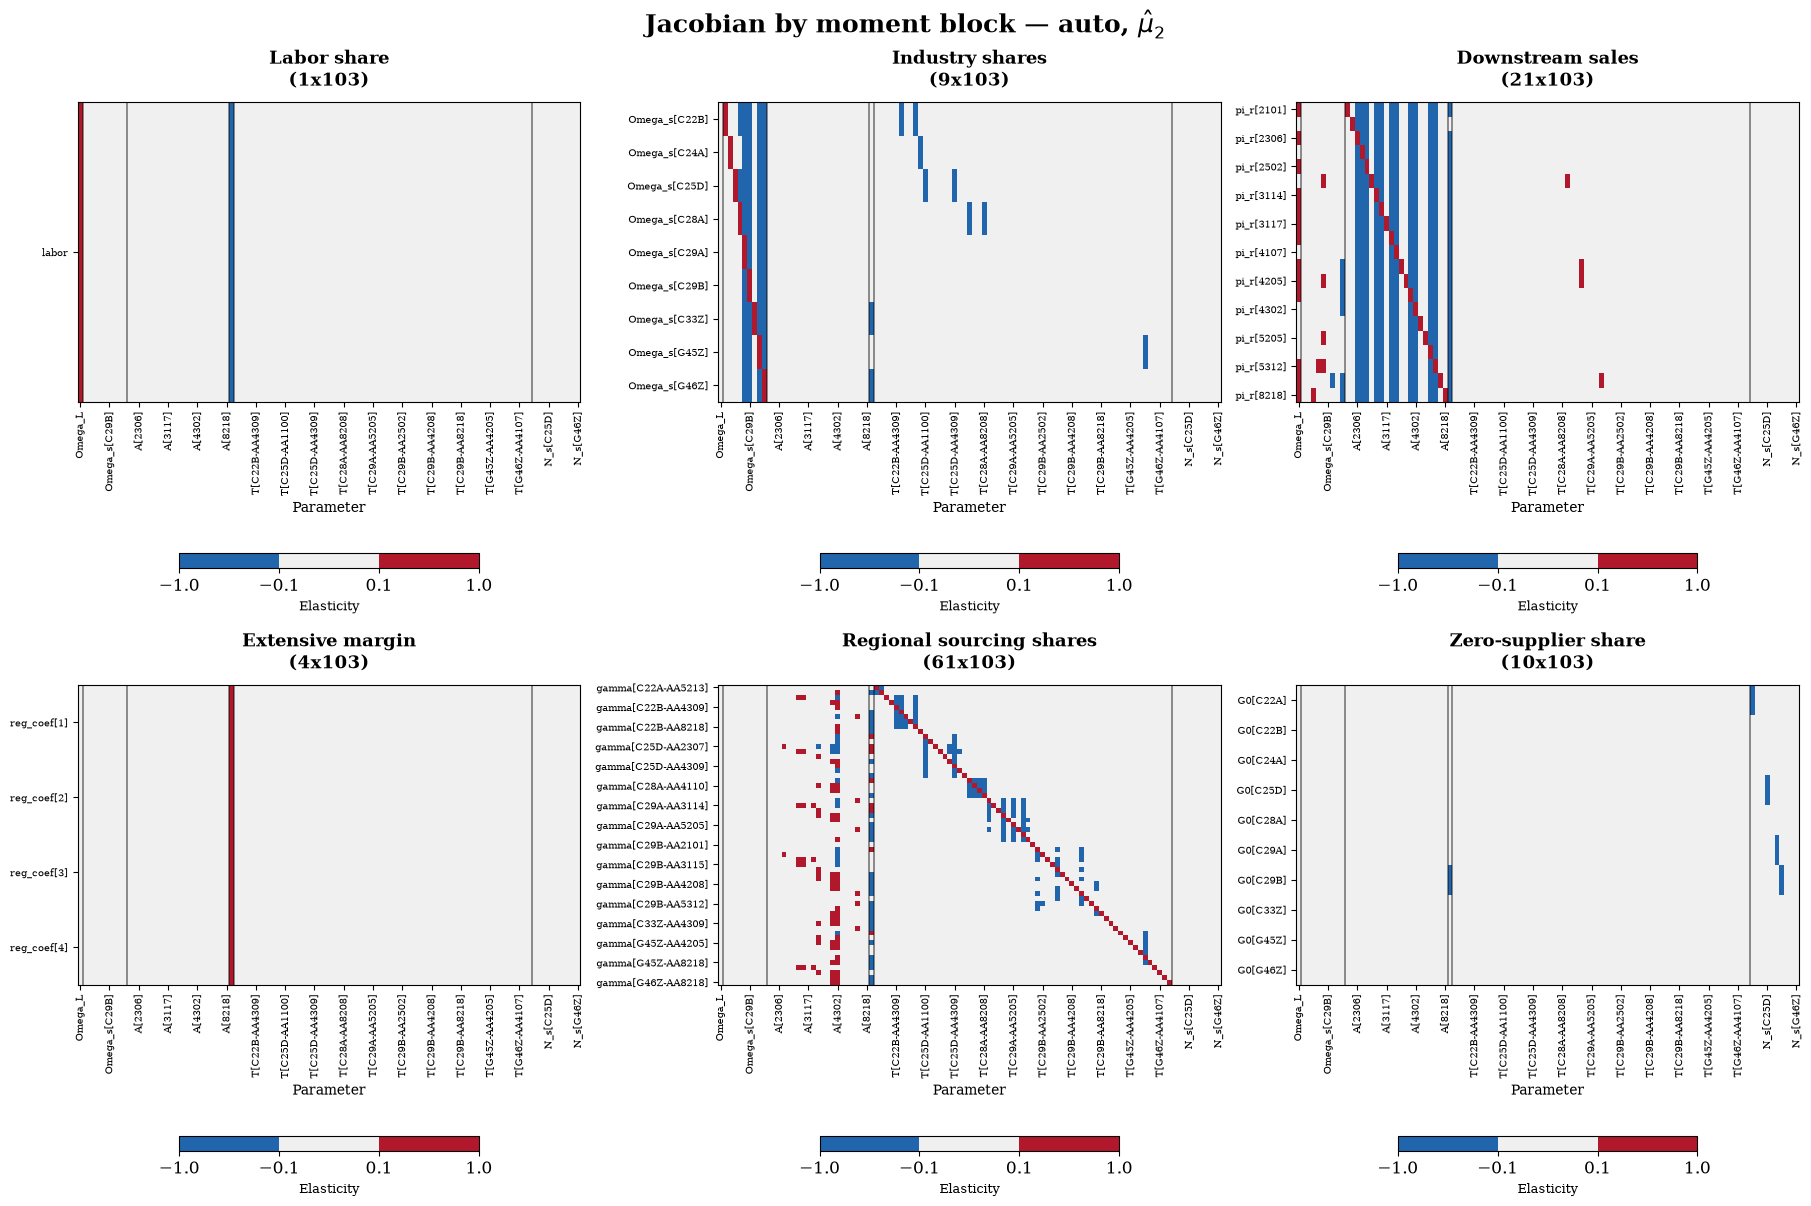

mean_abs                                          \
param_block                Omega_L Industry shares Productivity Trade cost   
moment_block                                                                 
Labor share               0.840801        0.013872     0.006423   0.563065   
Industry shares           0.003701        0.196531     0.008008   0.060258   
Downstream sales          0.101850        0.036806     0.615251   0.633728   
Extensive margin          0.000000        0.000000     0.000000   1.020677   
Regional sourcing shares  0.008282        0.003403     0.032945   0.142694   
Zero-supplier share       0.000000        0.000000     0.000000   0.038070   

                                                               max_abs  \
param_block              Comparative advantage Variety count   Omega_L   
moment_block                                                             
Labor share                           0.003644      0.000000  0.840801   
Industry shares                       0.012580      0.000000  0.006386   
Downstream sales                      0.009518      0.000000  0.156637   
Extensive margin                      0.008034      0.000000  0.000000   
Regional sourcing shares              0.025708      0.000000  0.025195   
Zero-supplier share                   0.000292      0.010759  0.000000   

                                                                  \
param_block              Industry shares Productivity Trade cost   
moment_block                                                       
Labor share                     0.023173     0.016220   0.563065   
Industry shares                 0.969266     0.087427   0.126083   
Downstream sales                0.168973     9.008682   0.975462   
Extensive margin                0.000000     0.000000   1.044725   
Regional sourcing shares        0.025075     0.880468   0.439621   
Zero-supplier share             0.000000     0.000000   0.101789   

                                                             share_readable  \
param_block              Comparative advantage Variety count        Omega_L   
moment_block                                                                  
Labor share                           0.015965       0.00000       1.000000   
Industry shares                       0.216771       0.00000       1.000000   
Downstream sales                      0.204321       0.00000       0.952381   
Extensive margin                      0.045213       0.00000       1.000000   
Regional sourcing shares              1.295379       0.00000       0.803279   
Zero-supplier share                   0.012566       0.23066       1.000000   

                                                                  \
param_block              Industry shares Productivity Trade cost   
moment_block                                                       
Labor share                     0.777778     0.952381   1.000000   
Industry shares                 1.000000     0.820106   0.777778   
Downstream sales                0.841270     1.000000   0.952381   
Extensive margin                1.000000     1.000000   1.000000   
Regional sourcing shares        0.664845     0.710383   0.131148   
Zero-supplier share             1.000000     1.000000   1.000000   

                                                              
param_block              Comparative advantage Variety count  
moment_block                                                  
Labor share                           0.934426           1.0  
Industry shares                       0.939891           1.0  
Downstream sales                      0.711944           1.0  
Extensive margin                      0.000000           1.0  
Regional sourcing shares              0.588014           1.0  
Zero-supplier share                   0.900000           1.0

/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


aero: S=10  n_AA=18  N_REG=4  10 variety-count columns in the Jacobian


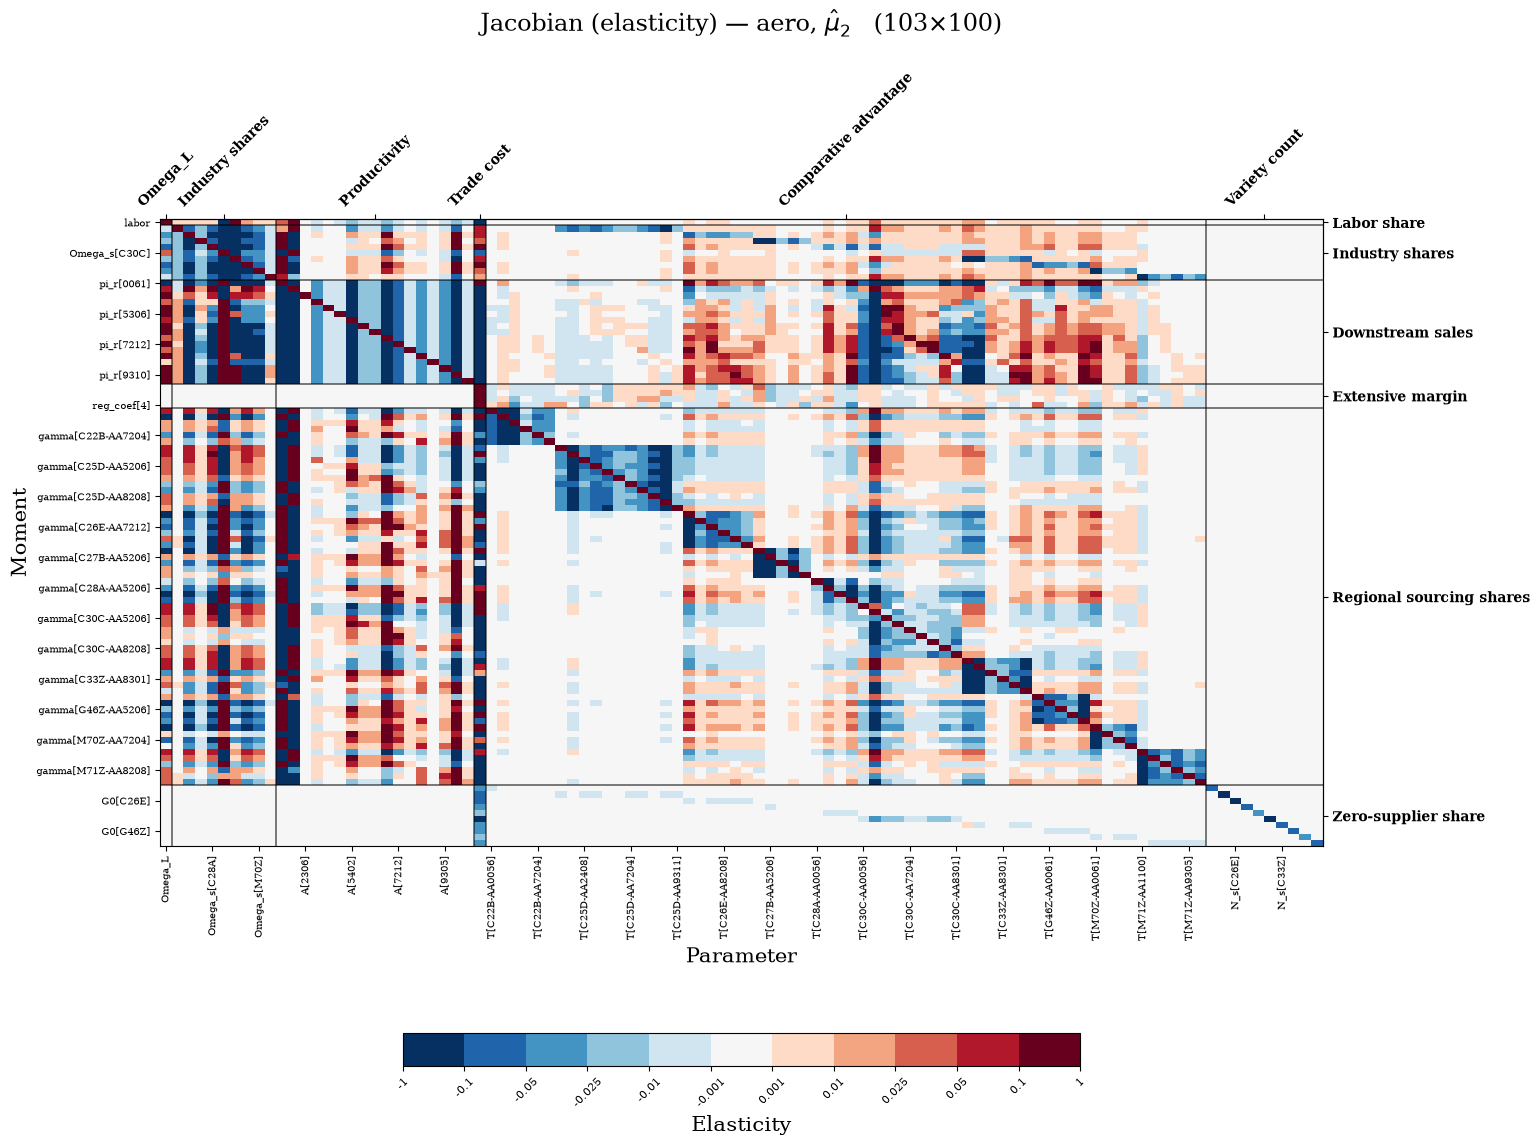

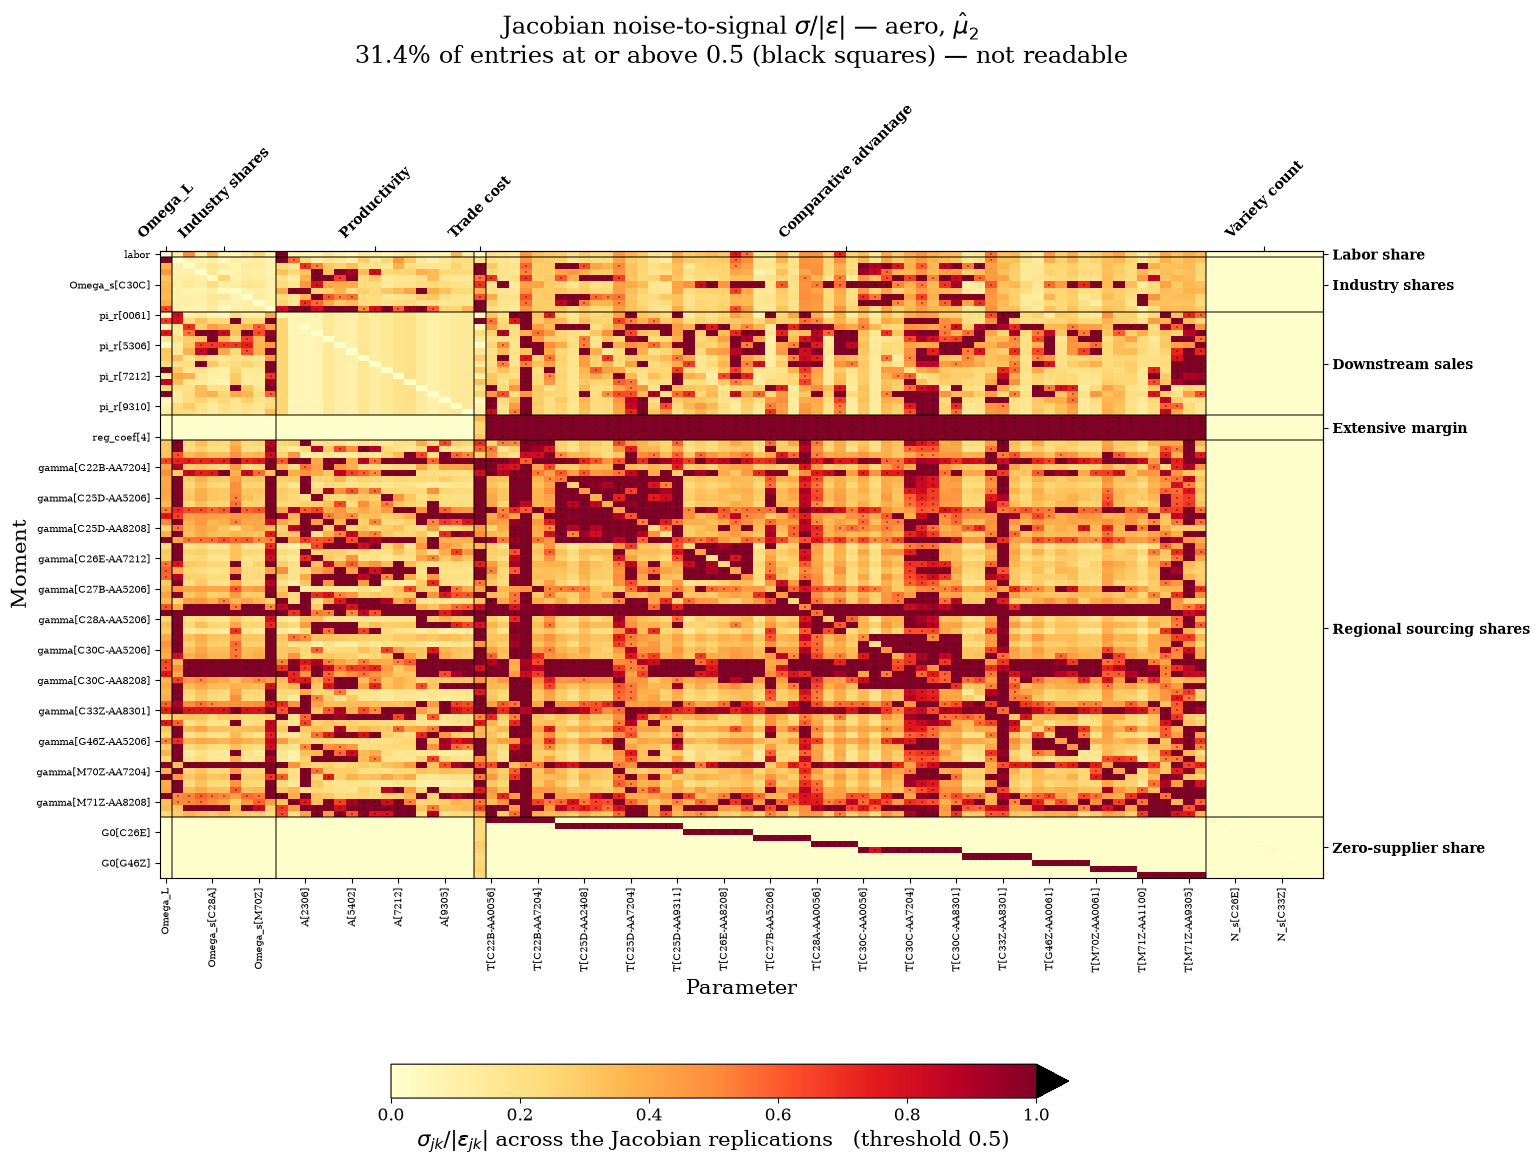

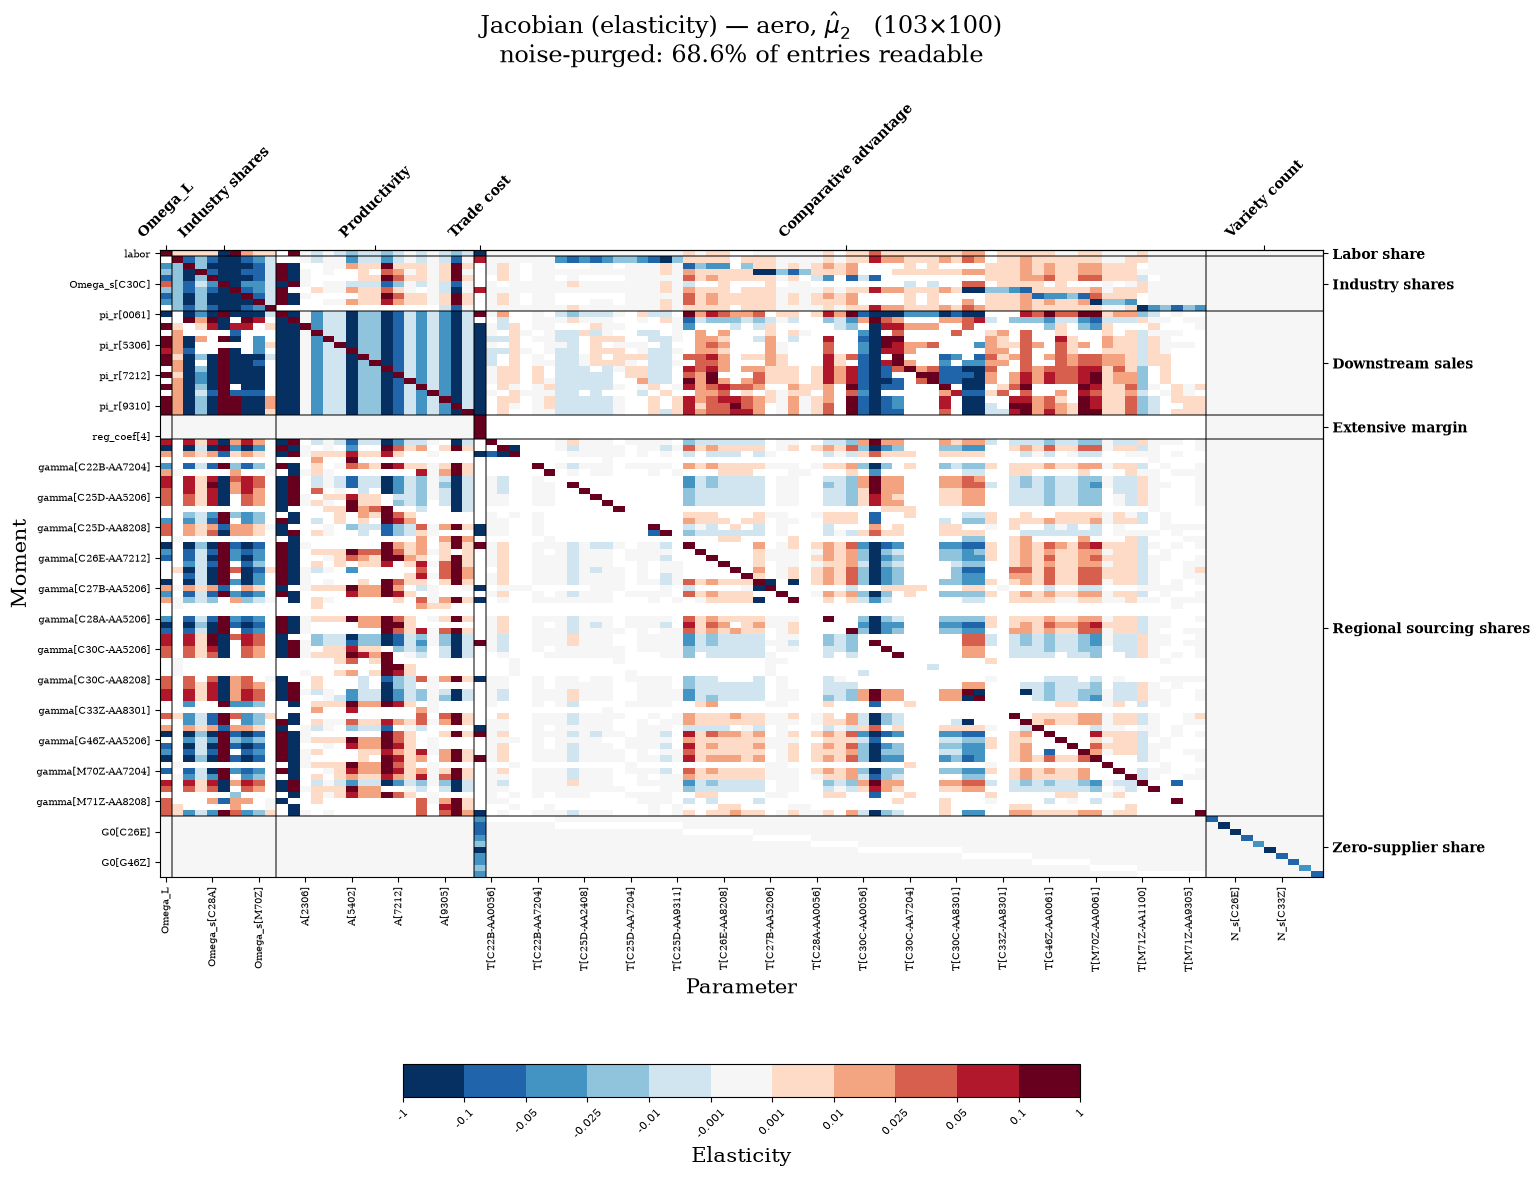

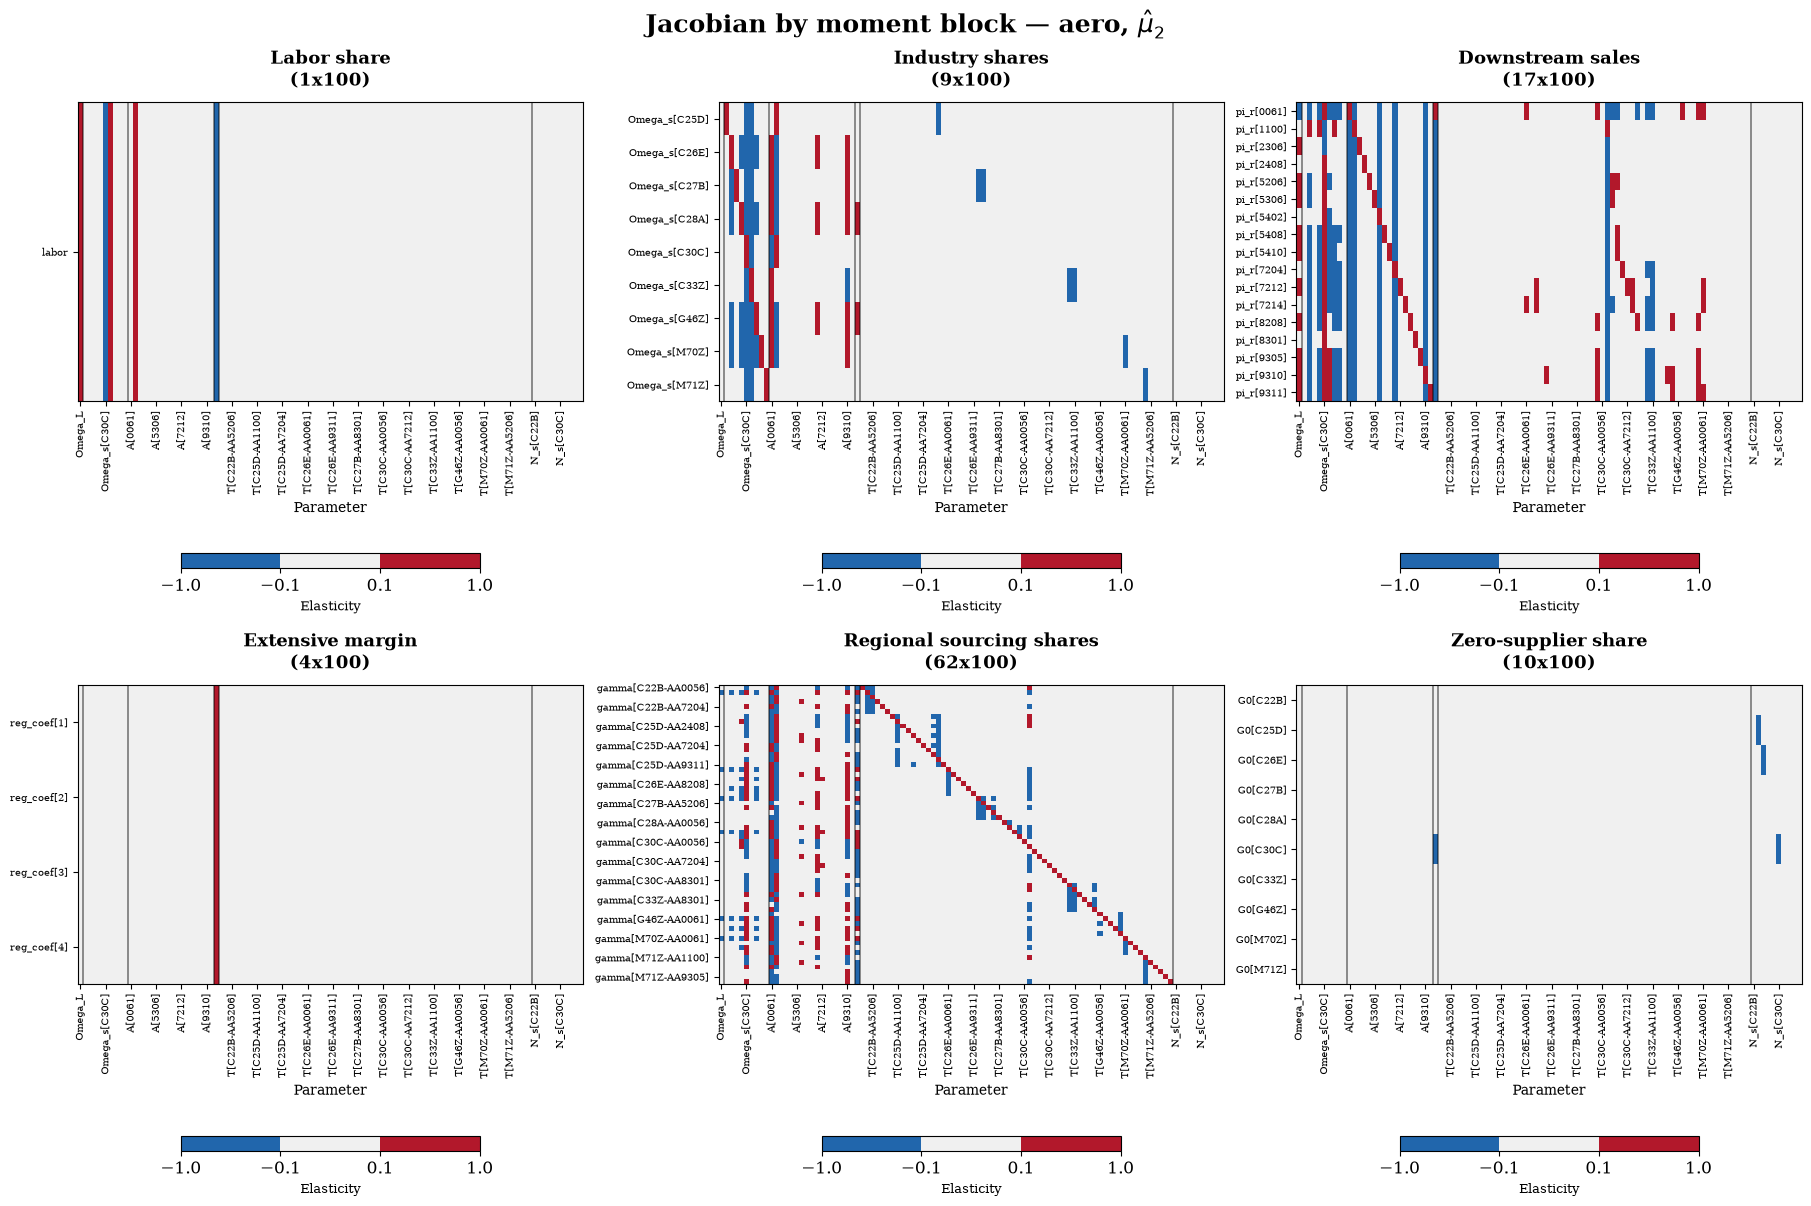

mean_abs                                          \
param_block                Omega_L Industry shares Productivity Trade cost   
moment_block                                                                 
Labor share               0.897958        0.036725     0.032798   0.954042   
Industry shares           0.030934        0.188377     0.087384   0.104991   
Downstream sales          0.260221        0.177920     1.596503   1.925992   
Extensive margin          0.000000        0.000000     0.000000   1.008260   
Regional sourcing shares  0.044258        0.049359     0.162469   0.280802   
Zero-supplier share       0.000000        0.000000     0.000000   0.053580   

                                                               max_abs  \
param_block              Comparative advantage Variety count   Omega_L   
moment_block                                                             
Labor share                           0.002526         0.000  0.897958   
Industry shares                       0.009190         0.000  0.075085   
Downstream sales                      0.030703         0.000  0.892516   
Extensive margin                      0.004998         0.000  0.000000   
Regional sourcing shares              0.027504         0.000  0.186356   
Zero-supplier share                   0.000323         0.009  0.000000   

                                                                  \
param_block              Industry shares Productivity Trade cost   
moment_block                                                       
Labor share                     0.166547     0.457955   0.954042   
Industry shares                 0.993302     1.531634   0.305530   
Downstream sales                2.391318    16.067689   6.236275   
Extensive margin                0.000000     0.000000   1.030968   
Regional sourcing shares        0.762966     3.669012   1.078515   
Zero-supplier share             0.000000     0.000000   0.160173   

                                                             share_readable  \
param_block              Comparative advantage Variety count        Omega_L   
moment_block                                                                  
Labor share                           0.047978       0.00000       1.000000   
Industry shares                       0.286887       0.00000       0.777778   
Downstream sales                      0.961813       0.00000       0.705882   
Extensive margin                      0.045686       0.00000       1.000000   
Regional sourcing shares              1.282700       0.00000       0.693548   
Zero-supplier share                   0.027069       0.20662       1.000000   

                                                                  \
param_block              Industry shares Productivity Trade cost   
moment_block                                                       
Labor share                     1.000000     0.941176   1.000000   
Industry shares                 1.000000     0.764706   0.222222   
Downstream sales                0.784314     1.000000   0.941176   
Extensive margin                1.000000     1.000000   1.000000   
Regional sourcing shares        0.621864     0.639469   0.193548   
Zero-supplier share             1.000000     1.000000   1.000000   

                                                              
param_block              Comparative advantage Variety count  
moment_block                                                  
Labor share                           0.935484           1.0  
Industry shares                       0.824373           1.0  
Downstream sales                      0.694497           1.0  
Extensive margin                      0.000000           1.0  
Regional sourcing shares              0.542404           1.0  
Zero-supplier share                   0.900000           1.0

In [12]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)
    print(f"{industry}: S={data['S']}  n_AA={data['n_AA']}  N_REG={data['n_coef']}  "
          f"{data['n_N_cols']} variety-count columns in the Jacobian")

    # the triptych: as is, the noise-to-signal map, and the purged matrix
    plot_jacobian_triptych(data, noise_max=NOISE_MAX, out_folder=out_folder,
                           tag="jacobian")
    plot_jacobian_blocks(data, save_to=f"{out_folder}/jacobian_blocks_{industry}_mu{MU}.pdf")
    plt.show()
    display(jacobian_block_summary(data, noise_max=NOISE_MAX))


## Variance-covariance of the moments


Three matrices, all written by Step 2:

* $\Sigma_{data}$ — the bootstrap covariance of the **empirical** moments: how precisely
  the targets are measured;
* $\Sigma_{sim}$ — the covariance across $K$ re-simulations at $\hat\theta_1$: how much
  of the moment vector is Monte-Carlo noise from the simulator;
* $\Omega = \Sigma_{data} + \Sigma_{sim}$ — what the estimator actually weighted with,
  $W = \Omega^{-1}$.

Two views of each. The **covariance** panels are on a common diverging scale, so the
relative magnitude of the three is visible — which is the point, since
$\mathrm{tr}(\Sigma_{sim})/\mathrm{tr}(\Sigma_{data})$ is the share of the weighting that
is simulation rather than data, and the dial for it is `--n_rho_inf`. The **correlation**
panels rescale each matrix by its own diagonal, which removes that magnitude and leaves
the dependence structure: whether the sampling error of the sourcing shares is correlated
across areas, whether the simulation noise is (it is, through the shared draws), and
whether $\Omega$ inherits its correlation from the data or from the simulator.


In [13]:
# The three moment covariance matrices, and the correlations they imply.

def _gb_edges(data):
    """
    Block edges of the inference subsystem and their names.

    The three blocks are stacked in a fixed order — extensive-margin coefficients,
    sourcing shares, zero-supplier shares — on both axes of every Sigma / Omega / W on
    disk. That order is the "beta, gamma, G" ordering invariant of CLAUDE.md.
    """
    n_beta = data["n_coef"]
    n_gam = int(np.asarray(data["moment_block_sizes"])[4])
    sizes = [n_beta, n_gam] + ([data["S"]] if data["granular"] else [])
    names = ["reg_coef", "gamma", "G0"][:len(sizes)]
    return np.cumsum([0] + sizes), names


def _cov_panel(ax, M, data, title, mode="cov", pct=95):
    """One matrix panel with the block grid drawn on; `mode` is "cov" or "corr"."""
    from matplotlib.colors import TwoSlopeNorm
    edges, names = _gb_edges(data)
    if mode == "corr":
        d = np.sqrt(np.clip(np.diag(M), 1e-300, None))
        M = M / np.outer(d, d)
        im = ax.matshow(M, cmap="RdBu_r", vmin=-1, vmax=1)
    else:
        v = np.percentile(np.abs(M), pct)
        v = v if v > 0 else (np.abs(M).max() or 1.0)
        im = ax.matshow(M, cmap="RdBu_r", norm=TwoSlopeNorm(vmin=-v, vcenter=0, vmax=v))
    for e in edges[1:-1]:
        ax.axhline(e - 0.5, color="black", linewidth=0.8, alpha=0.6)
        ax.axvline(e - 0.5, color="black", linewidth=0.8, alpha=0.6)
    ticks = (edges[:-1] + edges[1:]) / 2 - 0.5
    ax.set_xticks(ticks)
    ax.set_xticklabels(names, fontsize=9)
    ax.set_yticks(ticks)
    ax.set_yticklabels(names, fontsize=9, rotation=90, va="center")
    ax.set_title(title, pad=14)
    return im


def _cov_matrices(data):
    return [("$\\Sigma_{sim}$ (simulation noise)", data.get("Sigma_sim")),
            ("$\\Sigma_{data}$ (bootstrap)", data.get("Sigma_data")),
            ("$\\Omega = \\Sigma_{data} + \\Sigma_{sim}$", data.get("Omega"))]


def plot_variance_covariance(data, figsize=(16, 5.5), pct=95, save_to=None):
    """Sigma_sim, Sigma_data and Omega side by side, each on its own diverging scale."""
    mats = _cov_matrices(data)
    if all(m is None for _, m in mats):
        raise FileNotFoundError(f"no Sigma_*/Omega in {data['folder']}/step2/ — "
                                "build_step3_weight_matrix writes them in Step 2.")
    fig, axes = plt.subplots(1, len(mats), figsize=figsize)
    for ax, (title, M) in zip(np.atleast_1d(axes), mats):
        if M is None:
            ax.axis("off")
            ax.set_title(title + "\n(absent)")
            continue
        im = _cov_panel(ax, M, data, title, mode="cov", pct=pct)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(f"Moment variance-covariance — {data['industry']} "
                 "(extensive margin, sourcing shares, zero-supplier shares)", fontsize=14)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return axes


def plot_moment_correlation(data, figsize=(16, 5.5), save_to=None):
    """
    The same three matrices as CORRELATIONS, on a common [-1, 1] scale.

    Rescaling by the diagonal removes the magnitude — which the covariance figure is
    there to show — and leaves the dependence structure, so the three are comparable:
    whether the bootstrap error of the sourcing shares is correlated across areas,
    whether the simulator's noise is (it is, through the shared draws), and which of the
    two Omega inherits its structure from.
    """
    mats = _cov_matrices(data)
    if all(m is None for _, m in mats):
        raise FileNotFoundError(f"no Sigma_*/Omega in {data['folder']}/step2/")
    fig, axes = plt.subplots(1, len(mats), figsize=figsize)
    for ax, (title, M) in zip(np.atleast_1d(axes), mats):
        if M is None:
            ax.axis("off")
            ax.set_title(title + "\n(absent)")
            continue
        im = _cov_panel(ax, M, data, title, mode="corr")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(f"Moment CORRELATION — {data['industry']} "
                 "(same three matrices, rescaled by their own diagonal)", fontsize=14)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return axes


def variance_covariance_summary(data):
    """
    How much of the weighting is simulation noise, and how well conditioned is Omega?

    `trace(Sigma_sim)/trace(Sigma_data)` is the share of total moment variance that comes
    from the simulation rather than the data — raise `--n_rho_inf` if it is not small.
    `mean_abs_offdiag_corr` is the average absolute off-diagonal correlation, the same
    thing the correlation figure shows, as one number per matrix. The condition numbers
    say whether inverting Omega to build W is safe.
    """
    out = {}
    for name in ("Sigma_data", "Sigma_sim", "Omega"):
        M = data.get(name)
        if M is None:
            continue
        ev = np.linalg.eigvalsh((M + M.T) / 2)
        d = np.sqrt(np.clip(np.diag(M), 1e-300, None))
        C = M / np.outer(d, d)
        off = ~np.eye(C.shape[0], dtype=bool)
        out[name] = {"trace": float(np.trace(M)),
                     "eig_min": float(ev.min()), "eig_max": float(ev.max()),
                     "cond": float(ev.max() / ev.min()) if ev.min() > 0 else np.inf,
                     "mean_abs_offdiag_corr": float(np.abs(C[off]).mean())}
    if "Sigma_sim" in out and "Sigma_data" in out and out["Sigma_data"]["trace"] != 0:
        out["Sigma_sim"]["share_of_data_trace"] = \
            out["Sigma_sim"]["trace"] / out["Sigma_data"]["trace"]
    return pd.DataFrame(out).T


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


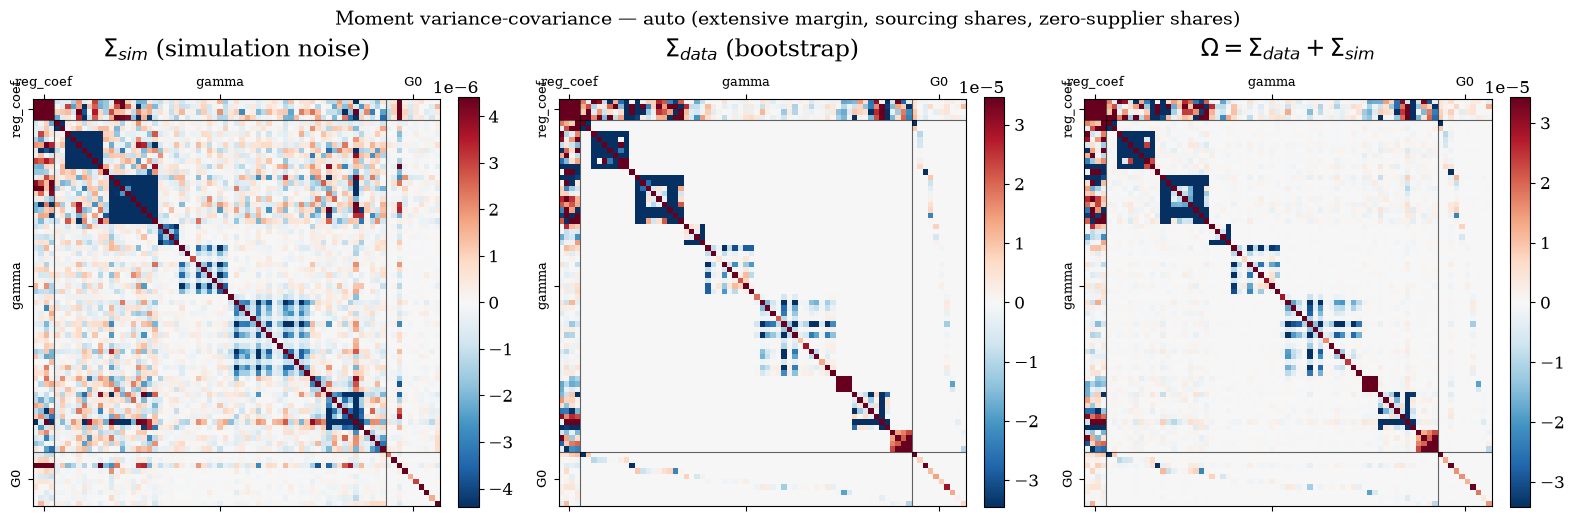

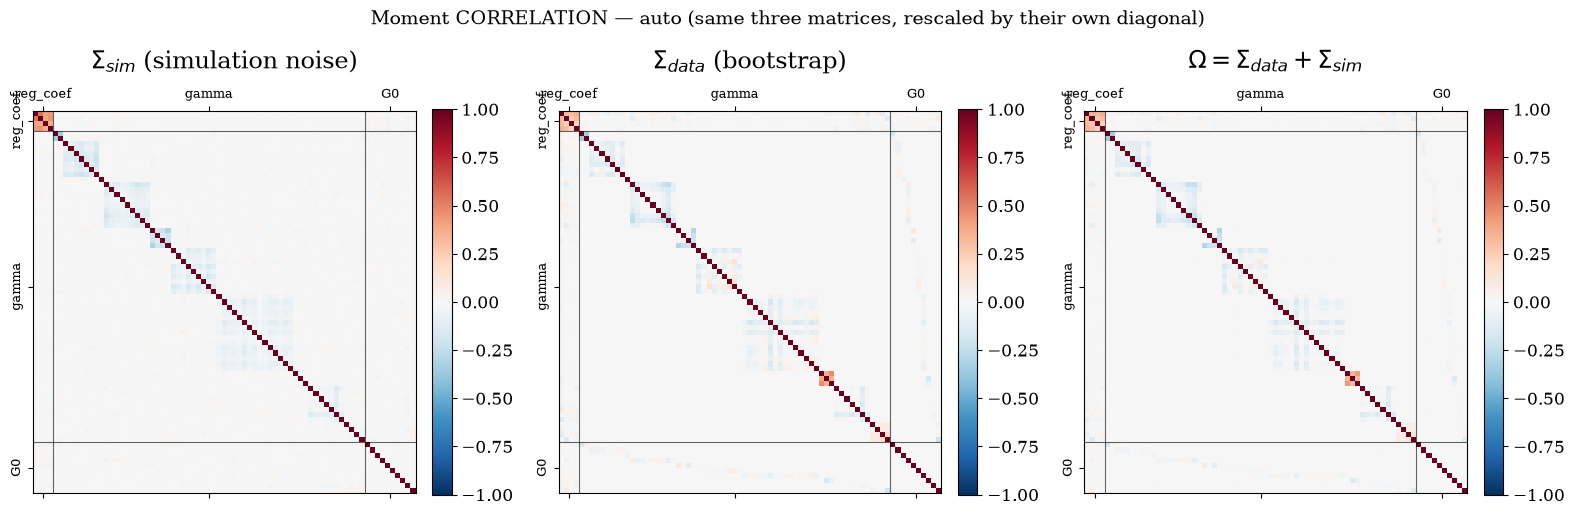

,trace,eig_min,eig_max,cond,mean_abs_offdiag_corr,share_of_data_trace
Sigma_data,0.076572,0.000001,0.012064,8906.941253,0.008475,NaN
Sigma_sim,0.008251,0.000002,0.000921,581.043516,0.014304,0.107759
Omega,0.084823,0.000003,0.012148,4076.095721,0.008614,NaN


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


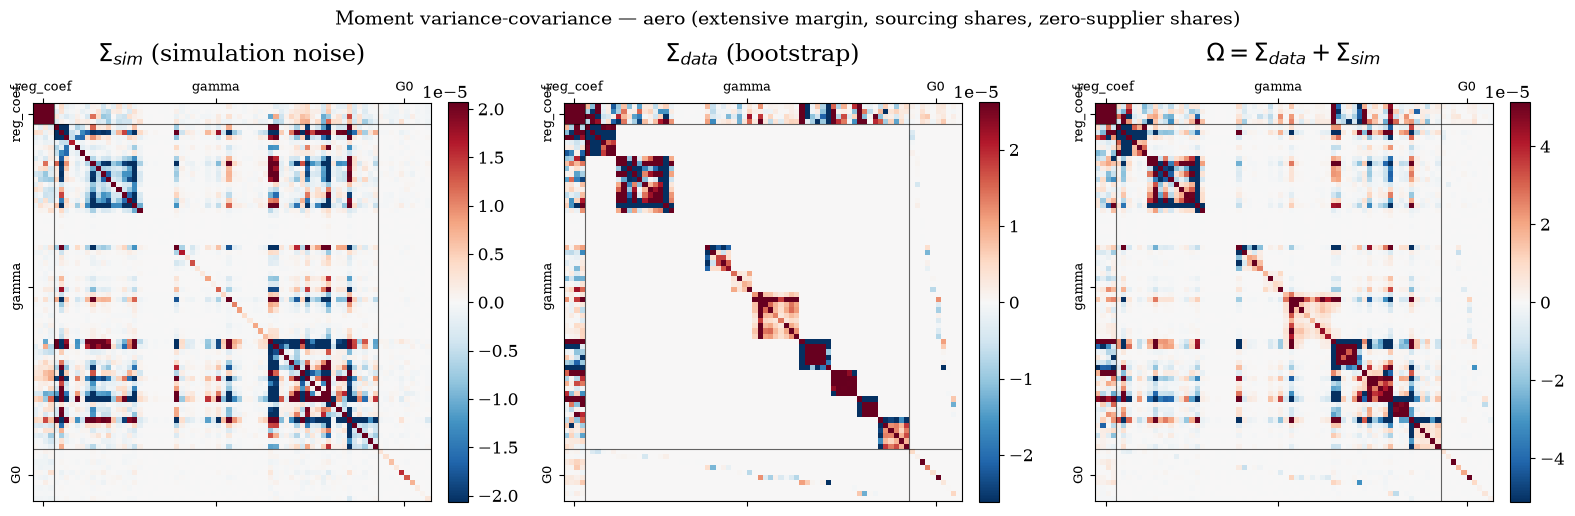

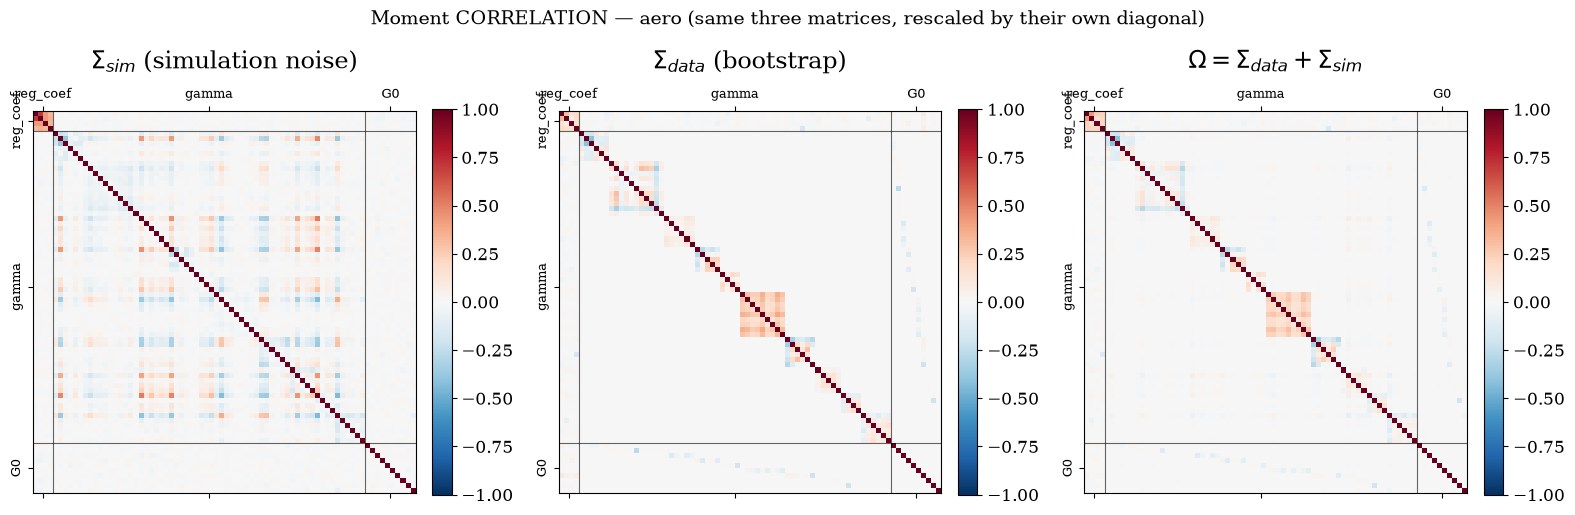

,trace,eig_min,eig_max,cond,mean_abs_offdiag_corr,share_of_data_trace
Sigma_data,0.113914,1.109410e-31,0.022176,1.998878e+29,0.010890,NaN
Sigma_sim,0.011919,1.818358e-09,0.001966,1.080957e+06,0.030681,0.104628
Omega,0.125833,1.040316e-08,0.023019,2.212704e+06,0.012168,NaN


In [14]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    plot_variance_covariance(data, save_to=f"{out_folder}/varcov_{industry}.pdf")
    plt.show()
    plot_moment_correlation(
        data, save_to=f"{out_folder}/moment_correlation_{industry}.pdf")
    plt.show()
    display(variance_covariance_summary(data))


## Identification / sensitivity

A sensitivity analysis fixes every parameter, moves one of them above and below its
estimate, and checks that the moments respond smoothly and in the direction the design
predicts. The elasticity Jacobian *is* that experiment, linearised at the estimate:
$\varepsilon_{jk} = \partial \log m_j / \partial \log \theta_k$ is the local slope of
moment $j$ against parameter $k$. With ten sectors, the attraction areas, the $T$ block
and the variety counts there are far too many parameters to draw a curve each, so the
matrix is drawn instead and everything too small — or too noisy — is blanked out.

Two thresholds, and they answer different questions:

* $|\varepsilon| \geq$ `IDENT_THRESHOLD` (0.01): a 1% move in the parameter shifts the
  moment by at least 0.01%. **Is there a channel?**
* $\sigma/|\varepsilon| <$ `NOISE_MAX` (0.5): the elasticity is estimated precisely
  enough relative to its own size. **Can we see it?** An entry that fails this is not
  evidence of a weak channel; it is evidence of nothing at all, and the summary counts it
  separately rather than pooling it with the structural zeros.

What the figures are meant to show: the three channels are close to orthogonal *by
construction*. $\alpha$ is read from a **within**-area distance gradient that comparative
advantage cannot touch, since comparative advantage is constant within an area; $T_{as}$
is read from **across**-area value shares; $N_s$ is read from the **level** of the
empty-region share, which the sector $\times$ nearest-downstream fixed effect strips out
of the $\alpha$ regression. So the expected picture is near-block-diagonal on the
(Trade cost, Comparative advantage, Variety count) $\times$ (Extensive margin, Regional
sourcing shares, Zero-supplier share) corner — and in the $N_s$ columns *exact* zeros
rather than merely small numbers.


In [15]:
# Identification / sensitivity — the elasticity Jacobian read as the experiment
# "move one parameter, watch the moments", with two thresholds: is there a channel
# (IDENT_THRESHOLD), and is it measured well enough to see (NOISE_MAX).
#
# The variety counts N_s are part of the parameter axis: the Julia side appends
# dm/dN_s to the saved Jacobian, so no re-attachment is done here.

IDENT_THRESHOLD = 0.01


def _blocks_2d(data, M):
    """M split into (moment block x parameter block) sub-matrices."""
    m_edges, p_edges = _edges(data["moment_block_sizes"]), _edges(data["param_block_sizes"])
    return {(i, j): M[m_edges[i]:m_edges[i + 1], p_edges[j]:p_edges[j + 1]]
            for i in range(len(data["moment_block_names"]))
            for j in range(len(data["param_block_names"]))}


def _readable(data, kind="elasticity", noise_max=NOISE_MAX):
    """Boolean matrix: entries whose elasticity is precise enough to be interpreted."""
    if noise_max is None:
        return np.ones_like(np.asarray(jacobian_matrix(data, kind), float), dtype=bool)
    try:
        return ~jacobian_noise_mask(data, kind=kind, noise_max=noise_max)
    except FileNotFoundError:
        return np.ones_like(np.asarray(jacobian_matrix(data, kind), float), dtype=bool)


def identification_summary(data, threshold=IDENT_THRESHOLD, kind="elasticity",
                           noise_max=NOISE_MAX):
    """
    Per (moment block x parameter block), four numbers that answer four questions:

      share_above       is there a channel?  share of entries with |elasticity| >= threshold
      share_readable    can it be seen?      share whose sigma/|elasticity| < noise_max
      share_live        both at once         above the threshold AND readable
      share_exact_zero  is it absent by construction?  share of entries exactly 0

    The last two are the pair worth reading together: an exact zero is the model saying
    the channel does not exist (the N_s columns outside block 6, asserted in Julia),
    whereas an unreadable entry says nothing at all.
    """
    E = np.abs(np.asarray(jacobian_matrix(data, kind), float))
    ok = _readable(data, kind, noise_max)
    rows = []
    for (i, j), sub in _blocks_2d(data, E).items():
        sub_ok = _blocks_2d(data, ok)[(i, j)]
        rows.append({
            "moment_block": data["moment_block_names"][i],
            "param_block": data["param_block_names"][j],
            "share_above": float((sub >= threshold).mean()) if sub.size else np.nan,
            "share_readable": float(sub_ok.mean()) if sub.size else np.nan,
            "share_live": float(((sub >= threshold) & sub_ok).mean()) if sub.size else np.nan,
            "max_abs": float(sub.max()) if sub.size else np.nan,
            "mean_abs": float(sub.mean()) if sub.size else np.nan,
            "share_exact_zero": float((sub == 0).mean()) if sub.size else np.nan,
        })
    df = pd.DataFrame(rows)
    return df.set_index(["moment_block", "param_block"]).unstack("param_block") \
             .reindex(index=data["moment_block_names"]) \
             .reindex(columns=data["param_block_names"], level=1)


def plot_identification_map(data, threshold=IDENT_THRESHOLD, kind="elasticity",
                            noise_max=NOISE_MAX, figsize=(9, 6), save_to=None):
    """
    One cell per (moment block x parameter block), coloured by the share of entries that
    are BOTH above the threshold and readable, annotated with that share, the block's
    max |elasticity|, and — when it is not 100% — the share of the block that is readable
    at all. A near-diagonal pattern down the (Trade cost, Comparative advantage, Variety
    count) columns is the identification claim, read off directly.
    """
    E = np.abs(np.asarray(jacobian_matrix(data, kind), float))
    ok = _readable(data, kind, noise_max)
    m_names, p_names = data["moment_block_names"], data["param_block_names"]
    blocks, blocks_ok = _blocks_2d(data, E), _blocks_2d(data, ok)
    n_m, n_p = len(m_names), len(p_names)

    def _grid(fn):
        return np.array([[fn(blocks[(i, j)], blocks_ok[(i, j)])
                          if blocks[(i, j)].size else np.nan
                          for j in range(n_p)] for i in range(n_m)])

    live = _grid(lambda s, o: ((s >= threshold) & o).mean())
    mx = _grid(lambda s, o: s.max())
    read = _grid(lambda s, o: o.mean())

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.matshow(live, cmap="Blues", vmin=0, vmax=1, aspect="auto")
    for i in range(n_m):
        for j in range(n_p):
            if not np.isfinite(live[i, j]):
                continue
            txt = f"{100 * live[i, j]:.0f}%\nmax {mx[i, j]:.3g}"
            if read[i, j] < 0.999:
                txt += f"\n({100 * read[i, j]:.0f}% readable)"
            ax.text(j, i, txt, ha="center", va="center", fontsize=8,
                    color="white" if live[i, j] > 0.55 else "black")
    ax.set_xticks(range(n_p))
    ax.set_xticklabels(p_names, rotation=30, ha="left", fontsize=10)
    ax.xaxis.set_ticks_position("top")
    ax.set_yticks(range(n_m))
    ax.set_yticklabels(m_names, fontsize=10)
    ax.set_xlabel("Parameter block")
    ax.set_ylabel("Moment block")
    ax.set_title(f"Identification map — {data['industry']}, "
                 rf"$\hat{{\mu}}_{data['mu']}$"
                 f"\nshare of $|\\varepsilon| \\geq {threshold:g}$ AND "
                 f"$\\sigma/|\\varepsilon| < {noise_max:g}$", pad=52)
    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.03)
    cbar.set_label("share of entries that are both large and measured")
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def plot_jacobian_thresholded(data, threshold=IDENT_THRESHOLD, kind="elasticity",
                              noise_max=NOISE_MAX, figsize=(15, 11), save_to=None):
    """
    The whole elasticity Jacobian with two kinds of entry removed: those below the
    threshold (grey — a channel too small to matter) and those drowned in simulation
    noise (white — nothing was measured). What is left is the set of channels through
    which a parameter can actually be identified, on a symmetric log colour scale so
    three orders of magnitude of live channel stay distinguishable.
    """
    from matplotlib.colors import SymLogNorm

    E = np.asarray(jacobian_matrix(data, kind), float)
    A = np.abs(E)
    ok = _readable(data, kind, noise_max)
    vmax = A[ok].max() if ok.any() and A[ok].max() > 0 else 1.0

    cmap = plt.get_cmap("RdBu_r").copy()
    cmap.set_bad("#f2f2f2")                     # below threshold
    small = np.ma.masked_where(A < threshold, E)
    M = np.ma.masked_where(~ok, small)          # unreadable painted white on top
    m_edges, p_edges = _edges(data["moment_block_sizes"]), _edges(data["param_block_sizes"])

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_facecolor("white")
    im = ax.matshow(M, cmap=cmap, aspect="auto",
                    norm=SymLogNorm(linthresh=threshold, vmin=-vmax, vmax=vmax, base=10))
    # the noise-rejected cells, drawn white over the grey "below threshold" background
    ys, xs = np.where(~ok)
    ax.scatter(xs, ys, s=2.0, marker="s", color="white", linewidths=0)
    _block_grid(ax, data, m_edges, p_edges)
    _axis_labels(ax, data, M.shape)

    kept = float(((A >= threshold) & ok).mean())
    ax.set_title(f"Elasticity Jacobian, $|\\varepsilon| \\geq {threshold:g}$ and "
                 f"$\\sigma/|\\varepsilon| < {noise_max:g}$ — "
                 f"{data['industry']}, " rf"$\hat{{\mu}}_{data['mu']}$"
                 f"   ({100 * kept:.1f}% of {A.size} entries shown)", pad=28)
    cbar = fig.colorbar(im, ax=ax, orientation="horizontal", fraction=0.04, pad=0.22)
    cbar.set_label(r"$\varepsilon = \partial \log m / \partial \log \theta$"
                   "   (symmetric log; grey = below threshold, white = too noisy)")
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def plot_channel_elasticities(data, param_blocks=("Trade cost", "Comparative advantage",
                                                  "Variety count"),
                              threshold=IDENT_THRESHOLD, kind="elasticity",
                              noise_max=NOISE_MAX, stat="max", figsize=(11, 5),
                              save_to=None):
    """
    One panel per channel: the largest READABLE |elasticity| that channel produces in
    each moment block, on a log axis, with the threshold drawn in.

    This is the identification paragraph in one picture — alpha tall on the extensive
    margin, T tall on the sourcing shares, N_s tall on the zero-supplier share and
    EXACTLY zero (no bar, marked "0") everywhere else. Entries rejected for noise are
    excluded from the reduction, so a bar cannot be produced by a single unmeasurable
    outlier; a block with nothing readable left is marked "n/m".
    """
    E = np.abs(np.asarray(jacobian_matrix(data, kind), float))
    ok = _readable(data, kind, noise_max)
    m_names, p_names = data["moment_block_names"], data["param_block_names"]
    blocks, blocks_ok = _blocks_2d(data, E), _blocks_2d(data, ok)
    reduce = {"max": np.max, "mean": np.mean}[stat]
    stat_tex = {"max": r"\max", "mean": r"\mathrm{mean}"}[stat]

    wanted = [p for p in param_blocks if p in p_names]
    missing = [p for p in param_blocks if p not in p_names]
    if missing:
        raise ValueError(f"parameter block(s) {missing} absent — the Jacobian has "
                         f"{p_names}. Under --granular=true the run must have written "
                         "the variety-count columns (compute_jacobian append_N_s).")

    vals, unmeasured = {}, {}
    for p in wanted:
        j = p_names.index(p)
        v, nm = [], []
        for i in range(len(m_names)):
            sub, sub_ok = blocks[(i, j)], blocks_ok[(i, j)]
            if sub.size == 0 or not sub_ok.any():
                v.append(0.0)
                nm.append(sub.size > 0)
            else:
                v.append(float(reduce(sub[sub_ok])))
                nm.append(False)
        vals[p], unmeasured[p] = np.array(v), np.array(nm)

    pos = np.concatenate([v[v > 0] for v in vals.values()] or [np.array([threshold])])
    bottom = (pos.min() / 4) if pos.size else threshold / 10

    fig, axes = plt.subplots(1, len(wanted), figsize=figsize, sharey=True)
    axes = np.atleast_1d(axes)
    x = np.arange(len(m_names))
    for ax, pname in zip(axes, wanted):
        v_p, nm_p = vals[pname], unmeasured[pname]
        ax.bar(x, v_p, color=[sim_color if v >= threshold else "0.75" for v in v_p])
        ax.set_yscale("log")
        ax.set_ylim(bottom=bottom)
        ax.axhline(threshold, color=reference_color, linestyle="--", linewidth=1.2)
        for i, (v, nm) in enumerate(zip(v_p, nm_p)):
            if v == 0:
                ax.text(i, bottom * 1.35, "n/m" if nm else "0", ha="center", va="bottom",
                        fontsize=9, color=reference_color, fontweight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(m_names, rotation=45, ha="right", fontsize=9)
        ax.set_title(pname, fontsize=13, fontweight="bold")
        _despine(ax)
    axes[0].set_ylabel(rf"${stat_tex}_{{j,k}} |\varepsilon_{{jk}}|$ in block (readable only)")
    fig.suptitle(f"Where each channel acts — {data['industry']}, "
                 rf"$\hat{{\mu}}_{data['mu']}$"
                 f"   (dashed: threshold {threshold:g}; \"0\" = exactly zero, "
                 "\"n/m\" = nothing measured)", fontsize=13)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return axes


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


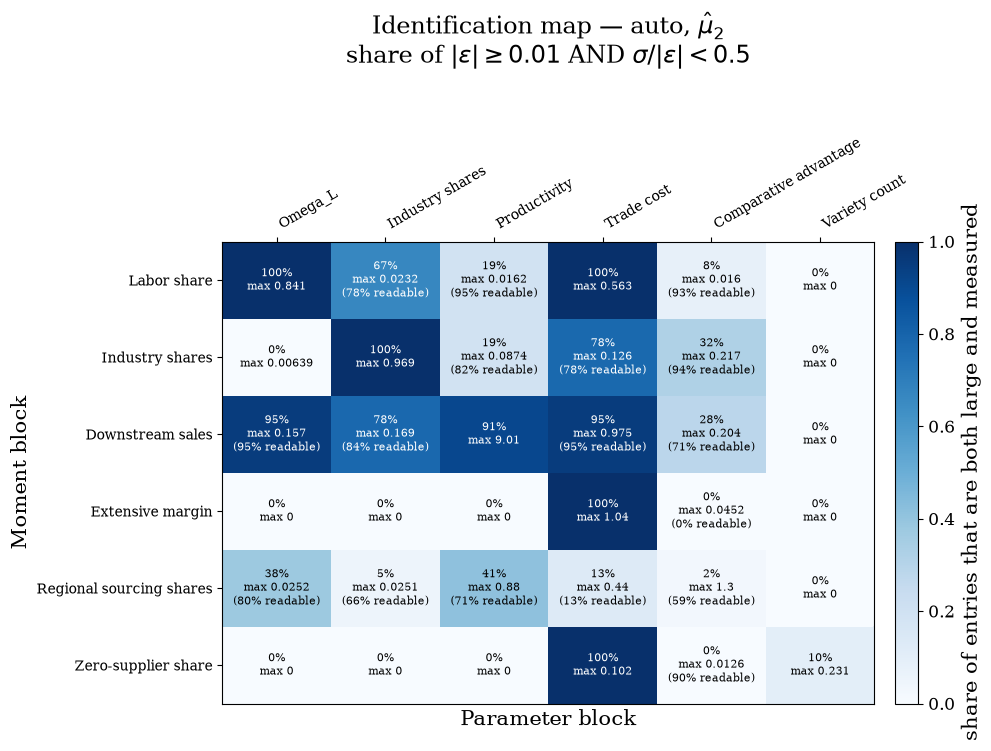

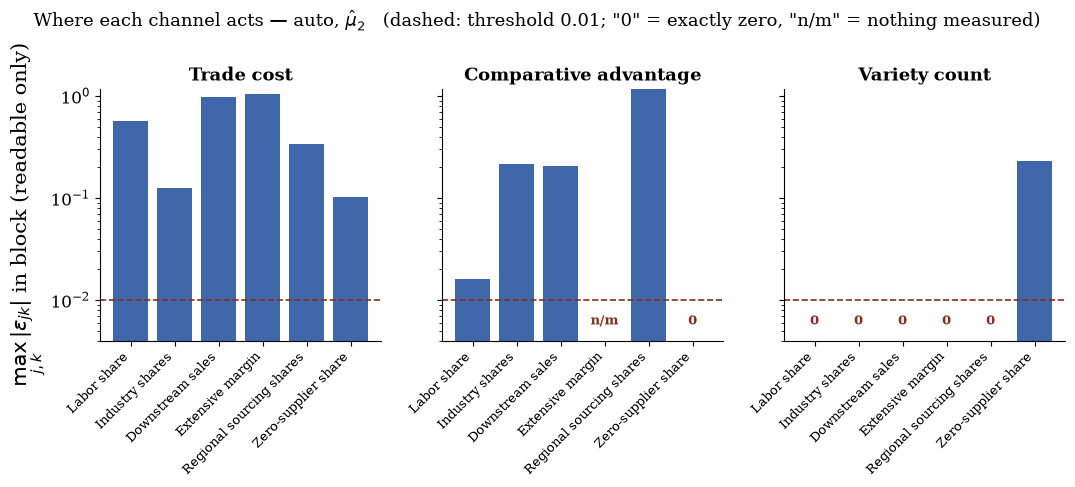

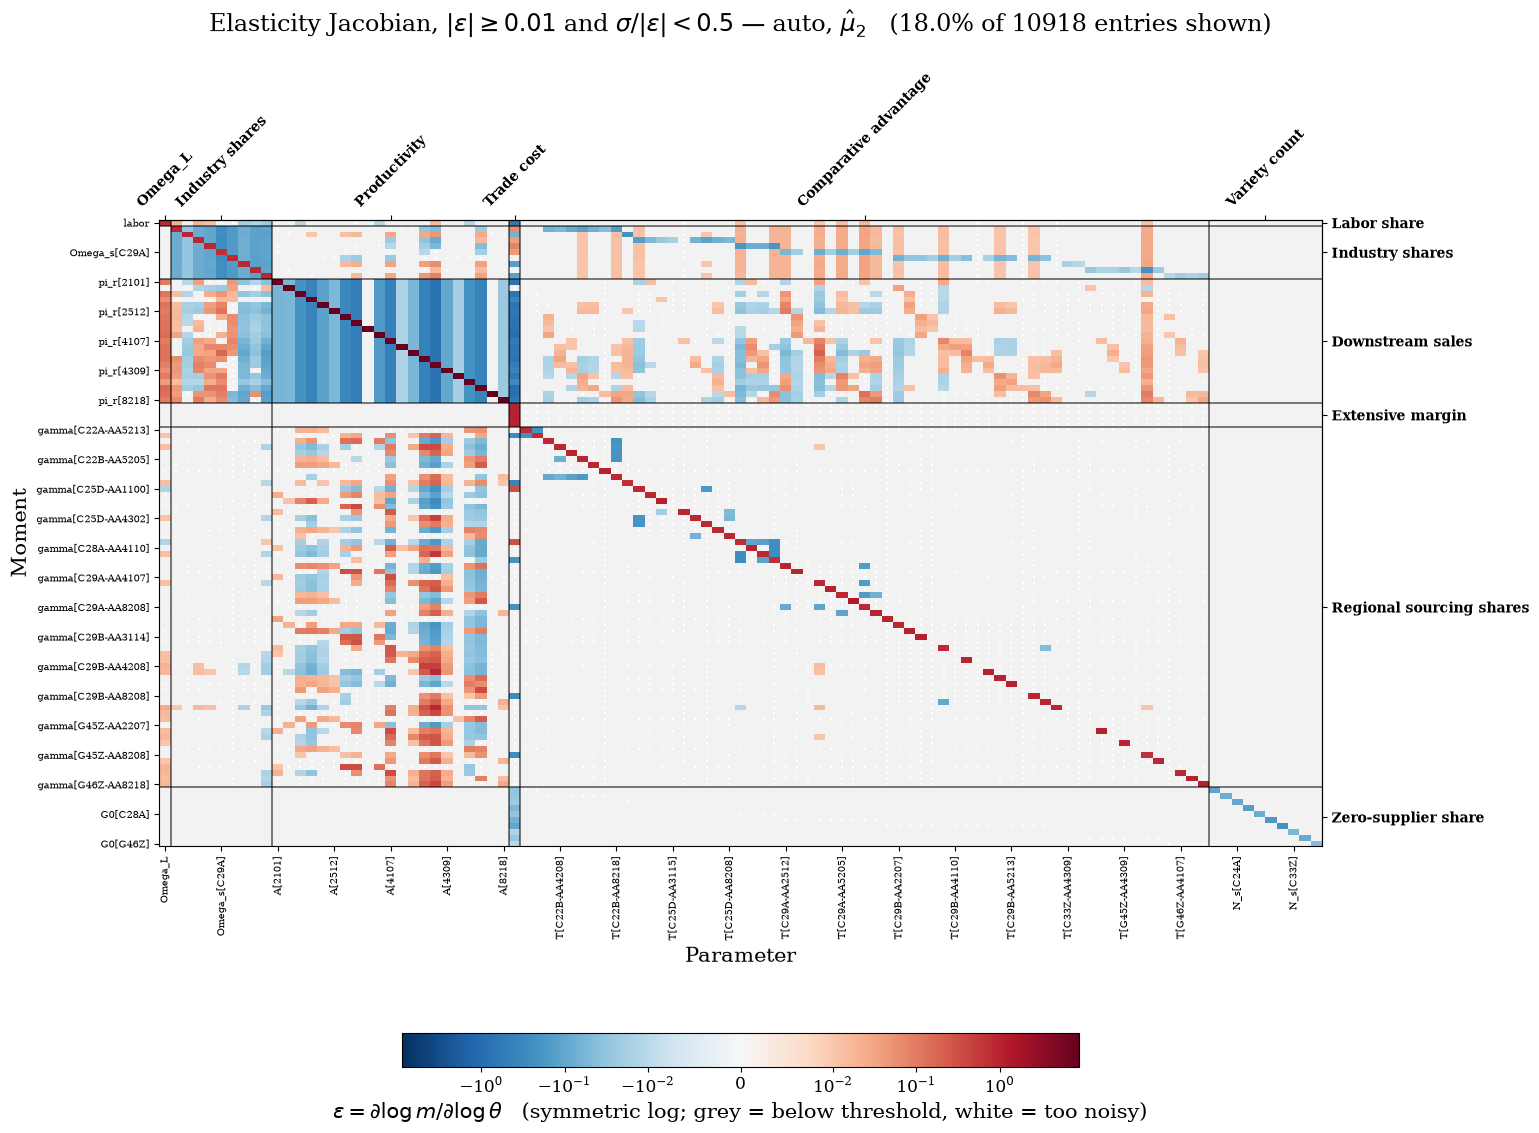

share_above                                          \
param_block                  Omega_L Industry shares Productivity Trade cost   
moment_block                                                                   
Labor share                 1.000000        0.666667     0.190476   1.000000   
Industry shares             0.000000        1.000000     0.190476   0.777778   
Downstream sales            0.952381        0.835979     0.909297   0.952381   
Extensive margin            0.000000        0.000000     0.000000   1.000000   
Regional sourcing shares    0.377049        0.047359     0.476971   0.967213   
Zero-supplier share         0.000000        0.000000     0.000000   1.000000   

                                                             share_readable  \
param_block              Comparative advantage Variety count        Omega_L   
moment_block                                                                  
Labor share                           0.081967           0.0       1.000000   
Industry shares                       0.326047           0.0       1.000000   
Downstream sales                      0.283372           0.0       0.952381   
Extensive margin                      0.278689           0.0       1.000000   
Regional sourcing shares              0.141360           0.0       0.803279   
Zero-supplier share                   0.004918           0.1       1.000000   

                                                                  ...  \
param_block              Industry shares Productivity Trade cost  ...   
moment_block                                                      ...   
Labor share                     0.777778     0.952381   1.000000  ...   
Industry shares                 1.000000     0.820106   0.777778  ...   
Downstream sales                0.841270     1.000000   0.952381  ...   
Extensive margin                1.000000     1.000000   1.000000  ...   
Regional sourcing shares        0.664845     0.710383   0.131148  ...   
Zero-supplier share             1.000000     1.000000   1.000000  ...   

                             mean_abs                                   \
param_block              Productivity Trade cost Comparative advantage   
moment_block                                                             
Labor share                  0.006423   0.563065              0.003644   
Industry shares              0.008008   0.060258              0.012580   
Downstream sales             0.615251   0.633728              0.009518   
Extensive margin             0.000000   1.020677              0.008034   
Regional sourcing shares     0.032945   0.142694              0.025708   
Zero-supplier share          0.000000   0.038070              0.000292   

                                       share_exact_zero                  \
param_block              Variety count          Omega_L Industry shares   
moment_block                                                              
Labor share                   0.000000              0.0             0.0   
Industry shares               0.000000              0.0             0.0   
Downstream sales              0.000000              0.0             0.0   
Extensive margin              0.000000              1.0             1.0   
Regional sourcing shares      0.000000              0.0             0.0   
Zero-supplier share           0.010759              1.0             1.0   

                                                                        \
param_block              Productivity Trade cost Comparative advantage   
moment_block                                                             
Labor share                       0.0        0.0                   0.0   
Industry shares                   0.0        0.0                   0.0   
Downstream sales                  0.0        0.0                   0.0   
Extensive margin                  1.0        0.0                   0.0   
Regional sourcing shares          0.0        0.0                   0.0   

/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


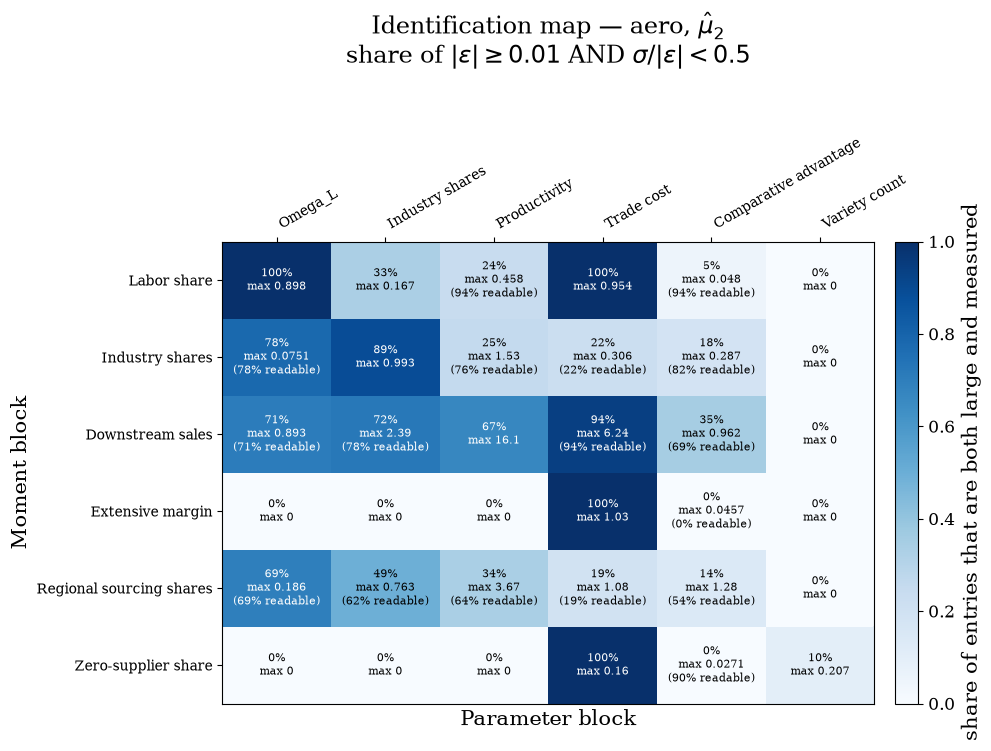

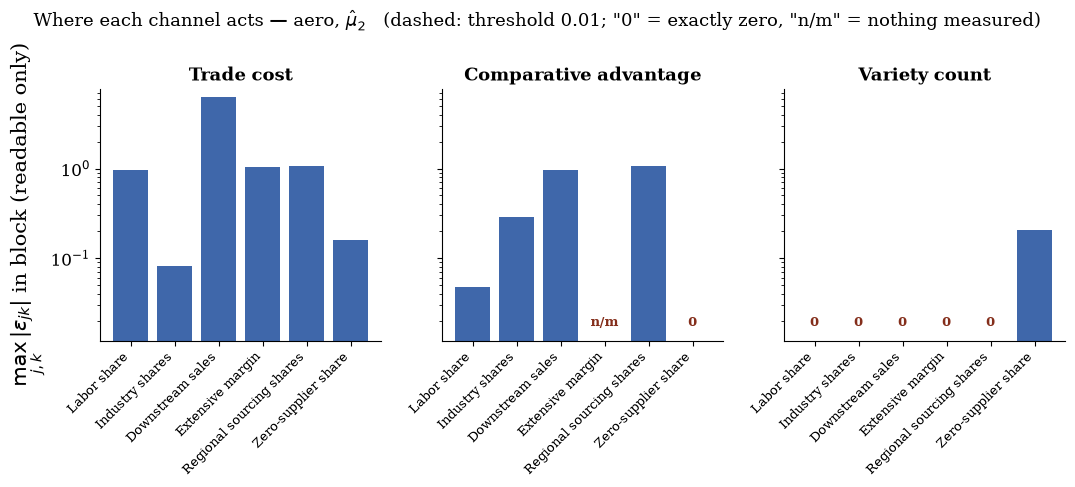

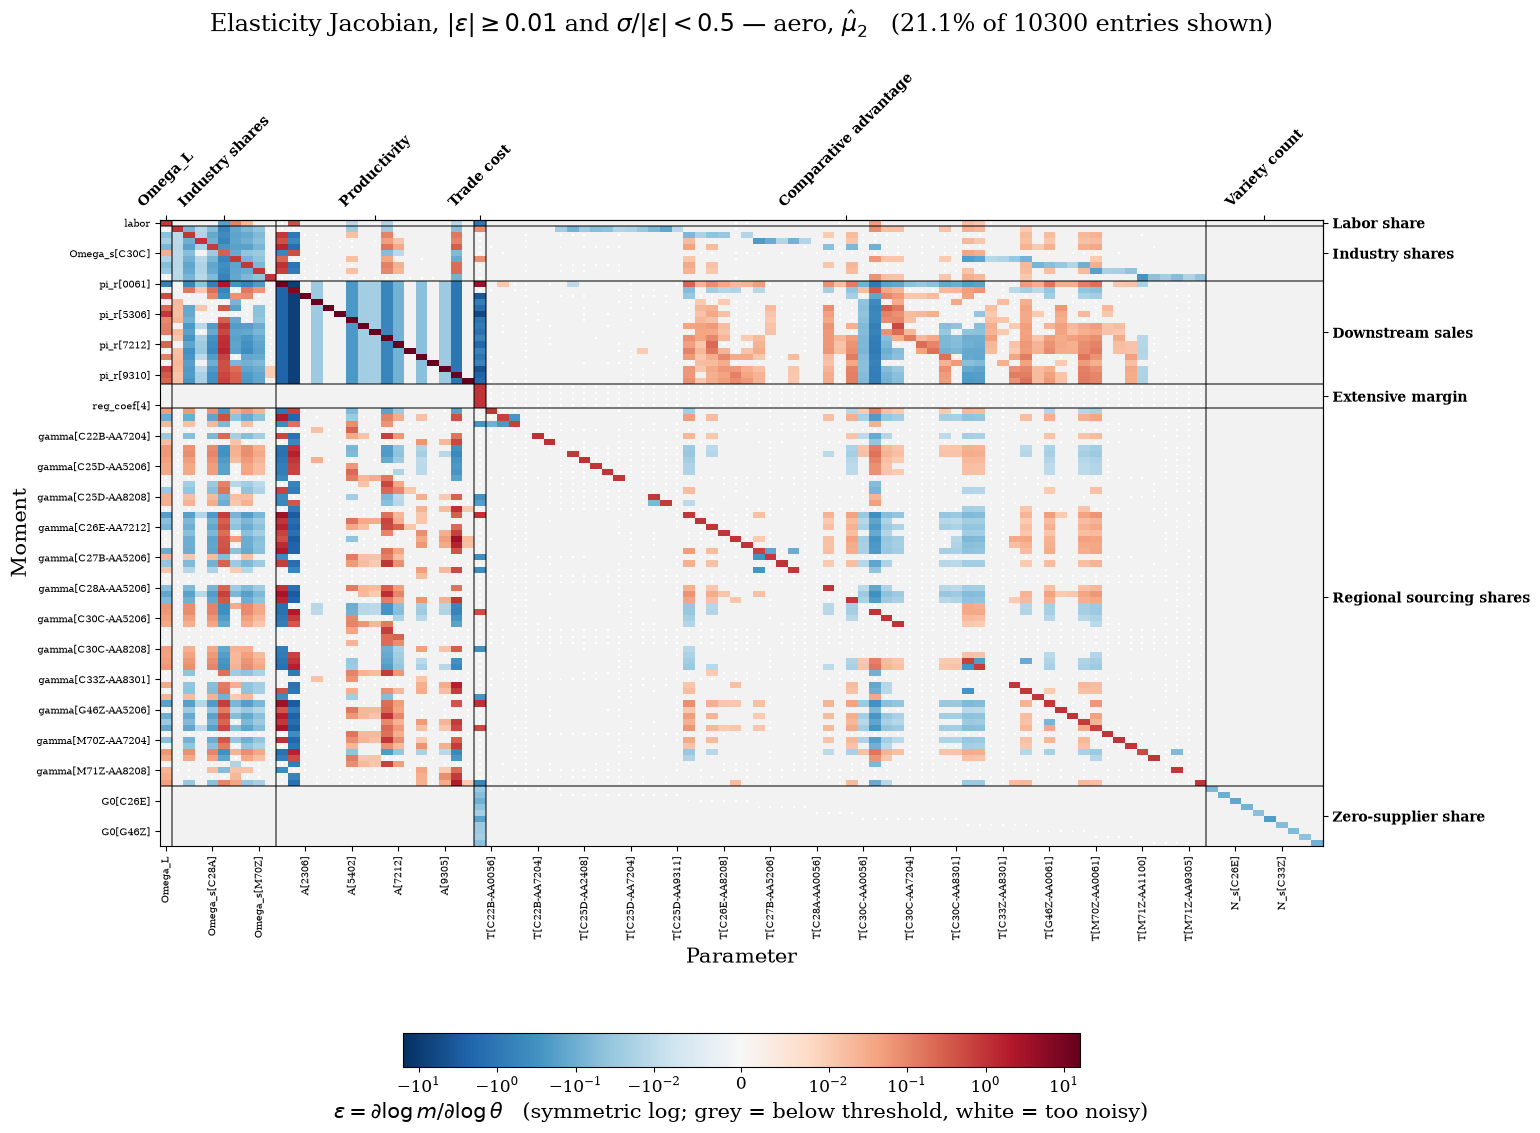

share_above                                          \
param_block                  Omega_L Industry shares Productivity Trade cost   
moment_block                                                                   
Labor share                 1.000000        0.333333     0.294118   1.000000   
Industry shares             0.777778        0.888889     0.294118   1.000000   
Downstream sales            0.941176        0.823529     0.667820   1.000000   
Extensive margin            0.000000        0.000000     0.000000   1.000000   
Regional sourcing shares    0.919355        0.578853     0.419355   0.983871   
Zero-supplier share         0.000000        0.000000     0.000000   1.000000   

                                                             share_readable  \
param_block              Comparative advantage Variety count        Omega_L   
moment_block                                                                  
Labor share                           0.048387           0.0       1.000000   
Industry shares                       0.191756           0.0       0.777778   
Downstream sales                      0.390892           0.0       0.705882   
Extensive margin                      0.129032           0.0       1.000000   
Regional sourcing shares              0.232050           0.0       0.693548   
Zero-supplier share                   0.008065           0.1       1.000000   

                                                                  ...  \
param_block              Industry shares Productivity Trade cost  ...   
moment_block                                                      ...   
Labor share                     1.000000     0.941176   1.000000  ...   
Industry shares                 1.000000     0.764706   0.222222  ...   
Downstream sales                0.784314     1.000000   0.941176  ...   
Extensive margin                1.000000     1.000000   1.000000  ...   
Regional sourcing shares        0.621864     0.639469   0.193548  ...   
Zero-supplier share             1.000000     1.000000   1.000000  ...   

                             mean_abs                                   \
param_block              Productivity Trade cost Comparative advantage   
moment_block                                                             
Labor share                  0.032798   0.954042              0.002526   
Industry shares              0.087384   0.104991              0.009190   
Downstream sales             1.596503   1.925992              0.030703   
Extensive margin             0.000000   1.008260              0.004998   
Regional sourcing shares     0.162469   0.280802              0.027504   
Zero-supplier share          0.000000   0.053580              0.000323   

                                       share_exact_zero                  \
param_block              Variety count          Omega_L Industry shares   
moment_block                                                              
Labor share                      0.000              0.0             0.0   
Industry shares                  0.000              0.0             0.0   
Downstream sales                 0.000              0.0             0.0   
Extensive margin                 0.000              1.0             1.0   
Regional sourcing shares         0.000              0.0             0.0   
Zero-supplier share              0.009              1.0             1.0   

                                                                        \
param_block              Productivity Trade cost Comparative advantage   
moment_block                                                             
Labor share                       0.0        0.0                   0.0   
Industry shares                   0.0        0.0                   0.0   
Downstream sales                  0.0        0.0                   0.0   
Extensive margin                  1.0        0.0                   0.0   
Regional sourcing shares          0.0        0.0                   0.0   

In [16]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    plot_identification_map(
        data, threshold=IDENT_THRESHOLD, noise_max=NOISE_MAX,
        save_to=f"{out_folder}/identification_map_{industry}_mu{MU}.pdf")
    plt.show()
    plot_channel_elasticities(
        data, threshold=IDENT_THRESHOLD, noise_max=NOISE_MAX,
        save_to=f"{out_folder}/identification_channels_{industry}_mu{MU}.pdf")
    plt.show()
    plot_jacobian_thresholded(
        data, threshold=IDENT_THRESHOLD, noise_max=NOISE_MAX,
        save_to=f"{out_folder}/jacobian_thresholded_{industry}_mu{MU}.pdf")
    plt.show()
    display(identification_summary(data, threshold=IDENT_THRESHOLD, noise_max=NOISE_MAX))


# Untargeted moment — the distance elasticity of spatial comovement

**The test.** The estimation targets the spatial decay of production **linkages** (moment
block 4). It does not target how the equilibrium network turns those linkages into the
spatial propagation of downstream shocks — which is what the reduced-form ratio
$\delta/\gamma$ of Table 3 measures. Appendix B.5 shows that ratio identifies

$$\frac{\partial \log \mathbb{E}\!\left[a_{ir}\mid s, r', \mathrm{Dist}_{r'r}=d\right]}{\partial \log d},$$

with $a_{ir}$ the share of supplier $i$'s sales directed to downstream region $r$. The
model counterpart computes $a_{ir}$ in the simulated economy and estimates

$$\mathbb{E}\!\left[a_{ir}\mid s, r', r\right] \;=\; \exp\!\big(\alpha_{r,s(i)} + \eta \log \mathrm{Dist}_{r'r}\big),$$

with $\alpha_{r,s(i)}$ a sector $\times$ downstream-region fixed effect. Nothing in the
criterion was asked to match it, which is what makes it a test rather than a fit.

**Why PPML.** Slightly more than half of the supplier $\times$ downstream-region cells are
zeros, and those zeros *are* half of the object — the first of the two forces inside $\eta$
is the extensive margin — so logs are not available. Poisson pseudo-ML is consistent for the
conditional **mean** under the exponential specification alone, so $a_{ir}$ need not be a
count and the zeros enter unmodified. The estimator is `pyfixest.fepois` (the `ppmlhdfe`
algorithm), the fixed effect absorbed, standard errors clustered on the supplier's own
region as in Table 3.

**Two things stand between $\hat\eta$ and the published number**, and both are worked out in
the next markdown cell rather than here. *The scale*: $\delta/\gamma$ comes from a regression
linear in the **level** of the exposure, so it is a compressed reading of an elasticity,
$\delta/\gamma \approx \eta/(1+|\eta|\overline{\log d})$, bounded by $1/\overline{\log d}$;
every estimate is therefore reported on both scales and every comparison is drawn on the
reduced form's. *The variation*: a sector $\times$ buyer-region effect compares **different
suppliers** at the same buyer, a supplier effect compares **one supplier** across its own
buyers, and in the model these are different objects — the first carries a composition term
the second removes. The moment is estimated under both and under both at once
(`UNTARGETED_FE_SPECS`).

**The economy it runs on.** `main.jl`'s post-hoc block writes `suppliers.parquet` into the
step folder of the estimate it was computed at (`step1/` for $\hat\theta_1$, `step3/` for
$\hat\theta_2$), so `mu` selects the firm-level economy exactly as it selects the moments and
the inference.

### What `suppliers.parquet` contains

One row per **realised linkage**: a (simulated firm, downstream region) pair such that the
firm won at least one variety supplied to that region. A firm is a (cell, sector, variety)
triple — one variety producer, which is the model's supplier — and the file has no row for a
firm-region pair with no linkage, which is why the panel below has to be zero-filled.

| column | what it is |
|--------|-----------|
| `SIREN` | synthetic firm identifier, one per (upstream region, sector, variety) triple |
| `A129` | the sector, as the model's own index $1..S$ — **not** the A129 code; map through `sector_names` |
| `ze2010` | the **supplier's** region, as the model's own index $1..R$ (regions sorted by ZE code) |
| `ze2010_downstream` | the **buyer's** downstream region, same $1..R$ index space |
| `share` | the badly-named one. It is $\texttt{exp\_val}$: the share of the buyer region's **unit cost** spent on this firm, $w_\rho\,\Omega^s(1-\Omega^L)(p_{\rho s}/P_{sr})^{1-\nu_s}(P_{sr}/P_r)^{1-\nu}(P_r/c_r)^{1-\lambda}$. Summed over every firm it gives that region's intermediate-input share of cost — it is *not* a share of the supplier's sales, and it is *not* normalised within the supplier |
| `downstream_purchase` | $\mu Y_r$, the buyer region's total spending on intermediates. `share` $\times$ `downstream_purchase` is the euro flow $X_{i \to r}$ |
| `intermediate_derivative` | `share` renormalised *within* intermediates ($\texttt{exp\_val}$ divided by $(1-\Omega^L)(P_r/c_r)^{1-\lambda}$). Sums to one by construction, so it is a composition, not a magnitude — do not use it as a flow |
| `productivity` | the firm's Fréchet productivity draw $z$ |
| `sample_weight` | the Monte-Carlo weight of the variety draw ($1/N_\rho$ under the flat designs), i.e. how many real firms this simulated one stands for |

The moment's regressand is built from these: $X_{i \to r} = \texttt{share} \times
\texttt{downstream\_purchase}$ and $a_{ir} = X_{i\to r}/\sum_{r'} X_{i \to r'}$, which sums to
one over $r$ for every supplier.

### The decomposition $\eta = \eta_{ext} + \eta_{int}$

Write $\Lambda_{ir} = \mathbf{1}\{a_{ir}>0\}$. Then $\mathbb{E}[a_{ir}] = \Pr(\Lambda_{ir}=1)
\times \mathbb{E}[a_{ir}\mid \Lambda_{ir}=1]$ exactly, so

$$\eta \;=\; \underbrace{\frac{\partial \log \Pr(\Lambda=1)}{\partial \log d}}_{\eta_{ext}} \;+\; \underbrace{\frac{\partial \log \mathbb{E}[a\mid \Lambda=1]}{\partial \log d}}_{\eta_{int}},$$

and each term is exactly what its own PPML estimates: the coefficient on $\log d$ in
$\mathbb{E}[y\mid\cdot] = \exp(\alpha_g + \beta \log d)$ is $\partial \log
\mathbb{E}[y\mid\cdot]/\partial\log d$ for any non-negative $y$. Put $y = a_{ir}$ on the full
panel and $\beta = \eta$; $y = \Lambda_{ir}$ on the full panel and $\beta = \eta_{ext}$ —
Poisson on a binary outcome rather than a logit, because the identity is about the
**probability**, whose elasticity PPML returns, and not the odds, whose elasticity a logit
returns; $y = a_{ir}$ on the positive cells and $\beta = \eta_{int}$. The identity is exact in
the population, but in the sample the three regressions absorb their own fixed effects and the
third does so on the selected subsample of positive cells, so
`decompose_untargeted_moment` reports the residual rather than assuming it away.

**What is inside $\eta_{int}$ — and why it carries the paper's hub story.** $a_{ir}$ is a
*portfolio share*, $a_{ir} = \rho_{ir}\mu Y_r / \sum_{r'}\rho_{ir'}\mu Y_{r'}$. The
numerator's $Y_r$ is absorbed by the buyer-region fixed effect; the denominator's is not — it
is supplier-specific and dominated by the *large* regions that supplier serves. Hence

$$\frac{\partial \log a_{ir}}{\partial \log d_{ir}} \;=\; \frac{\partial \log \rho_{ir}}{\partial \log d_{ir}}\,\big(1 - a_{ir}\big),$$

the $(1-a)$ term of Appendix B.5: moving a supplier away from $r$ costs it sales in $r$ *and*
reallocates the rest toward its other buyers, so the share falls by less than the flow does,
and by much less when $r$ is a small part of the portfolio. This is precisely the paper's
reading of the cross-industry contrast — motor vehicles' many hubs give diversified portfolios
(small $a$, large $1-a$, much scope for reallocation), aerospace's two hubs give concentrated
ones — and here it is *measured* instead of argued. It lives entirely in $\eta_{int}$:
$\eta_{ext}$ is a probability and free of $Y$.

### What the section produces

**Figure 1 — `untargeted_eta_mu{MU}.pdf` (`plot_untargeted_moment`): the headline
comparison.** One group of points per industry; the vertical axis is $\delta/\gamma$, the
reduced form's own scale, so each model elasticity has been mapped through
$\delta/\gamma = \eta/(1+|\eta|\overline{\log d})$. Inside a group there are three model
markers, one per fixed-effect specification — circle: sector $\times$ buyer region (the
paper's), triangle up: supplier, triangle down: both — each with its 95% interval, and a
square for the published Table-3 estimate with its own interval. The dotted line is the
ceiling $-1/\overline{\log d} = -0.17$, beyond which no level-linear ratio can lie, in the
model or in the data. Two things to read off it: the **vertical spread of the three model
markers is the composition channel** (cross-supplier minus within-supplier), and the distance
from those markers to the square is what is left to explain once the scale is fixed.
`scale="eta"` redraws the same picture in raw elasticities, where only the model points are on
the right scale — a diagnostic, not a comparison.

**Figure 2 — `untargeted_ladder_<industry>_mu{MU}.pdf` (`plot_untargeted_ladder`), one per
industry: the gap taken apart.** One horizontal bar per rung of
`untargeted_specification_ladder`, all fitted on the same simulated panel and all on the
$\delta/\gamma$ scale, the reported $\hat\eta$ at the top and the published number at the
bottom. The shaded band is the data's 95% CI, the dotted line the same ceiling, the black
whiskers the 95% intervals of the rungs that are estimated. **A rung that falls inside the
band is a specification difference which, on its own, reconciles the model with Table 3.**

**Figure 3 — `untargeted_profile_mu{MU}.pdf` (`plot_a_ir_profile`): the shape behind
$\eta$.** Distance-bin dummies replace $\log d$ in the *same* PPML — same outcome, same fixed
effect, same weights and clustering — so the log-linear form is not imposed. The solid line
(95% bars, one per industry) is $\log \mathbb{E}[a_{ir}]$ relative to the nearest bin *within*
a (sector, buyer region) cell: the same variation $\hat\eta$ uses, read non-parametrically,
and **not** a mean profile across sectors. The dashed line is the unconditional profile — the
weighted mean by bin, no fixed effect — so the gap between the two is what the fixed effect
removes, i.e. that distant supplier-buyer pairs are not drawn from the same sectors and buyer
regions as nearby ones. A solid line close to straight in log distance is the check that a
constant elasticity summarises the profile fairly.

**Two tables.** `decompose_untargeted_moment` prints $\eta$, $\eta_{ext}$, $\eta_{int}$ and
the residual of the identity. `untargeted_summary` is indexed by (industry, fixed effect) and
its comparison column is `delta/gamma (model)` against `delta/gamma (data)`, with an
`inside data CI` flag — never $\eta$ against $\delta/\gamma$, which are two readings of the
same profile on two different scales.


In [17]:
# The (supplier x downstream region) panel, and the PPML that reads eta off it.
# The estimator is pyfixest.fepois — ppmlhdfe's algorithm — so nothing about Poisson
# pseudo-ML is re-implemented here.

# Empirical delta/gamma from Table 3 (the spatial comovement regression): point estimate
# and 95% CI. These are DATA, not model output, and they are not read from any file in
# this repository — override them here if the reduced-form estimates change.
EMPIRICAL_DELTA_OVER_GAMMA = {
    "auto": {"estimate": -0.109, "ci_lo": -0.122, "ci_hi": -0.096,
             "display_name": "Motor Vehicles"},
    "aero": {"estimate": -0.098, "ci_lo": -0.130, "ci_hi": -0.065,
             "display_name": "Aerospace"},
}


def build_a_ir_panel(data, min_distance_km=1.0, firm_key=("SIREN",)):
    """
    The (supplier x downstream region) panel the PPML runs on, ZERO-FILLED.

    `suppliers.parquet` records only realised linkages (see the column glossary above).
    The regression needs the non-linkages too — a supplier that does not serve region r
    has a_ir = 0, and that extensive margin is half of what the moment measures — so
    every supplier is crossed with every downstream region and the missing cells are
    filled at 0.

    The sample is suppliers, i.e. varieties that win somewhere, which is the
    conditioning Sup_i = 1 of equation (3) and of (B36).

    Region codes are the model's own 1..R indices for BOTH `ze2010` (the supplier's
    cell) and `ze2010_downstream` (the buyer), so the distance is read straight out of
    `distances.npy` with no name round-trip.

    `firm_key` is what counts as one supplier. The default is the parquet's own `SIREN`,
    i.e. ONE VARIETY in one cell — the model's supplier. Passing `("ze2010", "A129")`
    pools every variety a (region, sector) produces into a single multi-variety firm,
    which is closer to what a SIREN is in the data and flattens the distance profile; the
    specification ladder below uses it to measure how much.

    `min_distance_km` is a floor, not a convention: the own-region entry of the distance
    matrix is the region's own internal distance, which is POSITIVE and differs across
    regions (a large commuting zone is further from itself than a small one), exactly as
    the model uses it. The floor only guards against a data file that happens to store a
    hard zero on the diagonal, which would send log d to -infinity.
    """
    sup = data.get("suppliers")
    if sup is None:
        raise FileNotFoundError(
            f"no suppliers.parquet under {data['folder']}/{data['step_dir']}/ (or it was "
            "unreadable — pyarrow missing?). main.jl writes one per estimate in its "
            "post-hoc block, after the estimation.")

    dist_path = data["input_folder"] / "distances.npy"
    if not dist_path.exists():
        raise FileNotFoundError(f"{dist_path} not found — needed for log Dist_{{r'r}}.")
    D = np.load(dist_path)
    R = data["R"]
    if D.shape[0] < R or D.shape[1] < R:
        raise ValueError(f"distances.npy is {D.shape}, too small for R = {R} regions.")
    D = D[:R, :R]

    df = sup[["SIREN", "A129", "ze2010", "ze2010_downstream",
              "share", "downstream_purchase", "productivity", "sample_weight"]].copy()

    # The supplier identifier. Under the default it IS the parquet's SIREN; under an
    # aggregating `firm_key` the column is rebuilt from the key, and the euro flows of the
    # pooled varieties are added before the share is formed — which is what makes the
    # aggregated firm a genuine multi-variety supplier rather than an average of shares.
    if tuple(firm_key) != ("SIREN",):
        df["SIREN"] = df[list(firm_key)].astype(str).agg("-".join, axis=1)

    # X_{i->r} = share x (mu Y_r); a_ir = X_{i->r} / sum_r X_{i->r}
    df["X_ir"] = df["share"] * df["downstream_purchase"]
    # how many real firms one simulated supplier stands for: the MEAN of its varieties'
    # draw weights, so that pooling varieties does not multiply the weight (under the
    # flat draw designs every variety carries 1/N_rho and a pooled firm still does)
    w_firm = df.groupby("SIREN", sort=True)["sample_weight"].mean()
    df = (df.groupby(["SIREN", "ze2010_downstream"], as_index=False)
            .agg(A129=("A129", "first"), ze2010=("ze2010", "first"),
                 X_ir=("X_ir", "sum"), productivity=("productivity", "mean")))
    tot = df.groupby("SIREN", sort=False)["X_ir"].transform("sum")
    df["a_ir"] = np.where(tot > 0, df["X_ir"] / tot, 0.0)

    # --------------------------------------------------------- zero-filling ---
    firms = df.groupby("SIREN", sort=True).agg(
        A129=("A129", "first"), ze2010=("ze2010", "first"),
        productivity=("productivity", "first")).reset_index()
    firms["sample_weight"] = firms["SIREN"].map(w_firm)
    downstream = np.sort(df["ze2010_downstream"].unique())

    panel = firms.merge(pd.DataFrame({"ze2010_downstream": downstream}), how="cross")
    panel = panel.merge(df[["SIREN", "ze2010_downstream", "a_ir"]],
                        on=["SIREN", "ze2010_downstream"], how="left")
    panel["a_ir"] = panel["a_ir"].fillna(0.0)

    # ------------------------------------------------------------ regressors --
    d = D[panel["ze2010"].to_numpy() - 1, panel["ze2010_downstream"].to_numpy() - 1]
    panel["distance"] = d
    panel["log_distance"] = np.log(np.maximum(d, min_distance_km))
    panel["log_productivity"] = np.log(np.maximum(panel["productivity"].to_numpy(), 1e-300))
    panel["served"] = (panel["a_ir"].to_numpy() > 0).astype(float)
    # alpha_{r, s(i)} : sector x downstream-region
    panel["fe_group"] = (panel["A129"].astype(str) + "-"
                         + panel["ze2010_downstream"].astype(str))
    panel["cluster"] = panel["ze2010"].astype(str)     # supplier's region, as in Table 3
    return panel


def fepois_fit(panel, y, rhs=("log_distance",), fe="fe_group", cluster="cluster",
               weights="sample_weight"):
    """
    One `pyfixest.fepois` call: E[y | .] = exp(fixed effect + rhs'beta).

    `fe` is passed to pyfixest as written, so "fe_group" absorbs the sector x
    downstream-region effect, "SIREN" absorbs a SUPPLIER effect, and "fe_group + SIREN"
    absorbs both.

    A three-line wrapper around the library, not an estimator: it writes the formula,
    passes the Monte-Carlo draw weights as analytic weights, clusters on the supplier's
    own region and lets pyfixest drop the fixed-effect groups that are separated (a
    group with no positive outcome contributes nothing to the Poisson score, exactly as
    in `ppmlhdfe`). Returns the fitted object, so `.coef()`, `.se()`, `.tidy()` and
    `.summary()` are all available at the call site.
    """
    fml = f"{y} ~ " + " + ".join(rhs) + (f" | {fe}" if fe else "")
    return pf.fepois(fml=fml, data=panel, weights=weights, weights_type="aweights",
                     vcov=None if cluster is None else {"CRV1": cluster},
                     separation_check=["fe"])


def delta_over_gamma_from_eta(eta, mean_log_d=None):
    """
    A constant elasticity `eta` expressed as the reduced form's `delta/gamma`.

    The spatial-comovement regression is LINEAR IN THE LEVEL of the exposure — gamma on
    the demand shock, delta on the shock interacted with log distance — so it fits
    E[a|d] = gamma + delta log d. Fitting a constant-elasticity profile A d^eta that way
    puts gamma at the extrapolated intercept log d = 0 (one kilometre, far outside any
    data), and linearising around the mean gives

        delta/gamma  ~=  eta / (1 + |eta| * mean(log d)).

    Two things follow. The map is strongly COMPRESSIVE, and it is BOUNDED: whatever the
    true elasticity, |delta/gamma| can never exceed 1/mean(log d) — 0.17 at the empirical
    mean of 5.8. So a model eta and a published delta/gamma cannot be compared as they
    stand; one has to be put on the other's scale, which is what this does.

    `mean_log_d` defaults to `EMPIRICAL_MEAN_LOG_D`, the mean in the ESTIMATION SAMPLE OF
    THE REDUCED FORM — the right one here, since the compression is a property of the
    regression that produced the published number, not of the simulated geography.
    """
    m = EMPIRICAL_MEAN_LOG_D if mean_log_d is None else mean_log_d
    return float(eta) / (1.0 + abs(float(eta)) * m)


def eta_from_delta_over_gamma(ratio, mean_log_d=None):
    """The inverse map: the constant elasticity a published `delta/gamma` implies."""
    m = EMPIRICAL_MEAN_LOG_D if mean_log_d is None else mean_log_d
    r = float(ratio)
    denom = 1.0 - abs(r) * m
    return r / denom if denom > 0 else -np.inf


# The fixed effects the moment is estimated under. The first is the paper's own
# specification; the other two are the diagnostic the comparison with the data needs.
UNTARGETED_FE_SPECS = {
    "sector x buyer region": "fe_group",
    "supplier (firm FE)": "SIREN",
    "both": "fe_group + SIREN",
}


def estimate_untargeted_moment(data, controls=(), cluster="cluster", panel=None,
                               fe_specs=UNTARGETED_FE_SPECS, verbose=True):
    """
    PPML estimate of eta in E[a_ir] = exp(fixed effect + eta log Dist_{r'r}), under each
    fixed-effect specification in `fe_specs`.

    The FIRST entry is the headline: a sector x downstream-region effect, the paper's own
    specification. It compares DIFFERENT SUPPLIERS serving the same buyer, so the distance
    gradient it measures includes a composition term — a supplier far from r is, in this
    geography, necessarily close to some other buyer, and that buyer dominates the
    denominator of its portfolio share.

    The SUPPLIER fixed effect removes exactly that: it compares one supplier's shares
    across ITS OWN buyers, which is the variation a firm-fixed-effect shock regression
    uses, and which the model bounds at theta*alpha(1-a). Absorbing BOTH leaves only the
    variation that is within a supplier and within a buyer region at once.

    `controls` adds columns of the panel to the right-hand side (the paper's
    specification has none; `("log_productivity",)` conditions on the supplier's
    productivity draw). `cluster=None` gives the classical Poisson variance.
    """
    panel = build_a_ir_panel(data) if panel is None else panel
    cols = ["log_distance"] + list(controls)
    specs = {}
    for label, fe in fe_specs.items():
        fit = fepois_fit(panel, "a_ir", rhs=cols, fe=fe, cluster=cluster)
        b = float(fit.coef()["log_distance"])
        se = float(fit.se()["log_distance"])
        specs[label] = {"fe": fe, "eta": b, "se": se,
                        "ci_lo": b - 1.96 * se, "ci_hi": b + 1.96 * se,
                        "dg": delta_over_gamma_from_eta(b),
                        "dg_lo": delta_over_gamma_from_eta(b - 1.96 * se),
                        "dg_hi": delta_over_gamma_from_eta(b + 1.96 * se),
                        "n_obs": int(getattr(fit, "_N", len(panel))), "fit": fit}

    head = specs[list(fe_specs)[0]]
    eta, se = head["eta"], head["se"]
    emp = EMPIRICAL_DELTA_OVER_GAMMA.get(data["industry"], {})
    out = {"industry": data["industry"], "mu": data["mu"], "spec": "+".join(cols),
           "eta": eta, "se": se, "t": eta / se if se > 0 else np.nan,
           "ci_lo": head["ci_lo"], "ci_hi": head["ci_hi"],
           # the same estimate on the reduced form's own scale
           "dg": head["dg"], "dg_lo": head["dg_lo"], "dg_hi": head["dg_hi"],
           "specs": specs,
           "coefs": head["fit"].coef().to_dict(), "ses": head["fit"].se().to_dict(),
           "n_obs": head["n_obs"], "n_firms": int(panel["SIREN"].nunique()),
           "share_zero": float((panel["a_ir"].to_numpy() == 0).mean()),
           "emp_estimate": emp.get("estimate"), "emp_ci_lo": emp.get("ci_lo"),
           "emp_ci_hi": emp.get("ci_hi"), "fit": head["fit"], "panel": panel}

    if verbose:
        print(f"[{data['industry']}]  {len(panel):,} supplier x downstream-region cells, "
              f"{out['n_firms']:,} suppliers, {100 * out['share_zero']:.1f}% zeros, "
              f"from {data['suppliers_path']}")
        print(f"{'  fixed effect':<26}{'eta':>10}{'se':>9}   "
              f"{'-> delta/gamma':>15}  (mean log d = {EMPIRICAL_MEAN_LOG_D})")
        for label, sp in specs.items():
            print(f"  {label:<24}{sp['eta']:>+10.4f}{sp['se']:>9.4f}   "
                  f"{sp['dg']:>+15.4f}  [{sp['dg_lo']:+.4f}, {sp['dg_hi']:+.4f}]")
        if out["emp_estimate"] is not None:
            print(f"  {'DATA delta/gamma':<24}{'':>10}{'':>9}   "
                  f"{out['emp_estimate']:>+15.4f}  [{out['emp_ci_lo']:+.4f}, "
                  f"{out['emp_ci_hi']:+.4f}]")
    return out


def decompose_untargeted_moment(data, panel=None, cluster="cluster", verbose=True):
    """
    eta split into its extensive and intensive parts, as derived in the markdown above.

    E[a_ir] = P(i serves r) x E[a_ir | i serves r], so the elasticity of the product is
    the sum of the two elasticities:

        eta = eta_ext + eta_int,
        eta_ext : PPML on the 0/1 indicator — the elasticity of the PROBABILITY of
                  serving the region (Poisson, not logit, precisely because the identity
                  is about the probability and not the odds),
        eta_int : PPML on the positive a_ir — the elasticity of the conditional mean,
                  which carries the (1 - a) portfolio term.

    Exact in the population; in the sample the three regressions absorb their own fixed
    effects, and the intensive one does so on the selected subsample of positive cells,
    so the residual is reported rather than assumed away.
    """
    panel = build_a_ir_panel(data) if panel is None else panel
    pos = panel[panel["a_ir"] > 0]

    total = fepois_fit(panel, "a_ir", cluster=cluster)
    ext = fepois_fit(panel, "served", cluster=cluster)
    inte = fepois_fit(pos, "a_ir", cluster=cluster)

    rows = [("eta (total)", total, len(panel)),
            ("eta_ext (extensive: probability of serving)", ext, len(panel)),
            ("eta_int (intensive: portfolio share, served cells)", inte, len(pos))]
    df = pd.DataFrame([{"channel": name,
                        "coefficient": float(f.coef()["log_distance"]),
                        "se": float(f.se()["log_distance"]),
                        "n_obs": n} for name, f, n in rows])
    gap = float(df.loc[0, "coefficient"] - df.loc[1, "coefficient"] - df.loc[2, "coefficient"])
    if verbose:
        print(df.to_string(index=False))
        print(f"  eta - (eta_ext + eta_int) = {gap:+.4f}   "
              "(exactly zero only when the three fixed effects coincide)")
    return {"table": df, "gap": gap, "total": total, "extensive": ext, "intensive": inte}


In [18]:
# The untargeted-moment figures and the summary table.

def untargeted_summary(results):
    """
    One row per (industry, fixed-effect specification): the model's eta, the delta/gamma
    it corresponds to under the reduced form's functional form, and the published number.

    The comparison column is `delta/gamma (model)`, NOT eta: the two are different
    readings of the same profile, and only the first is on the scale Table 3 reports.
    """
    rows = []
    for r in results:
        emp = EMPIRICAL_DELTA_OVER_GAMMA.get(r["industry"], {})
        for label, sp in r["specs"].items():
            rows.append({
                "industry": emp.get("display_name", r["industry"]),
                "fixed effect": label,
                "eta (model)": sp["eta"],
                "se": sp["se"],
                "delta/gamma (model)": sp["dg"],
                "95% CI (model, delta/gamma)": f"[{sp['dg_lo']:+.3f}, {sp['dg_hi']:+.3f}]",
                "delta/gamma (data)": r["emp_estimate"],
                "95% CI (data)": (f"[{r['emp_ci_lo']:+.3f}, {r['emp_ci_hi']:+.3f}]"
                                  if r["emp_ci_lo"] is not None else "---"),
                "inside data CI": (None if r["emp_ci_lo"] is None
                                   else bool(r["emp_ci_lo"] <= sp["dg"] <= r["emp_ci_hi"])),
                "suppliers": r["n_firms"], "cells": sp["n_obs"],
            })
    return pd.DataFrame(rows).set_index(["industry", "fixed effect"])


MODEL_SPEC_MARKERS = {"sector x buyer region": ("o", sim_color),
                      "supplier (firm FE)": ("^", (0.30, 0.55, 0.40)),
                      "both": ("v", (0.45, 0.40, 0.60))}


def plot_untargeted_moment(results, scale="delta_over_gamma", figsize=None, save_to=None):
    """
    The model against the published reduced form, one group per industry.

    `scale="delta_over_gamma"` (the default) is the comparison that means something: each
    model estimate is mapped through `delta_over_gamma_from_eta`, i.e. read the way the
    spatial-comovement regression would have read the same profile. On that scale the
    dashed line is the ceiling 1/mean(log d) — no reduced-form ratio, in the model or in
    the data, can lie beyond it, which is worth seeing next to the estimates.
    `scale="eta"` plots the raw elasticities instead, and then only the model points are
    on the right scale.

    Every fixed-effect specification is drawn: the paper's sector x buyer-region effect,
    the supplier effect, and both. The spread between them IS the composition channel.
    """
    dg = scale == "delta_over_gamma"
    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.95, hf=0.65))
    x = np.arange(len(results))
    labels = list(MODEL_SPEC_MARKERS)
    offs = np.linspace(-0.22, 0.06, len(labels))

    for i, r in enumerate(results):
        for k, label in enumerate(labels):
            sp = r["specs"].get(label)
            if sp is None:
                continue
            v = sp["dg"] if dg else sp["eta"]
            lo = sp["dg_lo"] if dg else sp["ci_lo"]
            hi = sp["dg_hi"] if dg else sp["ci_hi"]
            m, c = MODEL_SPEC_MARKERS[label]
            ax.errorbar(x[i] + offs[k], v, yerr=[[v - lo], [hi - v]], fmt=m, color=c,
                        capsize=4, markersize=7,
                        label=f"Model, {label} FE" if i == 0 else None)
        if r["emp_estimate"] is not None and dg:
            ax.errorbar(x[i] + 0.22, r["emp_estimate"],
                        yerr=[[r["emp_estimate"] - r["emp_ci_lo"]],
                              [r["emp_ci_hi"] - r["emp_estimate"]]],
                        fmt="s", color=reference_color, capsize=4, markersize=8,
                        label="Data $\\delta/\\gamma$ (Table 3)" if i == 0 else None)

    if dg:
        ceil = -1.0 / EMPIRICAL_MEAN_LOG_D
        ax.axhline(ceil, color="0.4", linestyle=":", linewidth=1.1)
        ax.annotate(rf"ceiling $-1/\overline{{\log d}}$ = {ceil:.3f}", (0.01, ceil),
                    xycoords=("axes fraction", "data"), fontsize=8, color="0.35",
                    va="bottom")
    ax.axhline(0.0, color="0.6", linewidth=0.8)
    ax.set_xlim(-0.5, len(results) - 0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([EMPIRICAL_DELTA_OVER_GAMMA.get(r["industry"], {})
                        .get("display_name", r["industry"]) for r in results])
    ax.set_ylabel(r"$\delta/\gamma$ (reduced-form scale)" if dg
                  else r"$\eta$ (constant elasticity)")
    ax.set_title("Untargeted moment: model against the spatial-comovement regression"
                 + (f"\n(model elasticities mapped through "
                    rf"$\delta/\gamma = \eta/(1+|\eta|\overline{{\log d}})$, "
                    f"$\overline{{\log d}}$ = {EMPIRICAL_MEAN_LOG_D})" if dg else ""),
                 fontsize=10)
    ax.legend(frameon=False, loc="best", fontsize=8)
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def a_ir_bin_profile(panel, bins, cluster="cluster"):
    """
    The distance profile behind eta, estimated non-parametrically.

    Distance-bin dummies replace log distance in the SAME PPML — same outcome, same
    sector x downstream-region fixed effect, same weights and clustering — so each
    coefficient is a comparison WITHIN a (sector, buyer region) cell between suppliers
    at different distances, relative to the nearest bin. It is not a mean across sectors:
    the fixed effect removes exactly the composition that a raw mean would confound.

    Returns (labels, b, se, raw), where `raw` is the UNCONDITIONAL profile — the log of
    the weighted-mean a_ir by bin, relative to the nearest bin, with no fixed effect at
    all. The gap between the two is what the fixed effect takes out.
    """
    p = panel.copy()
    cats = pd.cut(p["distance"], bins=list(bins), right=False)
    codes, intervals = pd.factorize(cats, sort=True)
    labels = [f"{int(iv.left)}-{'+' if np.isinf(iv.right) else int(iv.right)}"
              for iv in intervals]
    dummy_cols = []
    for k in range(1, len(intervals)):                 # first bin = reference
        col = f"dbin_{k}"
        p[col] = (codes == k).astype(float)
        dummy_cols.append(col)

    fit = fepois_fit(p, "a_ir", rhs=tuple(dummy_cols), cluster=cluster)
    coef, se_all = fit.coef(), fit.se()
    b = np.concatenate([[0.0], [float(coef[c]) for c in dummy_cols]])
    se = np.concatenate([[0.0], [float(se_all[c]) for c in dummy_cols]])

    w = p["sample_weight"].to_numpy()
    a = p["a_ir"].to_numpy()
    means = np.array([np.average(a[codes == k], weights=w[codes == k])
                      if (codes == k).any() else np.nan for k in range(len(intervals))])
    with np.errstate(divide="ignore", invalid="ignore"):
        raw = np.log(means / means[0])
    return labels, b, se, raw


def plot_a_ir_profile(results, bins=(0, 50, 100, 150, 200, 300, np.inf),
                      show_unconditional=True, figsize=None, save_to=None):
    """
    The shape behind eta, per industry: the fixed-effect-absorbed profile (solid, with
    95% bars) and, for contrast, the unconditional one (dashed, no fixed effect).
    """
    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.85, hf=0.6))
    labels = None
    palette = [sim_color, reference_color, (0.3, 0.5, 0.3), (0.5, 0.4, 0.6)]
    for i_r, r in enumerate(results):
        labels, b, se, raw = a_ir_bin_profile(r["panel"], bins)
        name = EMPIRICAL_DELTA_OVER_GAMMA.get(r["industry"], {}).get(
            "display_name", r["industry"])
        col = palette[i_r % len(palette)]
        ax.errorbar(np.arange(len(b)), b, yerr=1.96 * se, marker="o", capsize=3,
                    color=col, label=f"{name} — within sector x buyer region")
        if show_unconditional:
            ax.plot(np.arange(len(raw)), raw, marker="", linestyle="--", alpha=0.55,
                    color=col, label=f"{name} — unconditional")

    ax.axhline(0.0, color="0.6", linewidth=0.8)
    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_xlabel("Distance to the downstream region (km)")
    ax.set_ylabel(r"$\log E[a_{ir}]$ relative to the nearest bin")
    ax.legend(frameon=False, fontsize=8)
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


<>:93: SyntaxWarning: invalid escape sequence '\o'
<>:93: SyntaxWarning: invalid escape sequence '\l'
<>:93: SyntaxWarning: invalid escape sequence '\o'
<>:93: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_88622/792948901.py:93: SyntaxWarning: invalid escape sequence '\o'
  f"$\overline{{\log d}}$ = {EMPIRICAL_MEAN_LOG_D})" if dg else ""),
/tmp/ipykernel_88622/792948901.py:93: SyntaxWarning: invalid escape sequence '\l'
  f"$\overline{{\log d}}$ = {EMPIRICAL_MEAN_LOG_D})" if dg else ""),


### Why is the model's $\hat\eta$ so much larger than the data's $\delta/\gamma$?

$\hat\eta \approx -0.71$ against $\delta/\gamma \approx -0.10$ looks like a factor of seven,
and the cross-industry ranking comes out reversed. Most of that is not a disagreement about
the economics: **the two numbers read the same profile in two different ways**. The ladder
below walks the model's number down to the data's one difference at a time; points 1–4 say
what each rung is for, 5 what would bias the data's number, 6 the ranking, and 7 checks all of
it against the paper's own text.

**1. The functional forms differ, and that is most of the gap.** PPML fits a *constant
elasticity*, $\mathbb{E}[a\mid d] = e^{\alpha_g} d^{\eta}$. The spatial-comovement regression
is *linear in the level*: $\gamma$ on the demand shock and $\delta$ on its interaction with
$\log d$, i.e. $\mathbb{E}[a \mid d] = \gamma + \delta \log d$. Fit $A d^{\eta}$ that way and
$\gamma$ lands at the extrapolated intercept at $\log d = 0$ — one kilometre, far outside any
data — so the ratio is compressed,
$$\frac{\delta}{\gamma} \;\approx\; \frac{\eta}{1 + |\eta|\,\overline{\log d}}.$$
This is not an interpretation imposed from outside: Appendix B.5 defines $\gamma_{rs} =
\mathbb{E}(a^D_{ri}\mid Sup_i=1,\, d_{r'r}=1)$, the level **at unit distance**, so the paper's
own denominator is the intercept. At the empirical $\overline{\log d} = 5.8$
(`EMPIRICAL_MEAN_LOG_D`, about 330 km), $\eta = -0.71$ **reports as $\delta/\gamma = -0.139$**
against $-0.098$ in the data: a factor of seven becomes a factor of 1.4, and the model sits
just outside the aerospace interval $[-0.130,-0.065]$ rather than an order of magnitude away.
The map is also *bounded* — $|\delta/\gamma| < 1/\overline{\log d} = 0.17$ whatever the true
elasticity — so a published ratio of $0.1$ is already 60% of the way to the ceiling.

The compression is real only if the empirical regression does not centre $\log d$. If it uses
$\log(d/\bar d)$, $\gamma$ is $\mathbb{E}[a]$ at the mean distance and the ratio is the
elasticity there. **Worth checking in the empirical code**: it is the difference between a
factor of 1.4 and a factor of 7.

**2. Whose variation? The fixed effect decides.** The headline PPML absorbs a sector $\times$
*buyer-region* effect, so it compares different suppliers serving the same buyer, and part of
what it measures is composition: a supplier far from $r$ is, in this geography, necessarily
close to some *other* buyer, and that buyer dominates the denominator of its portfolio share.
Within a supplier the gradient is bounded by the trade-cost friction alone,
$$\frac{\partial \log a_{ir}}{\partial \log d_{ir}} = -\theta\alpha\,(1-a_{ir}),$$
with $\theta\hat\alpha \approx 0.27$ for motor vehicles and $0.43$ for aerospace. Mapped onto
the reduced-form scale those bounds are $-0.105$ and $-0.123$ — essentially **on** the
published $-0.109$ and $-0.098$. So the trade-cost elasticity the estimation identifies is, on
its own, about the right size for Table 3; what the headline $\hat\eta$ adds is the
cross-supplier composition.

Which of the two the data report is not a free choice, and the answer is *both*: the reduced
form (Appendix B.5) carries a firm effect $\alpha_i$ and an $FE_{rs(i),t}$, but $\gamma$ and
$\delta$ are **pooled slopes** — there is no firm-specific slope — so the firm effect absorbs
the level of a firm's growth, not its distance gradient, and $\delta$ is identified off
distance variation *within* a supplier's own buyers **and** *across* suppliers at a given
buyer at once. The published ratio is an average of the two objects, which is why the moment
is estimated under all three specifications (`UNTARGETED_FE_SPECS`): sector $\times$ buyer
region is the closest single analogue and the headline, the supplier effect is the within-firm
bound, and **the gap between them is the composition channel, measured**.

**3. The unit is not the same firm.** A model supplier is one *variety* in one *cell*: the
most concentrated portfolio the geography allows. A SIREN is a bundle of products and often of
plants, and aggregation averages distance profiles toward zero. The ladder pools every variety
of a (region, sector) into one firm — still single-location, so a lower bound on the effect —
and re-estimates.

**4. What the model is missing all pushes the same way.** Everything that lets a distant
supplier hold a large share of a buyer is absent: long-term contracts and certification
(decisive in aerospace, where a qualified supplier is not replaced because a closer one
exists), multi-plant firms, logistics hubs, within-sector differentiation beyond the Fréchet
draw. Once the buyer-region effect is absorbed, distance is the *only* thing left in the model
that can move $a_{ir}$, so it inherits variation that in the data is spread over many
determinants — and granularity sharpens it further: with $\hat N_s$ of the order of ten
varieties, whichever supplier wins takes a large share.

**5. What would bias the data's number, and in which direction.** Classical error in the shock
attenuates $\gamma$ and $\delta$ proportionally and cancels in the ratio — the virtue of
reporting a ratio. Three things do not cancel, and all push $|\delta/\gamma|$ **down**:
*spatially correlated demand shocks* ($\gamma$ is identified off the common component of
regional demand growth, $\delta$ off its spatial dispersion, which in France is the weakly
identified half); *error in the distance itself* (a registered address rather than the plant
that ships attenuates $\delta$ and leaves $\gamma$ alone); *sample composition* (the sample is
firms large enough to be seen responding to shocks, and large firms are the diversified ones
with the flattest profiles). One thing pushes up: firm sales include sales outside the
modelled industry, so if suppliers near the core are more specialised in it the outside share
rises with distance and measured exposure falls faster than $a_{ir}$ — it cannot explain a
number that is too small.

**6. The ranking.** The data cannot rank the industries: $[-0.130,-0.065]$ for aerospace and
$[-0.122,-0.096]$ for motor vehicles each contain the other's point estimate, so the
"reversal" is $0.011$ between two statistically indistinguishable numbers. The model's ranking
follows $\theta\hat\alpha$ ($0.43$ against $0.27$) and the geography of $\hat T$: under
profiling $\hat T$ is the Sinkhorn image of the *observed* sourcing shares, so the industry
whose sourcing concentrates on one attraction area gets concentrated portfolios and a steeper
cross-supplier gradient — the paper's own $(1-a)$ hub force, running through $\hat T$ instead
of being assumed. Aerospace is the more concentrated, so the model makes it the steeper; in the
data it is, weakly, the flatter, which is what the contracting-and-certification story of
point 4 would predict.

**7. Coherence with the paper's untargeted-moment paragraph and Appendix B.5.** Three things
agree, three need updating in the text.

*Agree.* (i) The appendix's closed form
$\delta/\gamma \simeq -\theta\,\mathbb{E}(d\log\tau/d\log d)\cdot
\mathbb{E}\big(\tfrac{\rho}{\tilde\rho}a(\Lambda + 1-a)\big)\big/
\mathbb{E}\big(\tfrac{\rho}{\tilde\rho}a \mid d=1\big)$ contains exactly the two forces
estimated here: $\Lambda$ is $\eta_{ext}$, $(1-a)$ is $\eta_{int}$. (ii) The paper's hub
reading of $(1-a)$ — diversified portfolios in motor vehicles, concentrated ones in aerospace
— is the $Y_r$-dispersion channel of the section above, now measured rather than asserted.
(iii) The main text's model counterpart (PPML on $a_{ir}$ with a sector $\times$
downstream-region effect) is implemented verbatim as the headline rung.

*Need updating.* (i) **"The coefficient $\eta$ is directly comparable to the empirical ratio
$\delta/\gamma$" does not hold as stated** — the appendix's own $\gamma$ is the level at
$d=1$, so the two are comparable only after the map of point 1, or after refitting the model
panel in the level-linear form (`linear_delta_over_gamma`). What the paper reports as a model
$\eta$ should be reported as a model $\delta/\gamma$, with one sentence on the ceiling
$1/\overline{\log d}$. (ii) **The model numbers in the main text ($\hat\eta=-0.166$ motor
vehicles, $-0.063$ aerospace) predate this estimate.** The granular / attraction-area run gives
$|\hat\eta|$ of order $0.7$ in both industries with **aerospace the steeper**, so the claim
that the model reproduces the cross-industry ranking is not supported by the run reported
here; point 6 — the two published intervals overlap, so the data do not rank the industries —
is the defensible version, and the numbers must be regenerated from this section rather than
carried over. (iii) The conditioning set in the main text is written $\mathbb{E}[a_{ir}\mid s,
r, \mathrm{Dist}_{r'r}]$ where the appendix and the estimation also condition on the
**supplier's** region $r'$; and the reduced form's own fixed effects ($\alpha_i$,
$FE_{rs(i),t}$, pooled slopes) deserve the half-sentence of point 2, since they are what
decides whether the within-supplier or the cross-supplier rung is the right comparison.


In [19]:
# The specification ladder: the same panel, one difference at a time, from the model's
# reported eta to the object the reduced form actually reports. Every rung is shown both
# as an elasticity and mapped onto the reduced form's own delta/gamma scale, which is the
# only column comparable to Table 3. See the markdown above for what each rung is for.


def linear_delta_over_gamma(panel, weight="sample_weight"):
    """
    The model's `a_ir` fitted in the EMPIRICAL functional form: level-linear in log d,
    E[a | d] = gamma + delta log d, which is what a shock-response regression with a
    distance interaction estimates (gamma on the shock, delta on shock x log d).

    This is the direct version of `delta_over_gamma_from_eta`: instead of mapping the
    PPML elasticity through the closed form, it refits the simulated panel in the
    reduced form's own shape. The two answer the same question and should agree up to
    the curvature of the profile and to the difference between the SIMULATED distance
    distribution (used here) and the EMPIRICAL one (used by the closed-form map).

    Also reports the elasticity that same fit implies AT THE MEAN DISTANCE,
    `delta / (gamma + delta * mean log d)`, which is what the ratio would be if the
    empirical regression centred log d.
    """
    a = panel["a_ir"].to_numpy(float)
    ld = panel["log_distance"].to_numpy(float)
    w = np.ones_like(a) if weight is None else panel[weight].to_numpy(float)
    X = np.column_stack([np.ones_like(ld), ld])
    WX = X * w[:, None]
    gamma, delta = np.linalg.solve(X.T @ WX, WX.T @ a)
    m = float(np.average(ld, weights=w))
    return {"gamma": float(gamma), "delta": float(delta),
            "delta_over_gamma": float(delta / gamma) if gamma != 0 else np.nan,
            "elasticity_at_mean_d": float(delta / (gamma + delta * m))
            if (gamma + delta * m) != 0 else np.nan,
            "mean_log_distance": m}


def untargeted_specification_ladder(data, panel=None, verbose=True):
    """
    One row per specification, all on the same simulated economy, walking the model's
    reported eta down toward the reduced-form number.

    The rungs, and what each isolates:

      reported eta                 sector x buyer-region FE — a CROSS-SUPPLIER gradient;
      served cells only            the same, without the extensive margin;
      extensive margin only        the probability of serving at all;
      within-supplier (firm FE)    a supplier fixed effect instead: the gradient the model
                                   allows a single firm across its own buyers, bounded by
                                   theta*alpha, and the analogue of a firm-FE shock
                                   regression. The GAP between this rung and the first is
                                   the composition channel — a supplier far from r being
                                   necessarily close to some other buyer;
      both fixed effects           within a supplier AND within a buyer region at once;
      multi-variety firms          all varieties of a (region, sector) pooled into one
                                   firm, so the supplier is a bundle rather than a single
                                   variety — the granularity channel, single-location so
                                   it is a lower bound;
      level-linear delta/gamma     the model refitted in the EMPIRICAL functional form on
                                   the simulated distance distribution;
      level-linear at mean d       the same fit read at the mean distance instead;
      theta * alpha                the model's own trade-cost elasticity — the ceiling on
                                   the within-supplier gradient, for reference;
      data delta/gamma             the published number, and the constant elasticity it
                                   implies.

    The `delta_over_gamma` column maps each elasticity through
    `delta_over_gamma_from_eta`, so the whole ladder can be read against Table 3 without
    converting anything by hand.
    """
    panel = build_a_ir_panel(data) if panel is None else panel
    lin = linear_delta_over_gamma(panel)
    pos = panel[panel["a_ir"] > 0]
    rows = []

    def _add(label, value, note, n=np.nan, se=np.nan, dg=None):
        rows.append({"specification": label, "eta": value,
                     "delta_over_gamma": delta_over_gamma_from_eta(value)
                     if dg is None and np.isfinite(value) else dg,
                     "se": se, "n_obs": n, "isolates": note})

    def _ppml(df, fe, label, note, y="a_ir"):
        fit = fepois_fit(df, y, fe=fe, cluster="cluster")
        _add(label, float(fit.coef()["log_distance"]), note,
             n=int(getattr(fit, "_N", len(df))), se=float(fit.se()["log_distance"]))

    _ppml(panel, "fe_group", "PPML, sector x buyer-region FE (reported eta)",
          "cross-supplier gradient at a given buyer")
    _ppml(pos, "fe_group", "   ... served cells only",
          "intensive margin: the portfolio (1 - a) term")
    _ppml(panel, "fe_group", "   ... extensive margin only",
          "probability of serving the region at all", y="served")
    _ppml(panel, "SIREN", "PPML, supplier FE (within-supplier)",
          "within-firm gradient across its own buyers; bounded by theta*alpha")
    _ppml(panel, "fe_group + SIREN", "PPML, supplier + buyer-region FE",
          "within supplier AND within buyer region")

    firms = build_a_ir_panel(data, firm_key=("ze2010", "A129"))
    _ppml(firms, "fe_group", "PPML, multi-variety firms",
          "granularity: varieties of a cell pooled into one supplier")

    _add("Level-linear on the simulated panel, delta/gamma", np.nan,
         f"the empirical functional form, at the SIMULATED mean log d = "
         f"{lin['mean_log_distance']:.2f}", n=len(panel), dg=lin["delta_over_gamma"])
    _add("Level-linear, elasticity at mean distance", lin["elasticity_at_mean_d"],
         "the same fit read where the data actually are", n=len(panel))

    ta = np.nan
    try:                                  # defined in the comparative-advantage section
        est = unpack_estimated_T(data)
        ta = -est["theta"] * float(est["alpha"][0])
    except Exception:
        pass
    _add("-theta * alpha (trade-cost elasticity)", ta,
         "the model's distance friction itself: the ceiling on the within-supplier rung")

    emp = EMPIRICAL_DELTA_OVER_GAMMA.get(data["industry"], {})
    if emp.get("estimate") is not None:
        _add("DATA, implied constant elasticity",
             eta_from_delta_over_gamma(emp["estimate"]),
             "the published ratio inverted through the linear-form map",
             dg=emp["estimate"])
        _add("DATA delta/gamma (Table 3)", np.nan, "the published reduced form",
             dg=emp["estimate"])

    df = pd.DataFrame(rows).set_index("specification")
    df.attrs.update(lin)
    df.attrs["mean_log_d_empirical"] = EMPIRICAL_MEAN_LOG_D
    df.attrs["ceiling_on_ratio"] = -1.0 / EMPIRICAL_MEAN_LOG_D
    if verbose:
        print(f"[{data['industry']}]  empirical mean log d = {EMPIRICAL_MEAN_LOG_D} "
              f"(d = {np.exp(EMPIRICAL_MEAN_LOG_D):.0f} km), simulated "
              f"{lin['mean_log_distance']:.2f}   =>  a level-linear delta/gamma cannot "
              f"exceed {abs(df.attrs['ceiling_on_ratio']):.3f} in magnitude, whatever the "
              "true elasticity")
        print(df.round(4).to_string())
    return df


def plot_untargeted_ladder(ladder, industry, scale="delta_over_gamma", figsize=None,
                           save_to=None):
    """
    The ladder as a picture, on the reduced form's scale by default: each specification
    against the band the data's delta/gamma occupies, with the ceiling drawn in. On this
    scale a rung inside the band is a rung that reproduces Table 3.
    """
    col = "delta_over_gamma" if scale == "delta_over_gamma" else "eta"
    emp = EMPIRICAL_DELTA_OVER_GAMMA.get(industry, {})
    df = ladder[::-1]
    y = np.arange(len(df))
    is_data = df.index.str.startswith("DATA")
    vals = df[col].to_numpy(float)
    # the SE of an elasticity maps to the delta/gamma scale through the same transform
    se = df["se"].to_numpy(float)
    lo = np.where(np.isfinite(se), vals - 1.96 * se, np.nan)
    hi = np.where(np.isfinite(se), vals + 1.96 * se, np.nan)
    if col == "delta_over_gamma":
        eta = df["eta"].to_numpy(float)
        with np.errstate(invalid="ignore"):
            lo = np.array([delta_over_gamma_from_eta(e - 1.96 * s)
                           if np.isfinite(e) and np.isfinite(s) else np.nan
                           for e, s in zip(eta, se)])
            hi = np.array([delta_over_gamma_from_eta(e + 1.96 * s)
                           if np.isfinite(e) and np.isfinite(s) else np.nan
                           for e, s in zip(eta, se)])

    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=1.0, hf=0.7))
    if emp.get("ci_lo") is not None and col == "delta_over_gamma":
        ax.axvspan(emp["ci_lo"], emp["ci_hi"], color=reference_color, alpha=0.15,
                   label="data 95% CI")
    ax.barh(y, vals, color=[reference_color if d else sim_color for d in is_data],
            alpha=0.85)
    for i, (l, h) in enumerate(zip(lo, hi)):
        if np.isfinite(l) and np.isfinite(h):
            ax.plot([l, h], [i, i], color="black", linewidth=1)
    if col == "delta_over_gamma":
        ceil = -1.0 / EMPIRICAL_MEAN_LOG_D
        ax.axvline(ceil, color="0.4", linestyle=":", linewidth=1.1)
        ax.annotate(rf"$-1/\overline{{\log d}}$", (ceil, len(df) - 0.4), fontsize=8,
                    color="0.35", ha="right")
    ax.axvline(0.0, color="0.6", linewidth=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels(df.index, fontsize=8)
    ax.set_xlabel(r"$\delta/\gamma$ (reduced-form scale)" if col == "delta_over_gamma"
                  else r"$\eta$ (constant elasticity)")
    ax.set_title(f"From the model's $\\hat\\eta$ to the reduced form — {industry}",
                 fontsize=11)
    ax.legend(frameon=False, fontsize=8, loc="lower left")
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


[auto]  89,386 supplier x downstream-region cells, 4,063 suppliers, 28.4% zeros, from ../reporting_auto_profiled_aa_gran_nlo1_pso/step3/suppliers.parquet
  fixed effect                   eta       se    -> delta/gamma  (mean log d = 5.8)
  sector x buyer region      -0.6097   0.0605           -0.1344  [-0.1394, -0.1276]
  supplier (firm FE)         -1.2414   0.0745           -0.1514  [-0.1534, -0.1490]
  both                       -1.0757   0.0460           -0.1486  [-0.1502, -0.1467]
  DATA delta/gamma                                      -0.1090  [-0.1220, -0.0960]
                                           channel  coefficient       se  n_obs
                                       eta (total)    -0.609731 0.060517  89386
       eta_ext (extensive: probability of serving)    -0.179994 0.013013  89386
eta_int (intensive: portfolio share, served cells)    -0.439263 0.055423  64020
  eta - (eta_ext + eta_int) = +0.0095   (exactly zero only when the three fixed effects coincide)
[auto]  

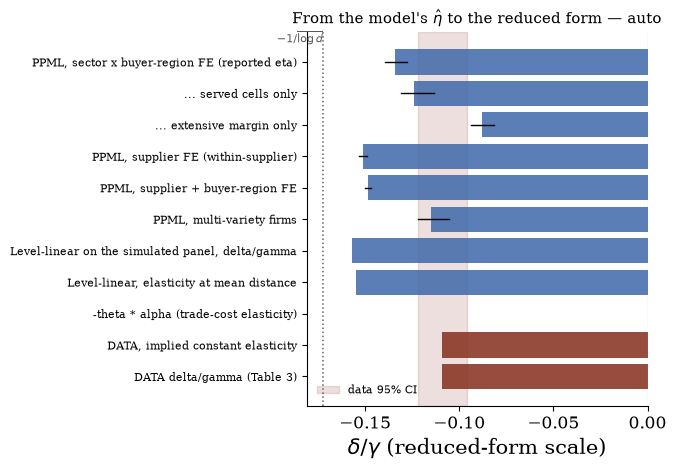

/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


[aero]  220,896 supplier x downstream-region cells, 12,272 suppliers, 41.1% zeros, from ../reporting_aero_profiled_aa_gran_nlo1_pso/step3/suppliers.parquet
  fixed effect                   eta       se    -> delta/gamma  (mean log d = 5.8)
  sector x buyer region      -0.7095   0.0686           -0.1387  [-0.1432, -0.1326]
  supplier (firm FE)         -1.3090   0.0526           -0.1523  [-0.1537, -0.1508]
  both                       -1.2189   0.0369           -0.1510  [-0.1521, -0.1499]
  DATA delta/gamma                                      -0.0980  [-0.1300, -0.0650]
                                           channel  coefficient       se  n_obs
                                       eta (total)    -0.709521 0.068574 220896
       eta_ext (extensive: probability of serving)    -0.325533 0.009455 220896
eta_int (intensive: portfolio share, served cells)    -0.459142 0.062758 130140
  eta - (eta_ext + eta_int) = +0.0752   (exactly zero only when the three fixed effects coincide)
[aero]

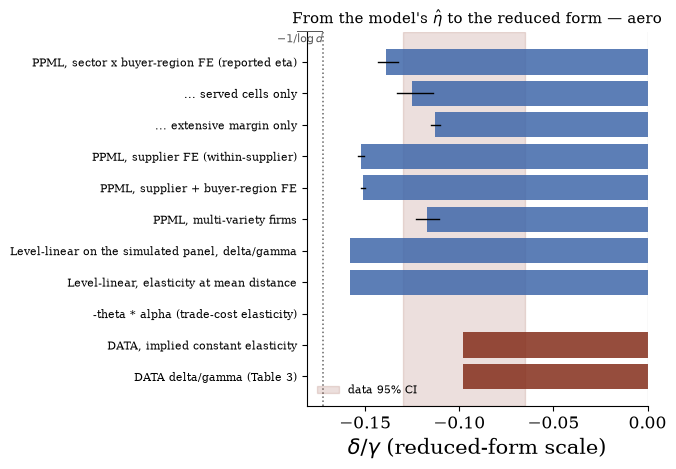

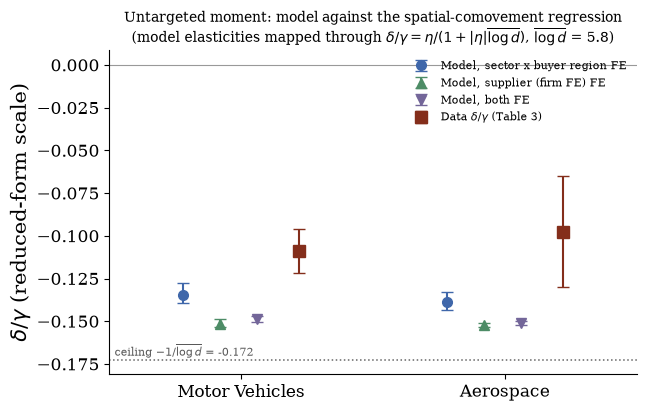

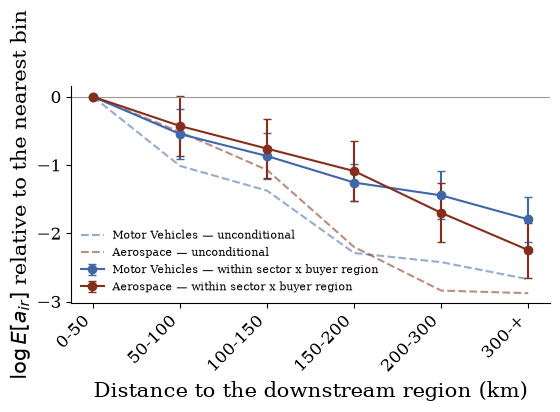

eta (model)        se  \
industry       fixed effect                                   
Motor Vehicles sector x buyer region    -0.609731  0.060517   
               supplier (firm FE)       -1.241356  0.074480   
               both                     -1.075678  0.045950   
Aerospace      sector x buyer region    -0.709521  0.068574   
               supplier (firm FE)       -1.308967  0.052625   
               both                     -1.218939  0.036949   

                                      delta/gamma (model)  \
industry       fixed effect                                 
Motor Vehicles sector x buyer region            -0.134407   
               supplier (firm FE)               -0.151387   
               both                             -0.148596   
Aerospace      sector x buyer region            -0.138708   
               supplier (firm FE)               -0.152347   
               both                             -0.151049   

                                     95% CI (model, delta/gamma)  \
industry       fixed effect                                        
Motor Vehicles sector x buyer region            [-0.139, -0.128]   
               supplier (firm FE)               [-0.153, -0.149]   
               both                             [-0.150, -0.147]   
Aerospace      sector x buyer region            [-0.143, -0.133]   
               supplier (firm FE)               [-0.154, -0.151]   
               both                             [-0.152, -0.150]   

                                      delta/gamma (data)     95% CI (data)  \
industry       fixed effect                                                  
Motor Vehicles sector x buyer region              -0.109  [-0.122, -0.096]   
               supplier (firm FE)                 -0.109  [-0.122, -0.096]   
               both                               -0.109  [-0.122, -0.096]   
Aerospace      sector x buyer region              -0.098  [-0.130, -0.065]   
               supplier (firm FE)                 -0.098  [-0.130, -0.065]   
               both                               -0.098  [-0.130, -0.065]   

                                      inside data CI  suppliers   cells  
industry       fixed effect                                              
Motor Vehicles sector x buyer region           False       4063   89386  
               supplier (firm FE)              False       4063   89386  
               both                            False       4063   89386  
Aerospace      sector x buyer region           False      12272  220896  
               supplier (firm FE)              False      12272  220896  
               both                            False      12272  220896

In [20]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
untargeted_results = []

for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    untargeted_results.append(estimate_untargeted_moment(data))
    decompose_untargeted_moment(data, panel=untargeted_results[-1]["panel"])

    # why the model's eta and the reduced-form delta/gamma differ, rung by rung
    ladder = untargeted_specification_ladder(data, panel=untargeted_results[-1]["panel"])
    plot_untargeted_ladder(ladder, industry,
                           save_to=f"{out_folder}/untargeted_ladder_{industry}_mu{MU}.pdf")
    plt.show()

plot_untargeted_moment(untargeted_results,
                       save_to=f"{out_folder}/untargeted_eta_mu{MU}.pdf")
plt.show()
plot_a_ir_profile(untargeted_results,
                  save_to=f"{out_folder}/untargeted_profile_mu{MU}.pdf")
plt.show()
display(untargeted_summary(untargeted_results))


# Comparative advantage against distance, within a sector

Inside a sector, competition for a given downstream buyer is between **cells**, and a
cell is a (sector, *region*) pair — not an attraction area. Comparative advantage is what
is constant within an area: every region of area $a$ shares $T_{as}$, but each has its own
distance to each buyer. With Fréchet productivity and wages normalised to one, the
Ricardian competition has a closed form over cells,

$$\rho_{l r s} = \frac{\psi_{l r s}}{\sum_{l'} \psi_{l' r s}}, \qquad
\psi_{l r s} = T_{a(l)s}\, d_{lr}^{-\theta\alpha},$$

so on a log scale the two forces are **additive and directly commensurable**:

$$\log \psi_{l r s} = \log T_{a(l)s} \;-\; \theta\alpha \log d_{lr}.$$

**The comparison is between two regions, not between two areas.** Region $r''$ beats
region $r'$ at buyer $r$ iff

$$\theta\alpha\big(\log d_{r'r} - \log d_{r''r}\big) \;<\; \log T_{a(r'')} - \log T_{a(r')},$$

with the distances measured *from each competing region* to the buyer and the comparative
advantages taken at the area each belongs to. Two things follow that an area-level reading
would miss:

1. when $a(r') = a(r'')$ the right-hand side is exactly zero, so **within an area
   competition is pure distance**. This is the variation that identifies $\alpha$, and it
   is invisible to any statement written in terms of area-level distances;
2. an area's edge does not protect *all* of its regions. It buys a distance handicap that
   each of its regions has to pay for out of its own location.

The section is written cell-by-cell throughout, so the only line that changes on the day
regions are allowed their own $T_{ls}$ deviating from their area's is the one that reads
$T_{a(l)s}$ off the area — nothing downstream assumes comparative advantage is constant
within an area.

**How the section proceeds.** Six tests, each in its own pair of cells (definitions, then
a run cell), building on one another:

| | question | answer |
|---|---|---|
| 1 | How unequal is comparative advantage inside a sector? | the spread of $\hat T$ across areas |
| 2 | What is that inequality worth in distance? | $\Delta \log \hat T / (\theta\hat\alpha)$, against the distances the geography offers |
| 3 | Does the favoured area actually win? | the exact comparison, buyer by buyer, region by region |
| 4 | Which of the two forces disperses the competition more? | the variance decomposition of $\log \psi$ |
| 5 | Is its covariance term telling us about the economy or about the estimator? | the Sinkhorn split of $\operatorname{Cov}(\log \hat T, \log d)$ |
| 6 | What would sourcing look like with one force switched off? | closed-form counterfactuals |

Test 1 is descriptive, 2 turns it into a distance, 3 replaces the average with the exact
statement, 4–5 ask which force does the work and whether the answer is contaminated by how
$\hat T$ was obtained, and 6 puts the two against each other in the allocation itself. A
seventh cell collects everything into one table, with a glossary.

Everything is computed from the estimated $\hat T$ and $\hat\alpha$ in `best_params`, the
distance matrix and $\theta$ — exact rather than Monte-Carlo, and available at either
`mu`. It assumes the $N_{\tau} = 1$ power law $\tau = d^{\alpha}$; under a binned trade
cost there is no single distance elasticity to trade off against $T$, and the functions
refuse to run rather than report the first bin's coefficient. Regional wages are
normalised to one in this calibration, which is why they do not appear in $\psi$.


In [21]:
# The geometry: the estimated T and alpha, and the closed-form win probabilities.
#
# Everything is computed CELL by CELL — a cell is a (sector, region) pair. Comparative
# advantage is read off the cell's attraction area, `T[s, aa_of_ze[l]]`, which is the one
# line to change the day regions are allowed a T of their own; distance is always the
# region's own distance to the buyer.

def model_theta(data):
    """Frechet shape parameter: from stats.csv when it carries one, else THETA_DEFAULT.

    Every theta*alpha-scaled quantity below — the distance equivalence, the variance
    decomposition, the win probabilities — moves with it.
    """
    v = _read_named_value(data["coefs"], "theta") if data.get("coefs") is not None else None
    return float(v) if v is not None and np.isfinite(v) and v > 0 else THETA_DEFAULT


def unpack_estimated_T(data):
    """
    The estimated comparative advantage, reference-normalised exactly as
    `unpack_params` does, plus alpha.

    `best_params` is the RAW theta vector, layout
        [Omega_L(1) | Omega_s(S) | A(R_d) | alpha(N_TAU) | T(active (s,AA), s-major)],
    where the T block carries EVERY active (sector, area) including each sector's
    reference — `unpack_params` divides the sector by its reference entry, which is
    what makes T_{ref,s} = 1 the gauge. The length is asserted against the rebuilt
    layout, so a flag mismatch is an error rather than a silently shifted vector.
    """
    bp = data.get("best_params")
    if bp is None:
        raise FileNotFoundError(
            f"no best_params in {data['folder']}/{data['step_dir']}/ — "
            "best_parameters_list.npy is written by run_reporting.")
    bp = np.asarray(bp, dtype=float).ravel()

    S, n_AA, n_tau = data["S"], data["n_AA"], data["n_tau"]
    AA_ACTIVE = data["AA_ACTIVE"]
    R_d = len(data["aa_names"])                       # one area per downstream region
    n_T = int(AA_ACTIVE.sum())
    expected = 1 + S + R_d + n_tau + n_T
    if bp.size != expected:
        raise ValueError(
            f"best_params has {bp.size} entries but the layout rebuilt here is "
            f"{expected} = 1 + {S} + {R_d} + {n_tau} + {n_T} — the run's flags and the "
            "ones passed here disagree.")

    alpha = bp[1 + S + R_d: 1 + S + R_d + n_tau]
    T = np.zeros((S, n_AA))
    T[AA_ACTIVE] = bp[1 + S + R_d + n_tau:]           # C-order on (S, n_AA) == s-major
    for s in range(S):
        ref = data["T_REF_AA"][s]
        if ref >= 0 and T[s, ref] > 0:
            T[s] = T[s] / T[s, ref]
    return {"T": T, "alpha": alpha, "theta": model_theta(data)}


def _downstream_ze_index(data):
    """The 1..R ZE index of each attraction area, in AA column order."""
    Nd = np.asarray(data["N_downstream"]).ravel()
    idx = np.flatnonzero(Nd != 0) + 1                 # 1-based, sorted — the model's order
    if idx.size != data["n_AA"]:
        raise ValueError(f"{idx.size} downstream regions in N_downstream_per_region.npy "
                         f"but {data['n_AA']} attraction areas.")
    return idx


def sourcing_geometry(data, alpha=None, equalise_T=False):
    """
    The exact Ricardian win probabilities `rho[s][l, r]` and the pieces they are built
    from, per sector, over CELLS l = regions.

    `alpha=0` switches the distance force off, `equalise_T=True` switches comparative
    advantage off — the two counterfactuals, both closed form.
    """
    est = unpack_estimated_T(data)
    if est["alpha"].size != 1:
        raise ValueError(
            f"N_TAU = {est['alpha'].size}: tau is binned, not the power law d^alpha, so "
            "there is no single distance elasticity to trade off against T. Re-run the "
            "reporting on an n_tau = 1 fit for this section.")
    a = float(est["alpha"][0]) if alpha is None else float(alpha)
    theta = est["theta"]

    D = np.load(data["input_folder"] / "distances.npy")[:data["R"], :data["R"]]
    down = _downstream_ze_index(data)
    aa_of_ze, CELL_MASK = data["aa_of_ze"], data["CELL_MASK"]

    out = {}
    for s in range(data["S"]):
        cells = np.flatnonzero(CELL_MASK[s])                       # 0-based ZE
        if cells.size == 0:
            continue
        # the ONE line that assumes comparative advantage is constant within an area
        T_cell = np.ones(cells.size) if equalise_T else est["T"][s, aa_of_ze[cells]]
        d = np.maximum(D[np.ix_(cells, down - 1)], 1.0)            # (n_cell, R_d)
        psi = T_cell[:, None] * d ** (-theta * a)
        tot = psi.sum(axis=0, keepdims=True)
        out[s] = {"cells": cells, "areas": aa_of_ze[cells], "T_cell": T_cell,
                  "distance": d, "log_psi": np.log(np.maximum(psi, 1e-300)),
                  "rho": np.divide(psi, tot, out=np.zeros_like(psi), where=tot > 0)}
    return {"by_sector": out, "alpha": a, "theta": theta, "T": est["T"],
            "alpha_hat": float(est["alpha"][0]), "downstream": down}


## Test 1 — how unequal is comparative advantage inside a sector?

The starting point, and purely descriptive: one dot per active attraction area, on a log
scale centred at the sector's median area, so the question "is there one area that stands
out, or is the sector flat?" is answered before anything is traded against distance. The
top area is marked and named.

Read the count of regions per area beside it: an area's edge is only as useful as the
locations that can exploit it, and the areas differ enormously in how many commuting zones
they contain. Note also that $\hat T$ is only identified up to a per-sector scale — the
reference area is normalised to one — so only *differences* within a sector mean anything,
which is why the figure is centred at the median.


In [22]:
# Test 1 — the within-sector spread of estimated comparative advantage.
# The helpers below are used by every test in the section.

def _sectors_in_code_order(data):
    """
    Sector display names in A129-CODE order.

    Every sector-indexed table and figure in this section is presented in this order, so
    the reader compares the same row across figures instead of re-reading a legend that
    has been resorted by whatever the figure happens to rank on.
    """
    return [n for _, n in sorted(zip(data["sector_names"], data["sector_names"]))]


def _by_sector_code(df, data, level=None):
    """Reindex a sector-indexed frame into A129-code order, dropping absent sectors."""
    order = [s for s in _sectors_in_code_order(data)
             if s in (df.index if level is None else df.index.get_level_values(level))]
    return df.reindex(order) if level is None else df.reindex(order, level=level)


def _buyer_weights(data):
    """Downstream buyers weighted by their purchases (the empirical pi_r target)."""
    w = np.asarray(data["emp_pi_r"], dtype=float).ravel()
    return w / w.sum()


def comparative_advantage_frame(data):
    """
    One row per (sector, active attraction area): the estimated T, its log deviation
    from the sector's median area, its rank, and how many REGIONS the area contributes
    to that sector's competition (the areas differ enormously in that count, and an
    area's edge is only as useful as the locations that can exploit it).
    """
    est = unpack_estimated_T(data)
    aa_of_ze, CELL_MASK, AA_ACTIVE = data["aa_of_ze"], data["CELL_MASK"], data["AA_ACTIVE"]
    aa_names = aa_display_names(data)          # commuting-zone NAMES, not ZE codes
    rows = []
    for s in range(data["S"]):
        act = np.flatnonzero(AA_ACTIVE[s])
        if act.size == 0:
            continue
        T = est["T"][s, act]
        med = np.median(np.log(np.maximum(T, 1e-300)))
        order = np.argsort(-T)
        rank = np.empty(act.size, dtype=int)
        rank[order] = np.arange(1, act.size + 1)
        for k, a in enumerate(act):
            rows.append({
                "sector": data["sector_names"][s],
                "area": aa_names[a],
                "area_code": data["aa_names"][a],
                "T": float(T[k]),
                "log_T_dev": float(np.log(max(T[k], 1e-300)) - med),
                "rank": int(rank[k]),
                "is_reference": bool(data["T_REF_AA"][s] == a),
                "n_cells": int(np.sum(CELL_MASK[s] & (aa_of_ze == a))),
            })
    return pd.DataFrame(rows)


def plot_ca_distribution(data, figsize=None, save_to=None):
    """
    The within-sector spread of estimated comparative advantage: one row per sector, one
    dot per active attraction area, on a log scale centred at the sector's median area.
    The top area is marked and named — a sector whose best area sits far to the right of
    the pack is one where comparative advantage, not geography, decides.
    """
    caf = comparative_advantage_frame(data)
    order = [s for s in _sectors_in_code_order(data) if s in set(caf["sector"])][::-1]

    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.95, hf=0.75))
    for y, sec in enumerate(order):
        sub = caf[caf["sector"] == sec]
        ax.scatter(sub["log_T_dev"], np.full(len(sub), y), s=22, color=sim_color,
                   alpha=0.65, zorder=2)
        top = sub.loc[sub["rank"].idxmin()]
        ax.scatter([top["log_T_dev"]], [y], s=60, marker="D", color=reference_color,
                   zorder=3)
        ax.annotate(str(top["area"]), (top["log_T_dev"], y), fontsize=8,
                    xytext=(6, 4), textcoords="offset points", color=reference_color)
    ax.margins(x=0.12)
    ax.axvline(0.0, color="0.6", linewidth=0.8)
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(order, fontsize=9)
    ax.set_xlabel(r"$\log \hat T_{as}$ relative to the sector's median area")
    ax.set_ylabel("Sector")
    ax.set_title(f"Comparative advantage within sector — {data['industry']}, "
                 rf"$\hat\mu_{data['mu']}$")
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


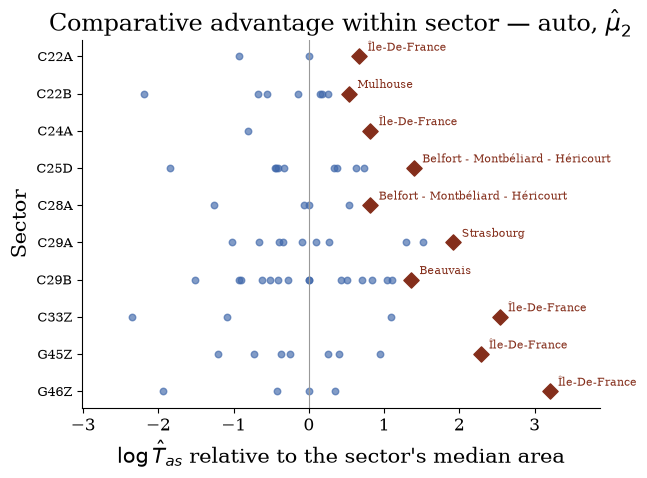

,sector,area,area_code,T,log_T_dev,rank,is_reference,n_cells
0,C22A,Île-De-France,1100,1.000000,0.669564,1,True,11
1,C22A,Le Mans,5213,0.511932,0.000000,2,False,11
2,C22A,Valence,8208,0.202532,-0.927291,3,False,34
3,C22B,Île-De-France,1100,1.000000,0.256419,2,True,14
4,C22B,Béthune - Bruay,3123,0.924269,0.177667,3,False,7
5,C22B,Mulhouse,4208,1.317867,0.532434,1,False,4
6,C22B,Vesoul,4309,0.671440,-0.141911,5,False,14
7,C22B,Angers,5205,0.393523,-0.676197,7,False,38
8,C22B,Rennes,5312,0.445355,-0.552463,6,False,18
9,C22B,Valence,8208,0.086368,-2.192714,8,False,64


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


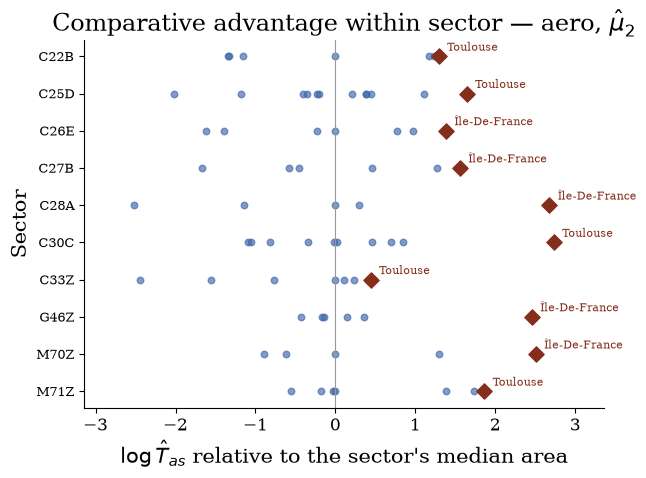

,sector,area,area_code,T,log_T_dev,rank,is_reference,n_cells
0,C22B,Roissy - Sud Picardie,0056,0.092669,-1.151230,5,False,50
1,C22B,Toulouse,0061,1.068441,1.293688,1,False,14
2,C22B,Île-De-France,1100,1.000000,1.227488,2,True,12
3,C22B,Cholet,5206,0.940325,1.165959,3,False,19
4,C22B,Châtellerault,5402,0.076625,-1.341343,7,False,8
5,C22B,Bordeaux,7204,0.293028,0.000000,4,False,8
6,C22B,Valence,8208,0.077018,-1.336230,6,False,32
7,C25D,Roissy - Sud Picardie,0056,0.025517,-2.024753,12,False,54
8,C25D,Toulouse,0061,1.000000,1.643669,1,True,18
9,C25D,Île-De-France,1100,0.283660,0.383688,5,False,12


In [23]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    plot_ca_distribution(
        data, save_to=f"{out_folder}/ca_distribution_{industry}_mu{MU}.pdf")
    plt.show()
    display(comparative_advantage_frame(data).head(12))


## Test 2 — what is that inequality worth in distance?

The two forces are commensurable on a log scale, so an edge in comparative advantage can be
quoted in kilometres. A gap of $\Delta$ in $\log T$ is offset by a distance ratio of
$\exp\!\big(\Delta/(\theta\alpha)\big)$: how many times further from a buyer a region of the
favoured area may sit than a competing region of the other area, and still win.

That number is only meaningful against the distances the geography actually offers, so it
is compared with two benchmarks, both computed on **cell-to-buyer** distances:

* `geo_log_spread` — the *typical* spread, p90 − p10 of $\log d$ across the regions
  competing for a given buyer, averaged over buyers with their purchase weights. Clearing
  it means the edge beats the distances a buyer ordinarily faces;
* `geo_log_range` — the *extreme* spread, pooled max − min. It is anchored at the
  own-region cell, so one degenerate observation sets it: clearing it means no location in
  the country offsets the edge and the area supplies every buyer.

Both benchmarks are averages of a distribution, which is what Test 3 then removes.


In [24]:
# Test 2 — the edge in distance units, against the distances the geography offers.

def ca_distance_equivalence(data):
    """
    How much distance a comparative-advantage gap is worth, against how much distance the
    country actually offers.

    `equiv_log_d = Delta log T / (theta*alpha)` is the log distance ratio that exactly
    offsets the gap between the top area and the median one — how much further from a
    buyer a REGION of the top area may sit than a competing REGION of the median area.
    It is compared with two benchmarks, both computed on cell-to-buyer distances:

      `geo_log_range`  the EXTREME spread, pooled max - min of log distance across all
                       competing cells and buyers. Anchored at the own-region cell, so
                       one degenerate observation sets it: it is the largest gap the
                       geography could ever offer;
      `geo_log_spread` the TYPICAL spread: p90 - p10 of log distance across the cells
                       competing for a given buyer, averaged over buyers with their
                       purchase weights.

    These two are averages over a distribution. `ca_win_margin` does the same comparison
    exactly, buyer by buyer, and is the one to quote; this table is the summary version.
    """
    geom = sourcing_geometry(data)
    ta = geom["theta"] * geom["alpha"]
    caf = comparative_advantage_frame(data)
    rows = []
    for s, blk in geom["by_sector"].items():
        name = data["sector_names"][s]
        sub = caf[caf["sector"] == name].sort_values("rank")
        if sub.empty:
            continue
        logT = np.log(np.maximum(sub["T"].to_numpy(), 1e-300))
        d_top_med = float(logT[0] - np.median(logT))
        d_top_2nd = float(logT[0] - logT[1]) if logT.size > 1 else np.nan
        ld = np.log(blk["distance"])
        geo_range = float(ld.max() - ld.min())
        per_buyer = np.percentile(ld, 90, axis=0) - np.percentile(ld, 10, axis=0)
        geo_spread = float(per_buyer @ _buyer_weights(data))
        equiv = d_top_med / ta if ta > 0 else np.inf
        rows.append({
            "sector": name, "top_area": sub["area"].iloc[0], "n_areas": len(sub),
            "dlogT_top_vs_median": d_top_med, "dlogT_top_vs_2nd": d_top_2nd,
            "equiv_log_d": equiv,
            "equiv_distance_ratio": float(np.exp(min(equiv, 700))),
            "geo_log_range": geo_range, "geo_log_spread": geo_spread,
            "CA_beats_any_geography": bool(equiv > geo_range),
            "CA_beats_typical_geography": bool(equiv > geo_spread),
        })
    df = _by_sector_code(pd.DataFrame(rows).set_index("sector"), data)
    df.attrs["theta_alpha"] = ta
    return df


def plot_ca_distance_equivalence(data, figsize=None, save_to=None):
    """
    What the top area's edge is worth in distance. For each sector the bar is
    `Delta log T / (theta*alpha)`, the log distance by which a region of the top area may
    be further from a buyer than a competing region of the median area; the markers are
    the log-distance spreads the geography actually offers between competing regions.
    """
    df = ca_distance_equivalence(data)[::-1]        # A129-code order, top to bottom
    y = np.arange(len(df))
    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.95, hf=0.7))
    decisive = df["CA_beats_typical_geography"].to_numpy()
    ax.barh(y, df["equiv_log_d"], color=[reference_color if d else sim_color
                                         for d in decisive], alpha=0.85,
            label=r"CA edge in log-distance units, $\Delta\log \hat T/(\theta\hat\alpha)$")
    ax.scatter(df["geo_log_range"], y, marker="|", s=260, color="black", zorder=3,
               label="extreme log-distance range between competing regions")
    ax.scatter(df["geo_log_spread"], y, marker="|", s=140, color="0.55", zorder=3,
               label="typical spread a buyer faces (p90 - p10 across regions)")
    ax.set_yticks(y)
    ax.set_yticklabels(df.index, fontsize=9)
    ax.set_xlabel("log distance ratio")
    ax.set_title(f"What the comparative-advantage edge is worth in distance — "
                 f"{data['industry']}, " rf"$\hat\mu_{data['mu']}$"
                 f"\n" rf"$\theta\hat\alpha$ = {df.attrs['theta_alpha']:.3f}"
                 "   (red: beats the spread a buyer typically faces)", fontsize=11)
    ax.legend(frameon=False, fontsize=8, loc="upper center",
              bbox_to_anchor=(0.5, -0.18))
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


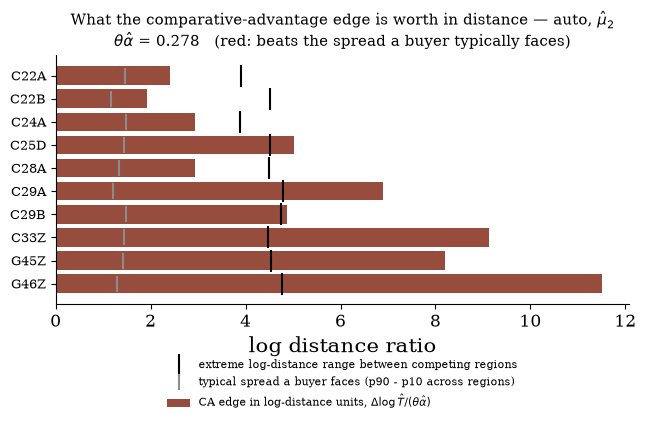

,top_area,n_areas,dlogT_top_vs_median,dlogT_top_vs_2nd,equiv_log_d,equiv_distance_ratio,geo_log_range,geo_log_spread,CA_beats_any_geography,CA_beats_typical_geography
sector,,,,,,,,,,
C22A,Île-De-France,3,0.669564,0.669564,2.408932,11.122073,3.912685,1.469250,False,True
C22B,Mulhouse,8,0.532434,0.276015,1.915569,6.790802,4.511363,1.171179,False,True
C24A,Île-De-France,2,0.816776,1.633552,2.938563,18.888684,3.883860,1.485341,False,True
C25D,Belfort - Montbéliard - Héricourt,10,1.394854,0.667277,5.018348,151.161442,4.517761,1.439095,True,True
C28A,Belfort - Montbéliard - Héricourt,5,0.816543,0.289322,2.937725,18.872854,4.491595,1.337832,False,True
C29A,Strasbourg,10,1.919272,0.405358,6.905078,997.326061,4.787456,1.217123,True,True
C29B,Beauvais,16,1.356553,0.250539,4.880553,131.703440,4.746346,1.479800,True,True
C33Z,Île-De-France,4,2.534162,1.445052,9.117304,9111.605197,4.471138,1.432118,True,True
G45Z,Île-De-France,8,2.280790,1.332095,8.205734,3661.886278,4.536379,1.407663,True,True


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


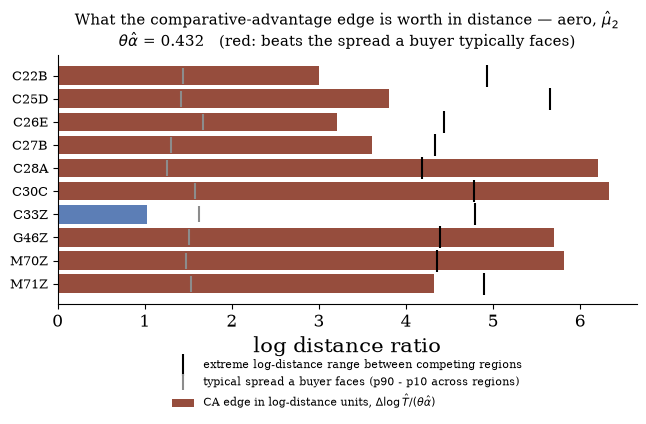

,top_area,n_areas,dlogT_top_vs_median,dlogT_top_vs_2nd,equiv_log_d,equiv_distance_ratio,geo_log_range,geo_log_spread,CA_beats_any_geography,CA_beats_typical_geography
sector,,,,,,,,,,
C22B,Toulouse,7,1.293688,0.066200,2.997697,20.039327,4.925035,1.435774,False,True
C25D,Toulouse,12,1.643669,0.533574,3.808662,45.090078,5.647328,1.413060,False,True
C26E,Île-De-France,7,1.383665,0.415088,3.206189,24.684822,4.434990,1.663617,False,True
C27B,Île-De-France,6,1.557577,0.284472,3.609172,36.935472,4.326218,1.299195,False,True
C28A,Île-De-France,5,2.676533,2.387565,6.201985,493.727919,4.182868,1.250889,True,True
C30C,Toulouse,10,2.732425,1.885283,6.331496,561.996473,4.778641,1.572740,True,True
C33Z,Toulouse,7,0.442669,0.212886,1.025739,2.789157,4.788015,1.623199,False,False
G46Z,Île-De-France,6,2.457223,2.104688,5.693805,297.021776,4.394953,1.504883,True,True
M70Z,Île-De-France,5,2.506660,1.211645,5.808359,333.072170,4.349354,1.478601,True,True


In [25]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    plot_ca_distance_equivalence(
        data, save_to=f"{out_folder}/ca_distance_equivalence_{industry}_mu{MU}.pdf")
    plt.show()
    display(ca_distance_equivalence(data))


## Test 3 — does the favoured area actually win?

Test 2 compares an average edge with an average spread. Neither average has to hold for any
particular buyer, so here the comparison is made exactly, **buyer by buyer and region by
region**, which is the form the inequality at the top of the section takes.

For each sector let $A^*$ be the area with the highest $\hat T$. For each downstream buyer
$r$, every competing cell $l$ carries a score $\log \psi_{lr} = \log T_{a(l)} - \theta\alpha
\log d_{lr}$, and $A^*$ takes the buyer iff its best cell outscores the best cell outside
it. Two numbers come out, both in log-distance units:

* **`mean_win_margin`** — $\big[\max_{l \in A^*} \log\psi - \max_{l \notin A^*}
  \log\psi\big]/(\theta\alpha)$: how much further from this buyer the favoured area's best
  region could be and still win. Positive means it wins; `share_buyers_won` is the
  purchase-weighted share of buyers it takes;
* **`mean_within_penalty`** — $\log d$ of the worst region of $A^*$ minus that of its best,
  for the same buyer. Inside an area $T$ cancels exactly, so this comparison is **pure
  geography**: it is the handicap the area's own spread imposes on its worst region, and it
  is the variation that identifies $\alpha$.

Putting the two side by side answers a question the area-level statement cannot even pose:
does it matter more *which area* a supplier belongs to, or *which region of it* it sits in?
When the second bar is longer than the first, the answer is the region — and that is
exactly the case in which letting regions deviate from their area's $T$ would change the
picture most.


In [26]:
# Test 3 — the exact comparison, buyer by buyer and region by region.

def ca_win_margin(data):
    """
    The decisive test, buyer by buyer and REGION by region — no averaging of distances.

    For each sector, let A* be the area with the highest T. For each downstream buyer r,
    every competing cell l has score

        log psi_lr = log T_{a(l)} - theta*alpha*log d_{lr},

    so A* takes the buyer iff its best cell outscores the best cell OUTSIDE it. Two
    numbers come out of that comparison, both in LOG-DISTANCE units (divide by
    theta*alpha), which is what makes them readable:

      win_margin_r  = [max_{l in A*} score - max_{l not in A*} score] / (theta*alpha)
                      how much FURTHER the favoured area's best region could be from
                      this buyer and still win. Positive = it wins.
      within_penalty_r = log d(worst cell of A*) - log d(best cell of A*)
                      the handicap A*'s own geography imposes on its worst region. Inside
                      an area T cancels exactly, so this comparison is PURE DISTANCE —
                      it is the variation that identifies alpha, and it is invisible to
                      any statement written in terms of area-level distances.

    Both are averaged over buyers with their purchase weights. `share_buyers_won` is the
    purchase-weighted share of buyers the favoured area actually takes; comparing
    `mean_win_margin` with `mean_within_penalty` says whether belonging to the right area
    or sitting in the right region of it matters more.
    """
    geom = sourcing_geometry(data)
    ta, w = geom["theta"] * geom["alpha"], _buyer_weights(data)
    est_T = geom["T"]
    rows = []
    for s, blk in geom["by_sector"].items():
        act = np.flatnonzero(data["AA_ACTIVE"][s])
        if act.size == 0:
            continue
        top_area = int(act[np.argmax(est_T[s, act])])
        in_top = blk["areas"] == top_area
        if not in_top.any() or in_top.all():
            continue                       # no cross-area comparison to make
        score = blk["log_psi"]                                   # (n_cell, R_d)
        ld = np.log(blk["distance"])
        best_top = score[in_top].max(axis=0)
        best_out = score[~in_top].max(axis=0)
        margin = (best_top - best_out) / ta if ta > 0 else np.full_like(best_top, np.inf)
        penalty = ld[in_top].max(axis=0) - ld[in_top].min(axis=0)
        rows.append({
            "sector": data["sector_names"][s],
            "top_area": aa_display_names(data)[top_area],
            "n_cells_top_area": int(in_top.sum()),
            "share_buyers_won": float((margin > 0) @ w),
            "mean_win_margin": float(margin @ w),
            "min_win_margin": float(margin.min()),
            "mean_within_penalty": float(penalty @ w),
            "area_beats_own_geography": bool(float(margin @ w) > float(penalty @ w)),
        })
    df = pd.DataFrame(rows)
    return _by_sector_code(df.set_index("sector"), data) if len(df) else df


def plot_ca_win_margin(data, figsize=None, save_to=None):
    """
    The exact test, per sector: how much further the top area's best region could be from
    the average buyer and still win (bar), against the distance handicap that area's own
    geography already imposes on its worst region (marker). Both in log-distance units,
    so they are directly comparable — a bar shorter than its marker is a sector where
    WHICH REGION of the favoured area a supplier sits in matters more than the area's
    edge itself.
    """
    df = ca_win_margin(data)
    if not len(df):
        raise ValueError("no sector has cells both inside and outside its top area — "
                         "there is no cross-area comparison to draw.")
    df = df[::-1]
    y = np.arange(len(df))
    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.95, hf=0.7))
    ax.barh(y, df["mean_win_margin"],
            color=[reference_color if v else sim_color
                   for v in df["area_beats_own_geography"]], alpha=0.85,
            label="win margin of the top area (log distance it could give away)")
    ax.scatter(df["mean_within_penalty"], y, marker="|", s=220, color="black", zorder=3,
               label="within-area distance handicap (best to worst region of that area)")
    ax.axvline(0.0, color="0.6", linewidth=0.8)
    for i, (_, r) in enumerate(df.iterrows()):
        ax.annotate(f"{100 * r['share_buyers_won']:.0f}% of buyers",
                    (max(r["mean_win_margin"], 0.0), i), fontsize=8,
                    xytext=(4, -3), textcoords="offset points")
    ax.set_yticks(y)
    ax.set_yticklabels(df.index, fontsize=9)
    ax.set_xlabel("log distance")
    ax.set_title(f"Does the favoured area actually win? — {data['industry']}, "
                 rf"$\hat\mu_{data['mu']}$", fontsize=11)
    ax.legend(frameon=False, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.18))
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


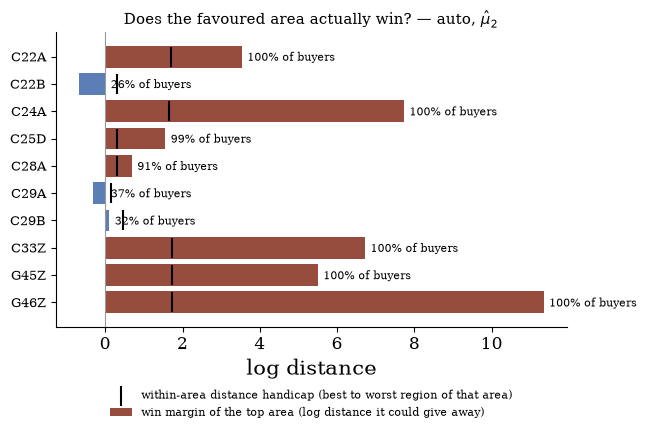

,top_area,n_cells_top_area,share_buyers_won,mean_win_margin,min_win_margin,mean_within_penalty,area_beats_own_geography
sector,,,,,,,
C22A,Île-De-France,11,1.000000,3.533481,1.235065,1.710031,True
C22B,Mulhouse,4,0.257500,-0.679747,-2.117866,0.306439,False
C24A,Île-De-France,7,1.000000,7.729541,4.296667,1.642317,True
C25D,Belfort - Montbéliard - Héricourt,3,0.987616,1.551357,-0.429470,0.296740,True
C28A,Belfort - Montbéliard - Héricourt,3,0.911744,0.686759,-1.806324,0.296740,True
C29A,Strasbourg,4,0.369191,-0.322976,-1.617751,0.150576,False
C29B,Beauvais,3,0.324350,0.102560,-1.957752,0.466361,False
C33Z,Île-De-France,14,1.000000,6.721950,2.113806,1.722662,True
G45Z,Île-De-France,14,1.000000,5.500066,3.663071,1.722662,True


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


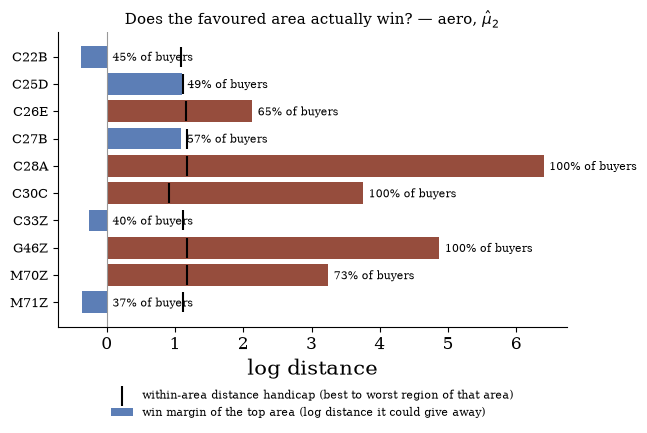

,top_area,n_cells_top_area,share_buyers_won,mean_win_margin,min_win_margin,mean_within_penalty,area_beats_own_geography
sector,,,,,,,
C22B,Toulouse,14,0.450328,-0.380309,-3.159196,1.093616,False
C25D,Toulouse,18,0.493404,1.097059,-0.725026,1.111834,False
C26E,Île-De-France,9,0.653828,2.129579,-2.463901,1.167285,True
C27B,Île-De-France,11,0.567604,1.091947,-3.049820,1.179510,False
C28A,Île-De-France,11,1.000000,6.400763,3.014401,1.175907,True
C30C,Toulouse,6,1.000000,3.755521,1.086955,0.917569,True
C33Z,Toulouse,21,0.395143,-0.267325,-2.494273,1.111834,False
G46Z,Île-De-France,12,1.000000,4.872720,1.657191,1.179510,True
M70Z,Île-De-France,12,0.727581,3.243342,-0.901402,1.179510,True


In [27]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    plot_ca_win_margin(
        data, save_to=f"{out_folder}/ca_win_margin_{industry}_mu{MU}.pdf")
    plt.show()
    display(ca_win_margin(data))


## Test 4 — which force disperses the competition more?

Tests 2 and 3 ask who wins. This one asks which force is doing the work, and it is an
identity rather than a regression. Because $\log\psi$ is a sum, its dispersion across the
cells competing for a given buyer splits *exactly*:

$$\operatorname{Var}(\log\psi) = \operatorname{Var}(\log T) + (\theta\alpha)^2\operatorname{Var}(\log d) - 2\theta\alpha\operatorname{Cov}(\log T, \log d).$$

Variances are taken **across cells at a fixed buyer** — the competition the model actually
runs — and then averaged over buyers with their purchase weights.
$\operatorname{sd}(\log T)$ against $\theta\alpha\operatorname{sd}(\log d)$ is the
like-for-like size of the two pulls, and `ratio_CA_over_distance` above one says
comparative advantage disperses the competition more than geography does.

The three shares sum to one by construction. The covariance share is the interesting one
and the one not to over-read — which is what Test 5 is for.


In [28]:
# Test 4 — the exact variance decomposition of log psi across competing cells.

def ca_variance_decomposition(data):
    """
    The exact split of the dispersion of log psi across competing cells.

    For a given buyer r, log psi_{l,r} = log T_l - theta*alpha*log d_{l,r}, so

        Var_l(log psi) = Var_l(log T) + (theta*alpha)^2 Var_l(log d)
                         - 2*theta*alpha*Cov_l(log T, log d)

    holds with no approximation. Variances are taken ACROSS CELLS at a fixed buyer —
    which is the competition the model actually runs — then averaged over buyers with
    their purchase weights. `sd_logT` against `sd_dist` is the like-for-like size of the
    two forces.

    The covariance term is NOT free of the estimator: T is the Sinkhorn image of the
    observed sourcing shares, which loads onto comparative advantage whatever distance
    takes away, so a positive Cov(log T, log d) — hence a negative contribution
    `share_covariance` — is the expected reading. `ca_covariance_benchmark` splits it.
    """
    geom = sourcing_geometry(data)
    ta, w = geom["theta"] * geom["alpha"], _buyer_weights(data)
    rows = []
    for s, blk in geom["by_sector"].items():
        if blk["cells"].size < 2:
            continue
        logT = np.log(np.maximum(blk["T_cell"], 1e-300))
        ld = np.log(blk["distance"])                       # (n_cell, R_d)
        v_T = float(np.var(logT))
        v_d = np.var(ld, axis=0)                           # per buyer
        cov = np.array([np.cov(logT, ld[:, r], bias=True)[0, 1] for r in range(ld.shape[1])])
        v_psi = v_T + (ta ** 2) * v_d - 2 * ta * cov
        vd_bar, cov_bar, vpsi_bar = float(v_d @ w), float(cov @ w), float(v_psi @ w)
        rows.append({
            "sector": data["sector_names"][s],
            "sd_logT": np.sqrt(v_T),
            "sd_dist": ta * np.sqrt(vd_bar),
            "ratio_CA_over_distance": np.sqrt(v_T) / (ta * np.sqrt(vd_bar))
            if vd_bar > 0 else np.inf,
            "share_CA": v_T / vpsi_bar if vpsi_bar > 0 else np.nan,
            "share_distance": (ta ** 2) * vd_bar / vpsi_bar if vpsi_bar > 0 else np.nan,
            "share_covariance": -2 * ta * cov_bar / vpsi_bar if vpsi_bar > 0 else np.nan,
            "sd_log_psi": np.sqrt(vpsi_bar),
        })
    return _by_sector_code(pd.DataFrame(rows).set_index("sector"), data)


In [29]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    display(ca_variance_decomposition(data))


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


,sd_logT,sd_dist,ratio_CA_over_distance,share_CA,share_distance,share_covariance,sd_log_psi
sector,,,,,,,
C22A,0.651117,0.187161,3.478907,0.654327,0.054064,0.291609,0.804936
C22B,0.989212,0.153835,6.430335,0.840900,0.020337,0.138763,1.078741
C24A,0.724578,0.209435,3.459688,0.653967,0.054636,0.291397,0.895999
C25D,1.072871,0.173981,6.166588,0.827224,0.021754,0.151022,1.179603
C28A,0.678108,0.168934,4.014029,0.758435,0.047071,0.194494,0.778645
C29A,0.671285,0.159544,4.207523,0.809645,0.045734,0.144621,0.746036
C29B,0.752363,0.180851,4.160128,0.771753,0.044593,0.183654,0.856423
C33Z,1.903463,0.172222,11.052353,0.894879,0.007326,0.097796,2.012160
G45Z,0.873049,0.167171,5.222479,0.928774,0.034053,0.037173,0.905907


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


,sd_logT,sd_dist,ratio_CA_over_distance,share_CA,share_distance,share_covariance,sd_log_psi
sector,,,,,,,
C22B,1.131751,0.267509,4.230708,0.875730,0.048927,0.075343,1.209388
C25D,1.117381,0.255400,4.375030,0.895422,0.046781,0.057798,1.180830
C26E,1.185891,0.313521,3.782497,0.810434,0.056645,0.132922,1.317305
C27B,1.070177,0.252659,4.235665,0.864035,0.048160,0.087805,1.151304
C28A,1.641805,0.237351,6.917201,0.928603,0.019407,0.051989,1.703752
C30C,1.268300,0.319381,3.971114,0.868606,0.055081,0.076314,1.360851
C33Z,0.972447,0.298628,3.256378,0.888707,0.083809,0.027485,1.031541
G46Z,0.753461,0.276120,2.728744,0.779187,0.104644,0.116169,0.853571
M70Z,1.181724,0.273073,4.327502,0.837521,0.044722,0.117757,1.291273


## Test 5 — is the covariance term about the economy or about the estimator?

Under `--profile_T=true`, $\hat T$ is not a free estimate: it is the Sinkhorn image that
makes the model reproduce the *observed* sourcing shares at the current $\alpha$. At the
area level,

$$\log \hat T_{as} \;=\; \log \hat\gamma^{\,emp}_{as} \;-\; \log M_{as}(\alpha) + \text{const},
\qquad M_{as}(\alpha) = \sum_r \omega_r\, d_{ar}^{-\theta\alpha}/\Phi_{sr},$$

with $M$ the market-access term. $M$ falls with distance to markets, so a remote area that
nonetheless sells must be handed a **higher** $T$: the inversion loads onto comparative
advantage exactly what distance takes away. Hence, cell by cell,

$$\operatorname{Cov}(\log \hat T, \log d) \;=\; \underbrace{\operatorname{Cov}(\log \hat\gamma^{\,emp}, \log d)}_{\text{the gradient in the data}} \;-\; \underbrace{\operatorname{Cov}(\log M, \log d)}_{<\,0,\ \text{growing in } \alpha},$$

so the expected sign of $\operatorname{Cov}(\log \hat T, \log d)$ is **positive** unless the
observed sourcing shares fall with distance fast enough to outweigh the correction — and a
positive covariance makes Test 4's `share_covariance` **negative**: the two forces offset,
and $\operatorname{Var}(\log\psi)$ is smaller than the sum of the two separate variances.
That is the inversion's signature, not a finding about the economy, and reading Test 4
without it invites calling comparative advantage "large" when what is large is the
compensation for remoteness.

`ca_covariance_benchmark` reports the two terms separately, taking
$\log M = \log\hat\gamma^{emp} - \log\hat T$ as the residual (exact up to the per-sector
constant, which a covariance drops), so which one drives the total is a number. At
$\alpha = 0$ the market-access term is common within a sector and must vanish, leaving
$\operatorname{Cov}(\log\hat T, \log d) = \operatorname{Cov}(\log\hat\gamma, \log d)$ — the
limiting case to check the split against.


In [30]:
# Test 5 — where the covariance term comes from, given how T was obtained.

def ca_covariance_benchmark(data):
    """
    Where the covariance term of the decomposition comes from — the data, or the
    inversion.

    Under profiling, T is chosen so the model reproduces the observed sourcing shares:
    at the area level, log T_a = log gamma^emp_a - log M_a(alpha) + const, with M the
    market-access term. Hence, cell by cell,

        Cov(log T, log d) = Cov(log gamma^emp, log d) - Cov(log M, log d),

    and since M falls with distance to markets the second term is negative, i.e. the
    inversion MECHANICALLY pushes Cov(log T, log d) up: a remote area that nonetheless
    sells must be handed a higher T. This function reports the two pieces, taking
    log M = log gamma^emp - log T as the residual (exact up to the per-sector constant,
    which drops out of a covariance). Read `cov_gamma` as the gradient in the data and
    `-cov_M` as what the inversion added on top of it.

    At alpha = 0 the market-access term is common within a sector and `cov_M` must
    vanish, leaving `cov_T == cov_gamma` — the limiting case to check the split against.
    """
    geom = sourcing_geometry(data)
    ta, w = geom["theta"] * geom["alpha"], _buyer_weights(data)
    emp_gamma_aa, aa_of_ze = data["emp_gamma_aa"], data["aa_of_ze"]
    rows = []
    for s, blk in geom["by_sector"].items():
        cells, areas = blk["cells"], blk["areas"]
        g = emp_gamma_aa[s, areas]
        keep = (g > 0) & (blk["T_cell"] > 0)
        if keep.sum() < 2:
            continue
        logT = np.log(blk["T_cell"][keep])
        logG = np.log(g[keep])
        logM = logG - logT                                  # the market-access residual
        ld = np.log(blk["distance"][keep])
        def _cov(x):
            return float(np.array([np.cov(x, ld[:, r], bias=True)[0, 1]
                                   for r in range(ld.shape[1])]) @ w)
        cov_T, cov_G, cov_M = _cov(logT), _cov(logG), _cov(logM)
        sd_ld = float(np.sqrt(np.array([np.var(ld[:, r]) for r in range(ld.shape[1])]) @ w))
        rows.append({
            "sector": data["sector_names"][s],
            "cov_T": cov_T, "cov_gamma": cov_G, "cov_M": cov_M,
            "check_gamma_minus_M": cov_G - cov_M - cov_T,      # 0 by construction
            "corr_T_d": cov_T / (np.std(logT) * sd_ld) if sd_ld > 0 and np.std(logT) > 0 else np.nan,
            "corr_gamma_d": cov_G / (np.std(logG) * sd_ld) if sd_ld > 0 and np.std(logG) > 0 else np.nan,
            "share_covariance": np.nan,
        })
    df = pd.DataFrame(rows).set_index("sector")
    vd = ca_variance_decomposition(data)
    df["share_covariance"] = vd["share_covariance"].reindex(df.index)
    df.attrs["theta_alpha"] = ta
    return _by_sector_code(df, data)


In [31]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    display(ca_covariance_benchmark(data))


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


,cov_T,cov_gamma,cov_M,check_gamma_minus_M,corr_T_d,corr_gamma_d,share_covariance
sector,,,,,,,
C22A,-0.339880,-0.139728,0.200152,-1.665335e-16,-0.775208,-0.639151,0.291609
C22B,-0.290476,-0.114705,0.175771,0.000000e+00,-0.530558,-0.407379,0.138763
C24A,-0.420826,-0.257490,0.163336,-5.551115e-17,-0.770791,-0.770791,0.291397
C25D,-0.378020,-0.033322,0.344697,0.000000e+00,-0.562901,-0.091070,0.151022
C28A,-0.212122,0.010301,0.222424,0.000000e+00,-0.514680,0.078545,0.194494
C29A,-0.144795,0.074924,0.219719,2.775558e-17,-0.375779,0.169637,0.144621
C29B,-0.242314,0.000481,0.242795,-8.326673e-17,-0.494993,0.001035,0.183654
C33Z,-0.712273,-0.569577,0.142696,-4.440892e-16,-0.603921,-0.582962,0.097796
G45Z,-0.054878,0.258437,0.313315,-6.938894e-17,-0.104511,0.331058,0.037173


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


,cov_T,cov_gamma,cov_M,check_gamma_minus_M,corr_T_d,corr_gamma_d,share_covariance
sector,,,,,,,
C22B,-0.127674,-0.066226,0.061448,-8.326673e-17,-0.181993,-0.115192,0.075343
C25D,-0.093371,-0.042733,0.050638,-8.326673e-17,-0.141199,-0.085350,0.057798
C26E,-0.267237,-0.263884,0.003352,5.551115e-17,-0.310189,-0.327946,0.132922
C27B,-0.134842,-0.092699,0.042143,-1.110223e-16,-0.215217,-0.150156,0.087805
C28A,-0.174845,-0.121355,0.053490,2.775558e-17,-0.193634,-0.167895,0.051989
C30C,-0.163739,-0.176851,-0.013112,0.000000e+00,-0.174447,-0.190413,0.076314
C33Z,-0.033884,0.002358,0.036242,3.469447e-17,-0.050354,0.003101,0.027485
G46Z,-0.098061,-0.045714,0.052347,4.163336e-17,-0.203414,-0.103989,0.116169
M70Z,-0.227483,-0.182016,0.045467,2.775558e-16,-0.304226,-0.259687,0.117757


## Test 6 — what would sourcing look like with one force switched off?

The win probabilities are closed form, so the allocation can be recomputed with either
force removed — no re-simulation, no re-estimation. Four regimes: both forces, distance
only ($T$ equalised within the sector), comparative advantage only ($\alpha = 0$), and
neither, which is the uniform $1/n$ benchmark every cell equally likely.

Read as a decomposition: the move from *Neither* to *Distance only* is what geography alone
does to the concentration and reach of sourcing, and the move to *Comparative advantage
only* is what $T$ alone does. Four statistics per sector and regime, all averaged over
buyers with their purchase weights: the share of the single best cell, the HHI, the mean
sourcing distance, and the sourcing share of the sector's highest-$T$ area.


In [32]:
# Test 6 — the allocation of winners with one force switched off.

CF_REGIMES = {"Both forces": dict(),
              "Distance only": dict(equalise_T=True),
              "Comparative advantage only": dict(alpha=0.0),
              "Neither": dict(equalise_T=True, alpha=0.0)}


def counterfactual_sourcing(data, regimes=CF_REGIMES):
    """
    The allocation of winners with each force switched off, from the closed-form win
    probabilities — no re-simulation.

    Per sector and regime, averaged over buyers with their purchase weights:
      top_cell_share : max_l rho_{l,r}, how concentrated sourcing is on one cell,
      hhi            : sum_l rho^2,
      mean_distance  : sum_l rho_{l,r} d_{l,r}, how far sourcing actually reaches,
      top_area_share : the sourcing share of the sector's highest-T area.

    "Neither" is the uniform benchmark: every cell equally likely. Reading the table as a
    decomposition, the move from "Neither" to "Distance only" is what geography alone
    does, and to "Comparative advantage only" what T alone does.
    """
    w = _buyer_weights(data)
    est = unpack_estimated_T(data)
    rows = []
    for label, kw in regimes.items():
        geom = sourcing_geometry(data, **kw)
        for s, blk in geom["by_sector"].items():
            rho, d = blk["rho"], blk["distance"]
            top_area = int(np.argmax(est["T"][s] * data["AA_ACTIVE"][s]))
            in_top = blk["areas"] == top_area
            rows.append({
                "sector": data["sector_names"][s], "regime": label,
                "top_cell_share": float((rho.max(axis=0)) @ w),
                "hhi": float((rho ** 2).sum(axis=0) @ w),
                "mean_distance": float((rho * d).sum(axis=0) @ w),
                "top_area_share": float(rho[in_top].sum(axis=0) @ w) if in_top.any() else np.nan,
                "n_cells": int(blk["cells"].size),
            })
    df = pd.DataFrame(rows)
    df["regime"] = pd.Categorical(df["regime"], categories=list(regimes), ordered=True)
    df["sector"] = pd.Categorical(df["sector"], categories=_sectors_in_code_order(data),
                                  ordered=True)
    return df.set_index(["sector", "regime"]).sort_index()


def plot_counterfactual_sourcing(data, figsize=None, save_to=None):
    """
    What each force does to the allocation of winners, from the closed-form win
    probabilities: the mean distance sourcing reaches, and how concentrated it is on the
    single best cell, under both forces and with each switched off.
    """
    cf = counterfactual_sourcing(data).reset_index()
    sectors = [s for s in _sectors_in_code_order(data) if s in set(cf["sector"])]
    regimes = list(CF_REGIMES)
    palette = [sim_color, (0.45, 0.6, 0.45), reference_color, "0.7"]

    fig, axes = plt.subplots(1, 2, figsize=figsize or get_figsize(wf=1.0, hf=0.5))
    x = np.arange(len(sectors))
    width = 0.8 / len(regimes)
    for k, (reg, col) in enumerate(zip(regimes, palette)):
        sub = cf[cf["regime"] == reg].set_index("sector").reindex(sectors)
        off = (k - (len(regimes) - 1) / 2) * width
        axes[0].bar(x + off, sub["mean_distance"], width, color=col, label=reg)
        axes[1].bar(x + off, sub["top_cell_share"], width, color=col, label=reg)

    for ax, lab in zip(axes, ["Mean sourcing distance (km)",
                              "Sourcing share of the single best cell"]):
        ax.set_xticks(x)
        ax.set_xticklabels(sectors, rotation=45, ha="right", fontsize=8)
        ax.set_ylabel(lab, fontsize=10)
        _despine(ax)
    axes[0].legend(frameon=False, fontsize=8)
    fig.suptitle(f"Winners with one force switched off — {data['industry']}, "
                 rf"$\hat\mu_{data['mu']}$", fontsize=12)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return axes


# What every column of `comparative_advantage_summary` means. Printed by
# `display(comparative_advantage_glossary())` next to the table itself, so the table can
# be read without coming back to the source.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


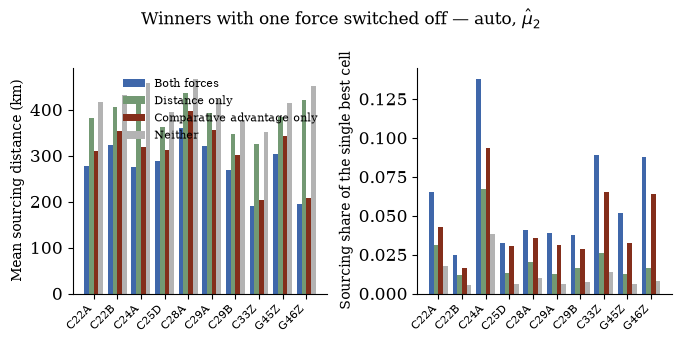

top_cell_share    hhi  mean_distance  \
sector regime                                                             
C22A   Both forces                          0.065  0.033        277.792   
       Distance only                        0.031  0.019        380.943   
       Comparative advantage only           0.043  0.028        309.536   
       Neither                              0.018  0.018        416.564   
C22B   Both forces                          0.025  0.010        324.151   
       Distance only                        0.012  0.006        404.856   
       Comparative advantage only           0.017  0.009        353.265   
       Neither                              0.006  0.006        431.472   
C24A   Both forces                          0.138  0.084        275.931   
       Distance only                        0.067  0.041        415.772   
       Comparative advantage only           0.093  0.067        318.478   
       Neither                              0.038  0.038        458.450   
C25D   Both forces                          0.032  0.012        287.534   
       Distance only                        0.013  0.006        362.874   
       Comparative advantage only           0.030  0.012        311.590   
       Neither                              0.006  0.006        394.429   
C28A   Both forces                          0.041  0.018        360.273   
       Distance only                        0.020  0.010        435.673   
       Comparative advantage only           0.036  0.016        397.527   
       Neither                              0.010  0.010        467.336   
C29A   Both forces                          0.039  0.015        321.387   
       Distance only                        0.013  0.006        393.407   
       Comparative advantage only           0.031  0.013        355.215   
       Neither                              0.006  0.006        421.453   
C29B   Both forces                          0.038  0.016        269.460   
       Distance only                        0.016  0.008        346.037   
       Comparative advantage only           0.029  0.013        301.215   
       Neither                              0.007  0.007        378.230   
C33Z   Both forces                          0.089  0.063        189.837   
       Distance only                        0.026  0.014        324.546   
       Comparative advantage only           0.065  0.060        202.384   
       Neither                              0.014  0.014        350.954   
G45Z   Both forces                          0.052  0.023        302.525   
       Distance only                        0.013  0.006        383.493   
       Comparative advantage only           0.033  0.017        342.800   
       Neither                              0.006  0.006        413.825   
G46Z   Both forces                          0.088  0.061        195.066   
       Distance only                        0.016  0.008        420.142   
       Comparative advantage only           0.064  0.057        208.573   
       Neither                              0.008  0.008        451.040   

                                   top_area_share  n_cells  
sector regime                                               
C22A   Both forces                          0.531       56  
       Distance only                        0.250       56  
       Comparative advantage only           0.468       56  
       Neither                              0.196       56  
C22B   Both forces                          0.068      177  
       Distance only                        0.025      177  
       Comparative advantage only           0.066      177  
       Neither                              0.023      177  
C24A   Both forces                          0.732       26  
       Distance only                        0.351       26  
       Comparative advantage only           0.654       26  
       Neither                              0.269       26  
C25D   Both forces            

/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


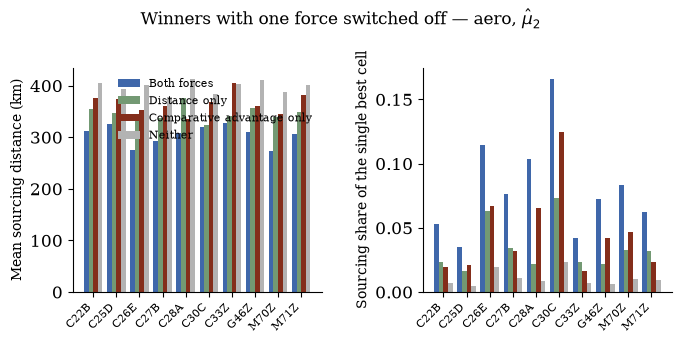

top_cell_share    hhi  mean_distance  \
sector regime                                                             
C22B   Both forces                          0.053  0.019        312.937   
       Distance only                        0.023  0.008        354.952   
       Comparative advantage only           0.019  0.015        376.006   
       Neither                              0.007  0.007        404.745   
C25D   Both forces                          0.035  0.013        326.383   
       Distance only                        0.016  0.005        347.422   
       Comparative advantage only           0.021  0.011        374.018   
       Neither                              0.005  0.005        393.851   
C26E   Both forces                          0.114  0.060        276.003   
       Distance only                        0.063  0.023        340.277   
       Comparative advantage only           0.067  0.049        352.335   
       Neither                              0.020  0.020        402.302   
C27B   Both forces                          0.077  0.029        292.316   
       Distance only                        0.035  0.012        337.165   
       Comparative advantage only           0.032  0.021        360.385   
       Neither                              0.011  0.011        378.396   
C28A   Both forces                          0.104  0.057        308.347   
       Distance only                        0.022  0.009        375.389   
       Comparative advantage only           0.066  0.049        334.543   
       Neither                              0.009  0.009        413.707   
C30C   Both forces                          0.166  0.103        319.154   
       Distance only                        0.073  0.028        323.452   
       Comparative advantage only           0.125  0.096        367.689   
       Neither                              0.023  0.023        384.765   
C33Z   Both forces                          0.042  0.014        328.344   
       Distance only                        0.024  0.008        341.447   
       Comparative advantage only           0.016  0.011        406.205   
       Neither                              0.007  0.007        403.810   
G46Z   Both forces                          0.072  0.030        310.426   
       Distance only                        0.022  0.007        357.116   
       Comparative advantage only           0.042  0.024        361.024   
       Neither                              0.007  0.007        411.198   
M70Z   Both forces                          0.083  0.039        274.039   
       Distance only                        0.033  0.012        339.390   
       Comparative advantage only           0.047  0.031        345.876   
       Neither                              0.010  0.010        387.999   
M71Z   Both forces                          0.062  0.023        306.903   
       Distance only                        0.032  0.010        349.869   
       Comparative advantage only           0.024  0.018        382.456   
       Neither                              0.009  0.009        401.673   

                                   top_area_share  n_cells  
sector regime                                               
C22B   Both forces                          0.285      143  
       Distance only                        0.113      143  
       Comparative advantage only           0.273      143  
       Neither                              0.098      143  
C25D   Both forces                          0.385      216  
       Distance only                        0.094      216  
       Comparative advantage only           0.375      216  
       Neither                              0.083      216  
C26E   Both forces                          0.638       51  
       Distance only                        0.231       51  
       Comparative advantage only           0.602       51  
       Neither                              0.176       51  
C27B   Both forces            

In [33]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    plot_counterfactual_sourcing(
        data, save_to=f"{out_folder}/ca_counterfactual_{industry}_mu{MU}.pdf")
    plt.show()
    display(counterfactual_sourcing(data).round(3))


## Everything in one table

The six tests joined on the sector, in A129-code order, with
`comparative_advantage_glossary()` documenting what every column is and how to read it.


In [34]:
# The six tests in one table, and the reading guide for it.

CA_SUMMARY_GLOSSARY = [
    ("top_area", "The attraction area with the highest estimated T in that sector: the "
                 "sector's favoured location, named by its anchor commuting zone."),
    ("n_areas", "How many attraction areas host at least one observed supplier of the "
                "sector — the number of distinct T values in the competition."),
    ("dlogT_top_vs_median", "log T of the top area minus log T of the median area. The "
                            "size of the edge, in log points, before any distance is "
                            "traded against it."),
    ("equiv_log_d", "That edge converted into distance: Delta log T / (theta*alpha), the "
                    "log distance ratio that exactly offsets it. A region of the top "
                    "area may be exp(.) times further from a buyer than a competing "
                    "region of the median area and still win."),
    ("geo_log_spread", "The log-distance spread a buyer typically faces across the "
                       "regions competing for it (p90 - p10, purchase-weighted). The "
                       "benchmark `equiv_log_d` has to clear for the edge to be decisive "
                       "in ordinary competition."),
    ("geo_log_range", "The extreme version of the same thing: max - min log distance over "
                      "all competing regions and buyers. Anchored at the own-region cell, "
                      "so it is the largest handicap the geography could ever impose."),
    ("CA_beats_typical_geography", "equiv_log_d > geo_log_spread: the edge beats the "
                                   "distances buyers ordinarily face."),
    ("CA_beats_any_geography", "equiv_log_d > geo_log_range: no location in the country "
                               "offsets the edge."),
    ("share_buyers_won", "The exact test, purchase-weighted: the share of downstream "
                         "buyers whose best supplier region actually belongs to the top "
                         "area. Unlike the columns above, nothing is averaged before the "
                         "comparison is made."),
    ("mean_win_margin", "How much further from the buyer the top area's best region could "
                        "be and still beat the best region outside it, in log distance, "
                        "purchase-weighted. Negative means it loses."),
    ("mean_within_penalty", "The log-distance gap between the best and the worst region "
                            "OF THE TOP AREA. Inside an area T cancels, so this is pure "
                            "geography: the handicap the area's own spread imposes."),
    ("area_beats_own_geography", "mean_win_margin > mean_within_penalty: the area's edge "
                                 "matters more than which of its regions a supplier is in."),
    ("sd_logT", "Standard deviation of log T across the cells competing for a buyer — the "
                "pull of comparative advantage."),
    ("sd_dist", "theta*alpha times the standard deviation of log distance across the same "
                "cells — the pull of geography, in the same units."),
    ("ratio_CA_over_distance", "sd_logT / sd_dist. Above one: comparative advantage "
                               "disperses the competition more than distance does."),
    ("share_CA", "Share of Var(log psi) attributable to Var(log T)."),
    ("share_distance", "Share attributable to (theta*alpha)^2 Var(log d)."),
    ("share_covariance", "Share attributable to -2 theta*alpha Cov(log T, log d). Expected "
                         "NEGATIVE: T is the Sinkhorn image of the observed sourcing "
                         "shares, so it compensates remoteness and the two forces offset. "
                         "See ca_covariance_benchmark for the split of that covariance."),
    ("top_area_share (both)", "Purchase-weighted sourcing share of the top area under the "
                              "estimated model."),
    ("top_area_share (CA only)", "The same with alpha = 0: what comparative advantage "
                                 "alone would give it."),
    ("top_area_share (distance only)", "The same with T equalised within the sector: what "
                                       "geography alone would give it."),
]


def comparative_advantage_glossary():
    """The column-by-column reading guide for `comparative_advantage_summary`."""
    return pd.DataFrame(CA_SUMMARY_GLOSSARY, columns=["column", "meaning"]).set_index("column")


def comparative_advantage_summary(data):
    """
    One row per sector: the spread of T, what it buys in distance, whether it actually
    wins, how the dispersion of log psi splits, and the counterfactual allocations.

    `comparative_advantage_glossary()` documents every column.
    """
    eq = ca_distance_equivalence(data)
    wm = ca_win_margin(data)
    vd = ca_variance_decomposition(data)
    cf = counterfactual_sourcing(data)["top_area_share"].unstack("regime")
    out = eq.join(vd, how="outer")
    if len(wm):
        out = out.join(wm.drop(columns=[c for c in ("top_area",) if c in wm.columns]),
                       how="outer")
    out["top_area_share (both)"] = cf["Both forces"]
    out["top_area_share (CA only)"] = cf["Comparative advantage only"]
    out["top_area_share (distance only)"] = cf["Distance only"]
    cols = [c for c, _ in CA_SUMMARY_GLOSSARY]
    return _by_sector_code(out[[c for c in cols if c in out.columns]], data)


In [35]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    display(comparative_advantage_summary(data))

display(comparative_advantage_glossary())


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


,top_area,n_areas,dlogT_top_vs_median,equiv_log_d,geo_log_spread,geo_log_range,CA_beats_typical_geography,CA_beats_any_geography,share_buyers_won,mean_win_margin,...,area_beats_own_geography,sd_logT,sd_dist,ratio_CA_over_distance,share_CA,share_distance,share_covariance,top_area_share (both),top_area_share (CA only),top_area_share (distance only)
sector,,,,,,,,,,,,,,,,,,,,,
C22A,Île-De-France,3,0.669564,2.408932,1.469250,3.912685,True,False,1.000000,3.533481,...,True,0.651117,0.187161,3.478907,0.654327,0.054064,0.291609,0.531363,0.467740,0.249534
C22B,Mulhouse,8,0.532434,1.915569,1.171179,4.511363,True,False,0.257500,-0.679747,...,False,0.989212,0.153835,6.430335,0.840900,0.020337,0.138763,0.068365,0.066148,0.025132
C24A,Île-De-France,2,0.816776,2.938563,1.485341,3.883860,True,False,1.000000,7.729541,...,True,0.724578,0.209435,3.459688,0.653967,0.054636,0.291397,0.732245,0.653628,0.351221
C25D,Belfort - Montbéliard - Héricourt,10,1.394854,5.018348,1.439095,4.517761,True,True,0.987616,1.551357,...,True,1.072871,0.173981,6.166588,0.827224,0.021754,0.151022,0.090128,0.090625,0.019687
C28A,Belfort - Montbéliard - Héricourt,5,0.816543,2.937725,1.337832,4.491595,True,False,0.911744,0.686759,...,True,0.678108,0.168934,4.014029,0.758435,0.047071,0.194494,0.113332,0.106862,0.033038
C29A,Strasbourg,10,1.919272,6.905078,1.217123,4.787456,True,True,0.369191,-0.322976,...,False,0.671285,0.159544,4.207523,0.809645,0.045734,0.144621,0.119969,0.124193,0.024513
C29B,Beauvais,16,1.356553,4.880553,1.479800,4.746346,True,True,0.324350,0.102560,...,False,0.752363,0.180851,4.160128,0.771753,0.044593,0.183654,0.100300,0.086121,0.027595
C33Z,Île-De-France,4,2.534162,9.117304,1.432118,4.471138,True,True,1.000000,6.721950,...,True,1.903463,0.172222,11.052353,0.894879,0.007326,0.097796,0.920645,0.908469,0.236147
G45Z,Île-De-France,8,2.280790,8.205734,1.407663,4.536379,True,True,1.000000,5.500066,...,True,0.873049,0.167171,5.222479,0.928774,0.034053,0.037173,0.528848,0.457246,0.112070


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


,top_area,n_areas,dlogT_top_vs_median,equiv_log_d,geo_log_spread,geo_log_range,CA_beats_typical_geography,CA_beats_any_geography,share_buyers_won,mean_win_margin,...,area_beats_own_geography,sd_logT,sd_dist,ratio_CA_over_distance,share_CA,share_distance,share_covariance,top_area_share (both),top_area_share (CA only),top_area_share (distance only)
sector,,,,,,,,,,,,,,,,,,,,,
C22B,Toulouse,7,1.293688,2.997697,1.435774,4.925035,True,False,0.450328,-0.380309,...,False,1.131751,0.267509,4.230708,0.875730,0.048927,0.075343,0.285056,0.272563,0.113176
C25D,Toulouse,12,1.643669,3.808662,1.413060,5.647328,True,False,0.493404,1.097059,...,False,1.117381,0.255400,4.375030,0.895422,0.046781,0.057798,0.384576,0.375246,0.093962
C26E,Île-De-France,7,1.383665,3.206189,1.663617,4.434990,True,False,0.653828,2.129579,...,True,1.185891,0.313521,3.782497,0.810434,0.056645,0.132922,0.638315,0.602477,0.231153
C27B,Île-De-France,6,1.557577,3.609172,1.299195,4.326218,True,False,0.567604,1.091947,...,False,1.070177,0.252659,4.235665,0.864035,0.048160,0.087805,0.399925,0.351659,0.151421
C28A,Île-De-France,5,2.676533,6.201985,1.250889,4.182868,True,True,1.000000,6.400763,...,True,1.641805,0.237351,6.917201,0.928603,0.019407,0.051989,0.765989,0.722658,0.121888
C30C,Toulouse,10,2.732425,6.331496,1.572740,4.778641,True,True,1.000000,3.755521,...,True,1.268300,0.319381,3.971114,0.868606,0.055081,0.076314,0.729595,0.747091,0.156096
C33Z,Toulouse,7,0.442669,1.025739,1.623199,4.788015,False,False,0.395143,-0.267325,...,False,0.972447,0.298628,3.256378,0.888707,0.083809,0.027485,0.352379,0.346230,0.161855
G46Z,Île-De-France,6,2.457223,5.693805,1.504883,4.394953,True,True,1.000000,4.872720,...,True,0.753461,0.276120,2.728744,0.779187,0.104644,0.116169,0.561000,0.509526,0.101014
M70Z,Île-De-France,5,2.506660,5.808359,1.478601,4.349354,True,True,0.727581,3.243342,...,True,1.181724,0.273073,4.327502,0.837521,0.044722,0.117757,0.598008,0.564804,0.158533


,meaning
column,
top_area,The attraction area with the highest estimated...
n_areas,How many attraction areas host at least one ob...
dlogT_top_vs_median,log T of the top area minus log T of the media...
equiv_log_d,That edge converted into distance: Delta log T...
geo_log_spread,The log-distance spread a buyer typically face...
geo_log_range,The extreme version of the same thing: max - m...
CA_beats_typical_geography,equiv_log_d > geo_log_spread: the edge beats t...
CA_beats_any_geography,equiv_log_d > geo_log_range: no location in th...
share_buyers_won,"The exact test, purchase-weighted: the share o..."


# Amplification of shocks along vertical production linkages

Section 5.1 of the paper, Figure 6. Two numbers per shocked downstream region, both read
off the simulated firm-level economy and therefore selected by `MU` like everything else
here.

**The amplification coefficient.** `share` in `suppliers.parquet` is `exp_val`, the share
of downstream region $r$'s unit cost spent on that supplying firm, so summing over firms
gives $r$'s intermediate-input share of costs and

$$D_r \;=\; 1 \;+\; \sum_{l} X_{lr},$$

the aggregate increase in sales one additional euro of demand in $r$ generates — the euro
itself plus what it pulls upstream. About $1.5$ in the paper: one euro of final demand
generating roughly 50 cents of upstream sales.

**The share of upstream sales within a radius.**

$$L_r(d) \;=\; \frac{\sum_{l\,:\,\mathrm{Dist}_{lr} \le d} X_{lr}}{\sum_l X_{lr}},$$

the geographic incidence of the same shock. The denominator is upstream sales *only* —
the euro of downstream demand is not in it — so $L_r(d)$ is a share of what propagates.

**The radius is a free parameter.** `AMPLIFICATION_RADII` in the Constants cell sets what
the run uses, every function takes `radius_km` or `radii`, and
`amplification_summary(data, radii=(100, 200))` returns both in one pass.
`local_share_profile` sweeps it, so the 100 km headline can be seen for what it is — one
point on a curve — rather than assumed robust.

Three conventions that set the *level* of $D_r$, stated because they are easy to trip over:
`share` is a share of downstream **cost** and the markup factor $\mu$ relating cost to
sales is not applied (the convention of the published figure); the parquet's
`intermediate_derivative` column is renormalised *within* intermediates, sums to one by
construction, and is **not** an amplification measure; and the model has a single upstream
tier, so $D_r$ is the whole of its amplification — there is no round-2 Leontief term to add.

**Is $D_r$ large?** Summing `exp_val` over varieties kills the within-sector CES index
exactly, and summing over sectors kills the across-sector one, so in the model

$$D_r \;=\; 1 + (1-\Omega_L)\left(\frac{P_r}{c_r}\right)^{1-\lambda}$$

over the modelled domestic sectors. $D_r$ is a **cost-share** object: the
comparative-advantage parameters do not appear in it, so the fact that $T$ is only
identified as $w^{\theta}T$ — wages normalised to one — does not contaminate it. That
conflation shapes the *geography* of a shock, not its *size*. The only regional
variation left is $(P_r/c_r)^{1-\lambda}$, local access to cheap inputs, which is why
the coefficients are nearly flat across commuting zones.

The last cells of the section put that number against the input-output table: the
composition and **coverage** of the downstream industry's intermediate purchases (which
need no gross-output data at all), and then the Leontief cascade
$M_d = \sum_i[(I-A)^{-1}]_{id}$ on two supports — every A129 sector, and the modelled
sectors only — which is the aggregate benchmark Acemoglu, Carvalho, Ozdaglar and
Tahbaz-Salehi (2016) use. Read the caveat in that cell before quoting the cascade: the
TES block carries no value added, so the intermediate share each column is normalised to
has to be supplied, and a *common* one makes every sector's multiplier exactly
$1/(1-m)$.

In [36]:
# The two objects of Figure 6 — the amplification coefficient D_r and the share of
# the upstream sales it generates that stays within a radius of the shock. Both are
# read off the simulated firm-level economy, so `mu` selects them. The conventions
# that set the LEVEL of D_r are in the markdown above; the radius is a free
# parameter throughout.

AMPLIFICATION_RADIUS_KM = 100      # the paper's Figure 6; 200 etc. are just as valid


def build_diffusion_frame(data, value_col="share"):
    """
    One row per (shocked downstream region, upstream cell): the upstream sales that
    one euro spent in the downstream region generates there, and the distance
    between the two.

    The grid is ZERO-FILLED over every (downstream region, region) pair — a cell that
    supplies nothing still belongs in the denominator's support and, more to the
    point, in the map. Distances come from `distances.npy` read by the model's own
    integer region indices, so there is no ZE-name round trip to get wrong.
    """
    sup = data.get("suppliers")
    if sup is None:
        raise FileNotFoundError(
            f"no suppliers.parquet under {data['folder']}/{data.get('step_dir','<step>')}/ "
            f"or {data['folder']}/ — main.jl writes one per estimate in its post-hoc block.")
    if value_col not in sup.columns:
        raise KeyError(f"`{value_col}` is not a column of suppliers.parquet "
                       f"({list(sup.columns)}).")

    R = data["R"]
    D = np.load(data["input_folder"] / "distances.npy")[:R, :R]

    agg = (sup.groupby(["ze2010_downstream", "ze2010"], as_index=False)
              .agg(upstream_sales=(value_col, "sum"),
                   n_links=(value_col, "size")))
    shocked = np.sort(sup["ze2010_downstream"].unique())

    grid = pd.MultiIndex.from_product([shocked, np.arange(1, R + 1)],
                                      names=["ze2010_downstream", "ze2010"]).to_frame(index=False)
    df = grid.merge(agg, on=["ze2010_downstream", "ze2010"], how="left").fillna(
        {"upstream_sales": 0.0, "n_links": 0})
    df["distance"] = D[df["ze2010"].to_numpy() - 1, df["ze2010_downstream"].to_numpy() - 1]

    lab = _region_labels(data)
    df = (df.merge(lab.rename(columns={"index": "ze2010", "ze2010": "ze_code",
                                       "ze2010_name": "ze_name"}), on="ze2010")
            .merge(lab.rename(columns={"index": "ze2010_downstream",
                                       "ze2010": "shocked_code",
                                       "ze2010_name": "shocked_name"}),
                   on="ze2010_downstream"))
    df["value_col"] = value_col
    return df


def amplification_summary(data, radii=(AMPLIFICATION_RADIUS_KM,), value_col="share",
                          diffusion=None):
    """
    One row per shocked downstream region: the amplification coefficient and the
    share of the upstream sales it generates that stays within each radius.

    `radii` is a tuple, so 100 km and 200 km (or any other) come out of one pass.
    """
    df = build_diffusion_frame(data, value_col) if diffusion is None else diffusion
    tot = df.groupby("ze2010_downstream")["upstream_sales"].sum()
    out = pd.DataFrame({
        "region": df.groupby("ze2010_downstream")["shocked_name"].first(),
        "upstream_sales": tot,
        "amplification": 1.0 + tot,
        "supplier_cells": df.assign(hit=df["upstream_sales"] > 0)
                            .groupby("ze2010_downstream")["hit"].sum(),
        "mean_upstream_distance": df.eval("upstream_sales * distance")
                                    .groupby(df["ze2010_downstream"]).sum() / tot.replace(0, np.nan),
    })
    for d in radii:
        near = df.loc[df["distance"] <= d].groupby("ze2010_downstream")["upstream_sales"].sum()
        out[f"share_within_{int(d)}km"] = (near.reindex(out.index).fillna(0.0)
                                           / tot.replace(0, np.nan))
    out.attrs["value_col"] = value_col
    out.attrs["radii"] = tuple(radii)
    return out.sort_values("amplification", ascending=False)


def local_share_profile(data, radii=(25, 50, 75, 100, 150, 200, 300, 500),
                        value_col="share", diffusion=None):
    """
    The share within `d` as a FUNCTION of `d`: the mean across shocked regions, its
    interquartile band, and the sales-weighted mean. The single 100 km number of
    Figure 6 is one point on this curve, and the curve says whether that number is a
    knife edge or a plateau.
    """
    df = build_diffusion_frame(data, value_col) if diffusion is None else diffusion
    tot = df.groupby("ze2010_downstream")["upstream_sales"].sum()
    rows = []
    for d in radii:
        near = (df.loc[df["distance"] <= d].groupby("ze2010_downstream")["upstream_sales"]
                  .sum().reindex(tot.index).fillna(0.0))
        sh = (near / tot.replace(0, np.nan)).dropna()
        rows.append({"radius_km": d, "mean": sh.mean(), "median": sh.median(),
                     "p25": sh.quantile(0.25), "p75": sh.quantile(0.75),
                     "weighted_mean": float(near.sum() / tot.sum()) if tot.sum() > 0 else np.nan})
    return pd.DataFrame(rows).set_index("radius_km")

In [37]:
# The two Figure-6 panels, the radius sweep the fixed 100 km hides, and the two
# together in one scatter.

def plot_amplification(data, value_col="share", summary=None, figsize=None,
                       save_to=None):
    """Top panel of Figure 6: the amplification coefficient D_r, by commuting zone."""
    s = (amplification_summary(data, value_col=value_col) if summary is None
         else summary).sort_values("amplification")
    fig, ax = plt.subplots(figsize=figsize or (8, max(3.0, 0.28 * len(s))))
    ax.barh(s["region"].astype(str), s["amplification"], color=toulouse_color)
    ax.set_xlabel(r"Amplification measure $D_r$")
    ax.set_ylabel("Commuting zone")
    ax.set_xlim(left=1.0)
    ax.grid(alpha=0.2, axis="x")
    ax.set_title(f"{data['industry']}, " rf"$\hat\mu_{data['mu']}$"
                 f"   mean $D_r$ = {s['amplification'].mean():.3f}", fontsize=11)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def plot_local_share(data, radius_km=AMPLIFICATION_RADIUS_KM, value_col="share",
                     summary=None, figsize=None, save_to=None):
    """Bottom panel of Figure 6: the share of upstream sales within `radius_km`."""
    s = (amplification_summary(data, radii=(radius_km,), value_col=value_col)
         if summary is None else summary)
    col = f"share_within_{int(radius_km)}km"
    if col not in s.columns:
        raise KeyError(f"{col} is not in the summary — pass `radii=({radius_km},)` "
                       "to amplification_summary, or let this function build it.")
    s = s.sort_values(col)
    fig, ax = plt.subplots(figsize=figsize or (8, max(3.0, 0.28 * len(s))))
    ax.barh(s["region"].astype(str), s[col], color=toulouse_color)
    ax.set_xlabel(f"Share of upstream sales within {radius_km:g} km")
    ax.set_ylabel("Commuting zone")
    ax.grid(alpha=0.2, axis="x")
    ax.set_title(f"{data['industry']}, " rf"$\hat\mu_{data['mu']}$"
                 f"   mean = {s[col].mean():.3f}", fontsize=11)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def plot_local_share_profile(data, radii=(25, 50, 75, 100, 150, 200, 300, 500),
                             mark=(AMPLIFICATION_RADIUS_KM,), value_col="share",
                             profile=None, figsize=None, save_to=None):
    """
    The share within `d` against `d`: the median across shocked regions with its
    interquartile band, and the sales-weighted mean. Shows whether the headline
    number is robust to the radius or sits on a steep part of the curve.
    """
    p = (local_share_profile(data, radii=radii, value_col=value_col)
         if profile is None else profile)
    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.8, hf=0.6))
    ax.fill_between(p.index, p["p25"], p["p75"], color=sim_color, alpha=0.20,
                    label="interquartile range across regions")
    ax.plot(p.index, p["median"], marker="o", color=sim_color, label="median region")
    ax.plot(p.index, p["weighted_mean"], marker="s", color=reference_color,
            linestyle="--", label="sales-weighted mean")
    ax.set_ylim(0, 1)
    for m in mark:
        ax.axvline(m, color="0.6", linewidth=0.9, linestyle=":")
        ax.annotate(f"{m:g} km", (m, 0.98), fontsize=8, color="0.4", ha="left",
                    va="top", xytext=(3, 0), textcoords="offset points")
    ax.set_xlabel("Radius around the shocked region (km)")
    ax.set_ylabel("Share of upstream sales within the radius")
    ax.legend(frameon=False, fontsize=8, loc="upper left")
    ax.set_title(f"{data['industry']}, " rf"$\hat\mu_{data['mu']}$", fontsize=11)
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def plot_amplification_vs_local(data, radius_km=AMPLIFICATION_RADIUS_KM,
                                value_col="share", summary=None, n_label=5,
                                figsize=None, save_to=None):
    """
    How much a shock amplifies against how much of it stays nearby — the two panels
    of Figure 6 in one picture. Labelled: the `n_label` regions that keep the least
    locally, and the `n_label` that amplify the most.
    """
    s = (amplification_summary(data, radii=(radius_km,), value_col=value_col)
         if summary is None else summary).copy()
    col = f"share_within_{int(radius_km)}km"
    flagged = set(s.nsmallest(n_label, col).index) | set(s.nlargest(n_label, "amplification").index)

    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.8, hf=0.7))
    plain = s.loc[~s.index.isin(flagged)]
    named = s.loc[s.index.isin(flagged)]
    ax.scatter(plain["amplification"], plain[col], s=30, color=toulouse_color, alpha=0.8)
    ax.scatter(named["amplification"], named[col], s=45, facecolors="none",
               edgecolors=toulouse_color, linewidths=1.2)
    texts = [ax.text(r["amplification"], r[col], str(r["region"]), fontsize=8)
             for _, r in named.iterrows()]
    try:                                   # nicer label placement when available
        from adjustText import adjust_text
        adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", lw=0.5, color="black"))
    except ImportError:
        pass
    ax.set_xlabel(r"Amplification measure $D_r$")
    ax.set_ylabel(f"Share of upstream sales within {radius_km:g} km")
    ax.set_title(f"{data['industry']}, " rf"$\hat\mu_{data['mu']}$", fontsize=11)
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def amplification_report(data, radii=(AMPLIFICATION_RADIUS_KM, 200), value_col="share",
                         out_folder=None, show=True):
    """
    Everything in this section for one industry, in one call: the two Figure-6 panels,
    the radius sweep, the joint scatter and the summary table.

    Returns `(summary, profile)` so the numbers can be reused without recomputing.
    `radii[0]` is the radius the bar chart and the scatter use.
    """
    diff = build_diffusion_frame(data, value_col)
    summ = amplification_summary(data, radii=radii, value_col=value_col, diffusion=diff)
    prof = local_share_profile(data, value_col=value_col, diffusion=diff)

    ind, mu = data["industry"], data["mu"]
    tag = lambda name: (None if out_folder is None
                        else f"{out_folder}/{name}_{ind}_mu{mu}.pdf")

    print(f"[{ind}, mu = {mu}]  mean D_r = {summ['amplification'].mean():.3f} "
          f"(one euro of demand -> {summ['upstream_sales'].mean():.3f} upstream), "
          f"p90 = {summ['amplification'].quantile(0.9):.3f}")
    for d in radii:
        c = f"share_within_{int(d)}km"
        print(f"                 share of upstream sales within {d:g} km: "
              f"mean {summ[c].mean():.3f}, median {summ[c].median():.3f}, "
              f"min {summ[c].min():.3f}, max {summ[c].max():.3f}")

    plot_amplification(data, summary=summ, save_to=tag("amplification"))
    if show:
        plt.show()
    plot_local_share(data, radius_km=radii[0], summary=summ,
                     save_to=tag(f"local_share_{int(radii[0])}km"))
    if show:
        plt.show()
    plot_local_share_profile(data, profile=prof, mark=radii,
                             save_to=tag("local_share_profile"))
    if show:
        plt.show()
    plot_amplification_vs_local(data, radius_km=radii[0], summary=summ,
                                save_to=tag("amplification_vs_local"))
    if show:
        plt.show()
    return summ, prof

## Is $D_r$ large? The input-output benchmark

The model's amplification has a closed form. Summing `share` over the varieties of a
sector kills the within-sector CES index exactly, and summing the result over sectors
kills the across-sector one, so over the modelled domestic sectors

$$D_r \;=\; 1 + (1-\Omega_L)\left(\frac{P_r}{c_r}\right)^{1-\lambda}.$$

Three things follow. $D_r$ is a **cost-share** object: the comparative-advantage
parameters do not appear in it — $T$ reallocates *which* cell supplies, not *how much* is
bought — so the fact that $T$ is only identified as $w^\theta T$ does not contaminate it.
That conflation shapes the *geography* of a shock, not its *size*. The only regional
variation left is $(P_r/c_r)^{1-\lambda}$, local access to cheap inputs, which is why the
coefficients are nearly flat across commuting zones. And $D_r - 1$ *is* the downstream
firm's intermediate-input share of unit cost, so it can be checked against one minus the
aggregate labor share the estimator targets: those two disagreeing is a real problem,
agreeing is a check that the level is not an artefact of the summation.

**The benchmark.** The model has one upstream tier, so $D_r$ is a first-round object. The
input-output analogue of the first round is $1 + \sum_i a_{id}$, the column sum of the
technical-coefficient matrix; the analogue of the whole cascade is the column sum of the
Leontief inverse, $M_d = \sum_i[(I-A)^{-1}]_{id}$ — the total output generated across the
economy by one euro of final demand for $d$ (Acemoglu, Carvalho, Ozdaglar and
Tahbaz-Salehi, 2016).

**The one thing the TES block cannot supply.** $a_{ij} = X_{ij}/x_j$ needs sector $j$'s
gross output, and the intermediate-flow block carries no value added and no output row.
Each column has to be normalised to an intermediate share $m_j$ supplied from outside —
and with a *common* $m$, every column of $A$ sums to $m$, so $\sum_i (A^k)_{ij} = m^k$ and
the Leontief total is exactly $1/(1-m)$ for **every** sector. The cascade then measures
the assumption and nothing about the network. Pass a per-sector Series (value added over
gross output) for an informative answer; the scalar path still runs, and says so loudly.

Two comparisons need no output data at all, which is why they come first: the
**composition** of the downstream industry's intermediate purchases against the model's
own simulated split, and the **coverage** — the share of those purchases falling on the
modelled sectors, and how much of the column is domestic. The model's $D_r - 1$ is a
first-round, domestic, modelled-sectors-only object, so $(D_r-1)/\text{coverage}$ is what
it implies for the downstream firm's total intermediate share, a number that has to be
below one and near the labour-share moment's complement to be credible.


In [38]:
# The input-output benchmark for D_r: the composition and coverage of the downstream
# industry's intermediate purchases, then the Leontief cascade. The caveat about the
# intermediate share the TES block cannot supply is in the markdown above, and the
# scalar path repeats it at runtime.

IO_TABLE_KINDS = ("dom", "imp")     # TES_dom.csv = domestic flows, TES_imp.csv = imports


def read_io_table(kind, folder):
    """
    One INSEE TES intermediate-flow block, long: (A129_1 supplying, A129_2 using, value).

    Same parsing as the pipeline that built `pi_s`: semicolon separated, no header,
    the first column being the row labels, and a comma decimal separator.
    """
    path = Path(folder) / f"TES_{kind}.csv"
    if not path.exists():
        raise FileNotFoundError(path)
    io = pd.read_csv(path, sep=";", header=None, index_col=0)
    io.columns = io.index
    io = io.reset_index()
    first = io.columns[0]
    io = io.melt(id_vars=first, var_name="A129_2", value_name="value")
    io = io.rename(columns={first: "A129_1"})
    io["value"] = io["value"].astype(str).str.replace(",", ".").astype(float)
    io["A129_1"] = io["A129_1"].astype(str).str.strip()
    io["A129_2"] = io["A129_2"].astype(str).str.strip()
    return io


def io_flow_matrix(data, kinds=("dom",), io_folder=None):
    """
    The square (supplying x using) flow matrix, summed over `kinds`.

    `kinds=("dom",)` is the domestic technology — the right support for a multiplier
    that is meant to stay in France, since imports leak out of the cascade.
    `("dom", "imp")` is total use, which is the support the sector shares `pi_s` were
    built on.
    """
    folders = ([Path(io_folder)] if io_folder is not None
               else [data["input_folder"], data["folder"], data["input_folder"].parent])
    total, used = None, None
    for f in folders:
        try:
            parts = [read_io_table(k, f) for k in kinds]
        except FileNotFoundError:
            continue
        used = f
        for p in parts:
            m = p.pivot(index="A129_1", columns="A129_2", values="value").fillna(0.0)
            total = m if total is None else total.add(m, fill_value=0.0)
        break
    if total is None:
        raise FileNotFoundError(
            "no TES table found. Looked for " + ", ".join(f"TES_{k}.csv" for k in kinds)
            + " in " + ", ".join(str(f) for f in folders) +
            ". Pass `io_folder=` to point at the directory that holds them.")
    idx = sorted(set(total.index) | set(total.columns))
    total = total.reindex(index=idx, columns=idx).fillna(0.0)
    total.attrs["io_folder"] = str(used)
    total.attrs["kinds"] = tuple(kinds)
    return total


def io_technical_coefficients(X, intermediate_share):
    """
    `A` from the flow block: each column normalised to sum to that sector's
    intermediate share of output.

    `intermediate_share` is a scalar applied to every sector, or a Series indexed by
    A129. A column of zeros (a sector that buys nothing in the table) stays zero.
    """
    col_tot = X.sum(axis=0).replace(0.0, np.nan)
    m = (pd.Series(float(intermediate_share), index=X.columns)
         if np.isscalar(intermediate_share)
         else pd.Series(intermediate_share).reindex(X.columns))
    if m.isna().any():
        raise ValueError(f"no intermediate share for {list(m.index[m.isna()])}")
    if (m >= 1).any():
        raise ValueError("an intermediate share >= 1 makes (I - A) singular: a sector "
                         "cannot spend its whole output on intermediates and still "
                         "close the cascade.")
    return (X / col_tot).fillna(0.0) * m


def leontief_multipliers(A, max_rounds=None):
    """
    Column sums of the Leontief inverse — total output per euro of final demand — and,
    when `max_rounds` is given, the same truncated after that many rounds.

    `(I - A)^{-1} = I + A + A^2 + ...`, so the round-1 truncation `1 + sum_i a_{id}`
    is the object the model's single upstream tier corresponds to.
    """
    n = A.shape[0]
    L = np.linalg.inv(np.eye(n) - A.to_numpy())
    if (np.diag(L) <= 0).any() or not np.isfinite(L).all():
        raise ValueError("(I - A) is not invertible or the inverse is not positive — "
                         "check the intermediate shares.")
    out = {"total": pd.Series(L.sum(axis=0), index=A.columns)}
    if max_rounds:
        P, acc = np.eye(n), np.eye(n)
        for _ in range(max_rounds):
            P = P @ A.to_numpy()
            acc = acc + P
            out[f"rounds_{_ + 1}"] = pd.Series(acc.sum(axis=0), index=A.columns)
    return pd.DataFrame(out)


def io_downstream_column(data, io_folder=None, summary=None):
    """
    Who supplies the downstream industry, in the IO table and in the model.

    Needs no gross output and no assumption: both sides are SHARES of the downstream
    industry's intermediate purchases. `pi_s_io` is the object the sector weights were
    calibrated on (dom + imp over the modelled sectors, renormalised); `share_model` is
    the simulated split of upstream sales across sectors, so the two should agree, and
    a sector where they do not is a fit problem rather than a benchmarking one.
    """
    d = data["d"]
    dom = io_flow_matrix(data, kinds=("dom",), io_folder=io_folder)
    imp = io_flow_matrix(data, kinds=("imp",), io_folder=io_folder)
    if d not in dom.columns:
        raise KeyError(f"the downstream industry {d} is not a column of the TES table.")
    col = pd.DataFrame({"dom": dom[d], "imp": imp[d].reindex(dom.index).fillna(0.0)})
    col["total"] = col["dom"] + col["imp"]
    col["modelled"] = col.index.isin(data["sector_names"])
    col["share_of_total"] = col["total"] / col["total"].sum()
    col["share_of_dom"] = col["dom"] / col["dom"].sum()
    col["pi_s_io"] = np.where(col["modelled"],
                              col["total"] / col.loc[col["modelled"], "total"].sum(), np.nan)

    sup = data.get("suppliers")
    if sup is not None:
        by_s = sup.groupby("A129")["share"].sum()
        by_s = by_s / by_s.sum()
        # the parquet keys sectors by the model's 1..S index, in A129-code order
        names = list(data["sector_names"])
        by_s.index = [names[int(i) - 1] if 1 <= int(i) <= len(names) else str(i)
                      for i in by_s.index]
        col["share_model"] = by_s.reindex(col.index)
    return col.sort_values("total", ascending=False)


def io_amplification_benchmark(data, summary=None, intermediate_share=None,
                               kinds=("dom",), io_folder=None, verbose=True):
    """
    The model's D_r against the input-output benchmarks: the first round, and the whole
    Leontief cascade — the latter on TWO supports, since restricting the economy to the
    modelled sectors is a judgement call rather than a fact.

      FULL     every A129 sector in the table: the true aggregate multiplier;
      SUBSET   the modelled sectors plus the downstream industry: the cascade the model
               could in principle represent, so the honest ceiling for it.

    Returns a one-row-per-support table plus the per-sector multipliers for the figure.
    """
    d = data["d"]                                    # C29A (auto) / C30C (aero)
    X = io_flow_matrix(data, kinds=kinds, io_folder=io_folder)
    if d not in X.columns:
        raise KeyError(f"the downstream industry {d} is not a column of the TES table "
                       f"({len(X.columns)} sectors).")
    m = (1.0 - float(data["agg_labor_share"])) if intermediate_share is None \
        else intermediate_share
    scalar_m = np.isscalar(m)

    subset = [s for s in data["sector_names"] if s in X.columns]
    if d not in subset:
        subset = subset + [d]
    missing = [s for s in data["sector_names"] if s not in X.columns]

    rows, per_sector = [], {}
    for label, cols in (("full", list(X.columns)), ("subset", subset)):
        Xs = X.loc[cols, cols]
        A = io_technical_coefficients(Xs, m)
        mult = leontief_multipliers(A, max_rounds=2)
        per_sector[label] = mult
        rows.append({
            "support": label,
            "n_sectors": len(cols),
            "round1": 1.0 + float(A[d].sum()),
            "rounds_2": float(mult.loc[d, "rounds_2"]),
            "leontief_total": float(mult.loc[d, "total"]),
        })
    tab = pd.DataFrame(rows).set_index("support")

    # --- coverage: what fraction of the true first round the model can represent,
    # from shares alone, with no output data and no assumption
    col = io_downstream_column(data, io_folder=io_folder, summary=summary)
    cov_dom = float(col.loc[col["modelled"], "dom"].sum() / col["dom"].sum())
    cov_tot = float(col.loc[col["modelled"], "total"].sum() / col["total"].sum())
    dom_share = float(col["dom"].sum() / col["total"].sum())

    # the model side: D_r - 1 IS the intermediate share of downstream unit cost
    s = amplification_summary(data) if summary is None else summary
    D_mean = float(s["amplification"].mean())
    tab["model_D_r"] = D_mean
    tab["captured_of_aggregate"] = (D_mean - 1.0) / (tab["leontief_total"] - 1.0)
    tab["model_over_round1"] = (D_mean - 1.0) / (tab["round1"] - 1.0)
    tab.attrs.update(intermediate_share=m, downstream=d, kinds=tuple(kinds),
                     io_folder=X.attrs["io_folder"], per_sector=per_sector,
                     missing_sectors=missing, downstream_column=col,
                     scalar_m=scalar_m,
                     coverage_modelled_dom=cov_dom, coverage_modelled_total=cov_tot,
                     domestic_share_of_column=dom_share,
                     implied_intermediate_share=D_mean - 1.0,
                     implied_total_intermediate_share=(D_mean - 1.0) / cov_dom
                     if cov_dom > 0 else np.nan,
                     data_intermediate_share=1.0 - float(data["agg_labor_share"]))

    if verbose:
        print(f"[{data['industry']}]  downstream industry {d}, TES from "
              f"{X.attrs['io_folder']} ({'+'.join(kinds)}), "
              f"intermediate share m = {m if np.isscalar(m) else 'per sector'}")
        print(f"  model  : mean D_r = {D_mean:.3f}  -> the modelled domestic sectors are "
              f"{D_mean - 1:.3f} of downstream unit cost")
        print(f"  IO     : those sectors are {100 * cov_dom:.1f}% of the industry's "
              f"DOMESTIC intermediate purchases ({100 * cov_tot:.1f}% of dom + imp; "
              f"the column is {100 * dom_share:.1f}% domestic)")
        print(f"           => implied TOTAL intermediate share of unit cost = "
              f"{(D_mean - 1) / cov_dom:.3f}" if cov_dom > 0 else "")
        print(f"           1 - aggregate labor share (the targeted moment) = "
              f"{1 - float(data['agg_labor_share']):.3f}")
        if scalar_m:
            print("  NOTE: a COMMON intermediate share was used, so every sector's "
                  f"Leontief total is exactly 1/(1-m) = {1 / (1 - m):.3f} and the "
                  "cascade below measures that assumption, not the network. Pass a "
                  "per-sector `intermediate_share` (value added / gross output) for an "
                  "informative comparison.")
        for lab, r in tab.iterrows():
            print(f"  IO {lab:<6}: round 1 = {r['round1']:.3f}, "
                  f"two rounds = {r['rounds_2']:.3f}, Leontief total = "
                  f"{r['leontief_total']:.3f}   "
                  f"(model captures {100 * r['captured_of_aggregate']:.0f}% of the "
                  f"aggregate, {100 * r['model_over_round1']:.0f}% of round 1)")
        if missing:
            print(f"  NOTE: {len(missing)} modelled sector(s) absent from the TES "
                  f"table: {missing}")
    return tab


def plot_io_benchmark(data, benchmark=None, figsize=None, save_to=None, **kw):
    """
    Is D_r large? The distribution of the Leontief total multiplier across ALL sectors,
    with the downstream industry, the model's mean D_r and the first-round benchmark
    marked on it. A number is high or low relative to that distribution, not in itself.
    """
    tab = io_amplification_benchmark(data, verbose=False, **kw) if benchmark is None \
        else benchmark
    mult = tab.attrs["per_sector"]["full"]["total"].sort_values()
    d, D_mean = tab.attrs["downstream"], float(tab["model_D_r"].iloc[0])
    if tab.attrs.get("scalar_m", False):
        print("plot_io_benchmark: the cross-sector distribution is degenerate under a "
              "common intermediate share (every sector at 1/(1-m)). The figure still "
              "places the model, but the spread is an artefact — pass a per-sector "
              "`intermediate_share` for a real distribution.")

    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.85, hf=0.6))
    ax.plot(mult.to_numpy(), np.linspace(0, 1, len(mult)), color=sim_color, lw=1.6,
            label="all A129 sectors (Leontief total)")
    for x, c, lab in ((mult.get(d, np.nan), reference_color,
                       f"{d} Leontief total = {mult.get(d, np.nan):.2f}"),
                      (float(tab.loc["full", "round1"]), "0.45",
                       f"{d} round 1 = {tab.loc['full', 'round1']:.2f}"),
                      (D_mean, toulouse_color, rf"model mean $D_r$ = {D_mean:.2f}")):
        if np.isfinite(x):
            ax.axvline(x, color=c, linestyle="--", lw=1.3, label=lab)
    q = float((mult <= D_mean).mean())
    ax.set_xlabel("Total output per euro of final demand")
    ax.set_ylabel("Share of sectors below")
    ax.set_title(f"{data['industry']}, " rf"$\hat\mu_{data['mu']}$"
                 f"   model $D_r$ at the {100 * q:.0f}th percentile of sectors",
                 fontsize=11)
    ax.legend(frameon=False, fontsize=8, loc="lower right")
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax

/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


[auto, mu = 2]  mean D_r = 1.822 (one euro of demand -> 0.822 upstream), p90 = 1.824
                 share of upstream sales within 100 km: mean 0.077, median 0.063, min 0.017, max 0.244
                 share of upstream sales within 200 km: mean 0.246, median 0.205, min 0.160, max 0.495


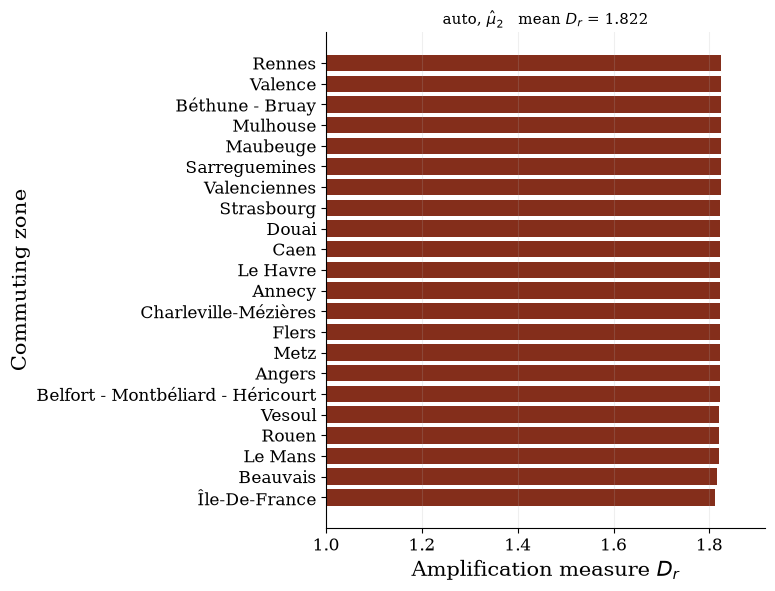

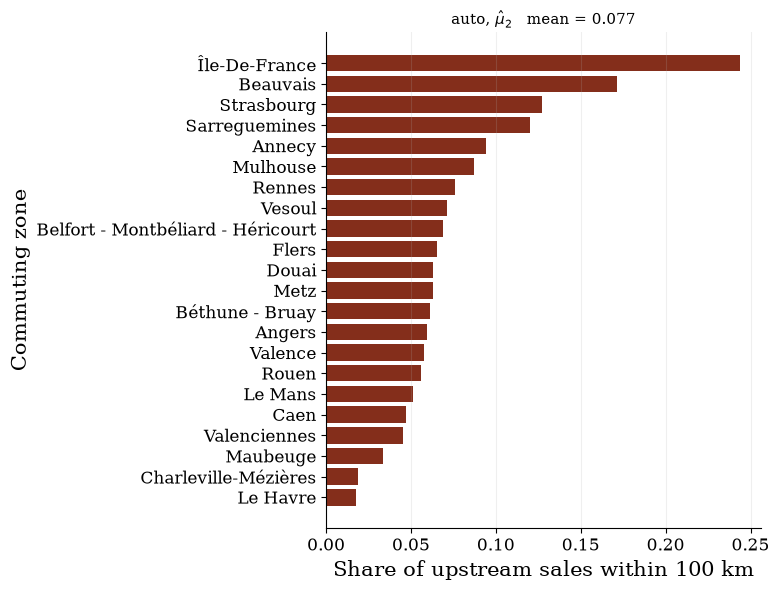

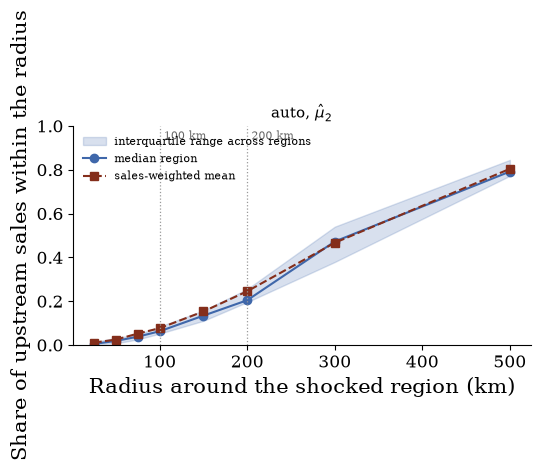

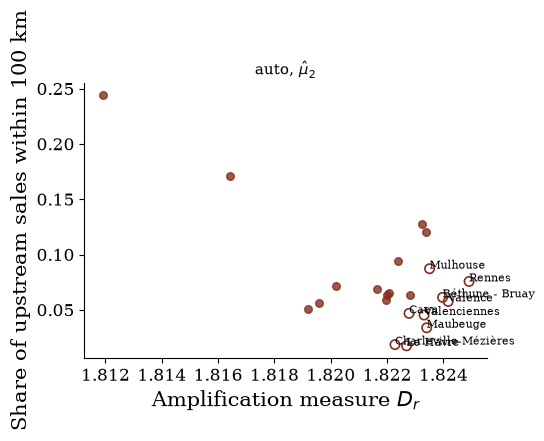

[auto]  downstream industry C29A, TES from ../baseline_auto (dom), intermediate share m = 0.8448979386516853
  model  : mean D_r = 1.822  -> the modelled domestic sectors are 0.822 of downstream unit cost
  IO     : those sectors are 63.5% of the industry's DOMESTIC intermediate purchases (67.3% of dom + imp; the column is 59.0% domestic)
           => implied TOTAL intermediate share of unit cost = 1.295
           1 - aggregate labor share (the targeted moment) = 0.845
  NOTE: a COMMON intermediate share was used, so every sector's Leontief total is exactly 1/(1-m) = 6.447 and the cascade below measures that assumption, not the network. Pass a per-sector `intermediate_share` (value added / gross output) for an informative comparison.
  IO full  : round 1 = 1.845, two rounds = 2.559, Leontief total = 6.447   (model captures 15% of the aggregate, 97% of round 1)
  IO subset: round 1 = 1.845, two rounds = 2.559, Leontief total = 6.447   (model captures 15% of the aggregate, 97% of round

,n_sectors,round1,rounds_2,leontief_total,model_D_r,captured_of_aggregate,model_over_round1
support,,,,,,,
full,138,1.845,2.559,6.447,1.822,0.151,0.973
subset,10,1.845,2.559,6.447,1.822,0.151,0.973


,dom,imp,total,modelled,share_of_total,share_of_dom,pi_s_io,share_model
A129_1,,,,,,,,
C29A,1305.992,3491.482,4797.474,True,0.1602,0.0739,0.2380,0.2416
C29B,1264.404,1907.007,3171.411,True,0.1059,0.0715,0.1573,0.1629
G45Z,2368.608,0.000,2368.608,True,0.0791,0.1340,0.1175,0.1224
C28A,385.795,1799.754,2185.549,True,0.0730,0.0218,0.1084,0.1053
G46Z,1874.860,179.963,2054.823,True,0.0686,0.1060,0.1019,0.1084
C25D,1606.833,0.000,1606.833,True,0.0536,0.0909,0.0797,0.0814
C22B,841.858,514.752,1356.610,True,0.0453,0.0476,0.0673,0.0720
C33Z,1150.074,90.690,1240.764,True,0.0414,0.0650,0.0616,0.0653
M73Z,663.758,218.441,882.199,False,0.0295,0.0375,NaN,NaN


plot_io_benchmark: the cross-sector distribution is degenerate under a common intermediate share (every sector at 1/(1-m)). The figure still places the model, but the spread is an artefact — pass a per-sector `intermediate_share` for a real distribution.


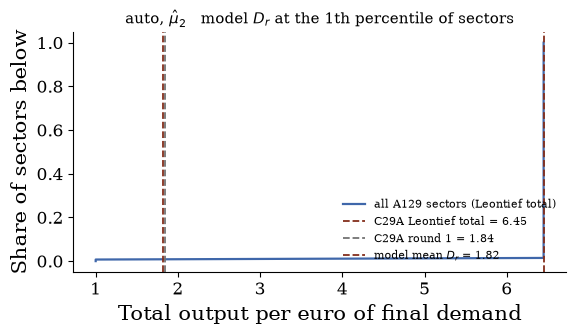

/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


[aero, mu = 2]  mean D_r = 1.819 (one euro of demand -> 0.819 upstream), p90 = 1.829
                 share of upstream sales within 100 km: mean 0.080, median 0.048, min 0.000, max 0.414
                 share of upstream sales within 200 km: mean 0.196, median 0.184, min 0.000, max 0.598


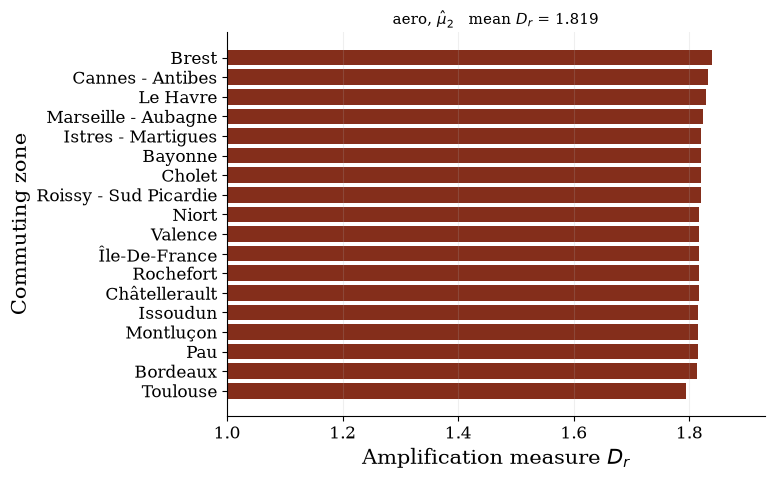

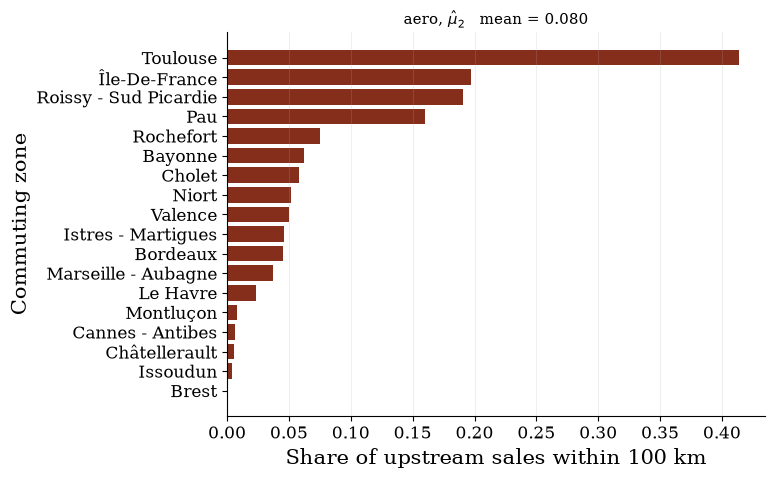

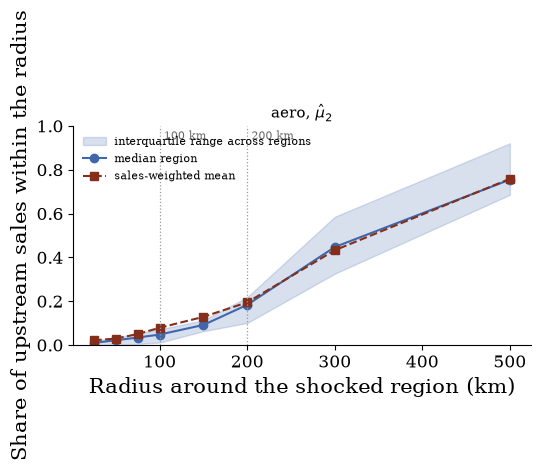

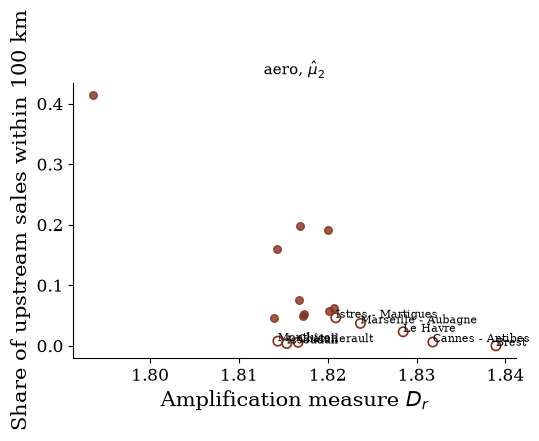

[aero]  downstream industry C30C, TES from ../baseline_aero (dom), intermediate share m = 0.8510782076751053
  model  : mean D_r = 1.819  -> the modelled domestic sectors are 0.819 of downstream unit cost
  IO     : those sectors are 72.3% of the industry's DOMESTIC intermediate purchases (80.5% of dom + imp; the column is 45.8% domestic)
           => implied TOTAL intermediate share of unit cost = 1.133
           1 - aggregate labor share (the targeted moment) = 0.851
  NOTE: a COMMON intermediate share was used, so every sector's Leontief total is exactly 1/(1-m) = 6.715 and the cascade below measures that assumption, not the network. Pass a per-sector `intermediate_share` (value added / gross output) for an informative comparison.
  IO full  : round 1 = 1.851, two rounds = 2.575, Leontief total = 6.715   (model captures 14% of the aggregate, 96% of round 1)
  IO subset: round 1 = 1.851, two rounds = 2.575, Leontief total = 6.715   (model captures 14% of the aggregate, 96% of round

,n_sectors,round1,rounds_2,leontief_total,model_D_r,captured_of_aggregate,model_over_round1
support,,,,,,,
full,138,1.851,2.575,6.715,1.819,0.143,0.962
subset,10,1.851,2.575,6.715,1.819,0.143,0.962


,dom,imp,total,modelled,share_of_total,share_of_dom,pi_s_io,share_model
A129_1,,,,,,,,
C30C,6349.585,16899.867,23249.452,True,0.4979,0.2972,0.6184,0.5683
C33Z,4340.815,342.295,4683.110,True,0.1003,0.2032,0.1246,0.1181
C26E,12.912,2563.343,2576.255,True,0.0552,0.0006,0.0685,0.0868
G46Z,2124.009,203.879,2327.888,True,0.0499,0.0994,0.0619,0.0804
C28A,269.091,1255.322,1524.413,True,0.0326,0.0126,0.0405,0.0746
N78Z,977.000,0.000,977.000,False,0.0209,0.0457,NaN,NaN
M70Z,828.542,55.679,884.221,True,0.0189,0.0388,0.0235,0.0376
M71Z,569.876,148.231,718.107,True,0.0154,0.0267,0.0191,0.0064
C27B,110.626,468.915,579.541,True,0.0124,0.0052,0.0154,0.0130


plot_io_benchmark: the cross-sector distribution is degenerate under a common intermediate share (every sector at 1/(1-m)). The figure still places the model, but the spread is an artefact — pass a per-sector `intermediate_share` for a real distribution.


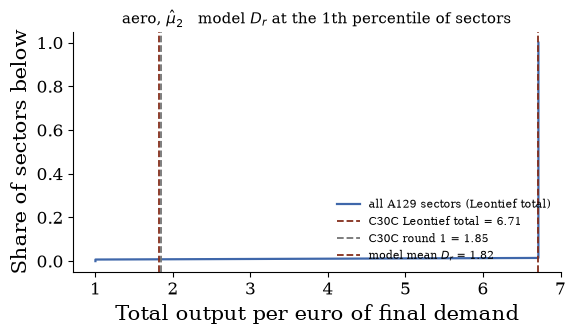

In [39]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)   # same pattern as analysis.ipynb: binds input_folder, folder,
                             # coefs, emp_gamma_ls, X_dr, best_params, france, ... by name

    # --- Amplification along vertical linkages (Figure 6) --------------------
    # radii[0] is the radius the bar chart and the scatter use; change
    # AMPLIFICATION_RADII in the Constants cell to test another one.
    summary, _ = amplification_report(data, radii=AMPLIFICATION_RADII,
                                      out_folder=out_folder)

    # --- Is D_r large? the input-output benchmark ----------------------------
    # Guarded: without TESdom.csv / TESimp.csv beside the run this prints a note
    # instead of breaking the section.
    try:
        bench = io_amplification_benchmark(data, summary=summary)
        display(bench.round(3))
        display(io_downstream_column(data).head(15).round(4))
        plot_io_benchmark(data, benchmark=bench,
                          save_to=f"{out_folder}/io_benchmark_{industry}_mu{MU}.pdf")
        plt.show()
    except FileNotFoundError as e:
        print(f"  IO benchmark skipped: {e}")

# Validation of the sections above

These sections do arithmetic that is easy to get wrong *silently*: an index space
confused for another, a mask applied on the wrong axis, an estimator that converges to
a plausible-looking number that is not the one intended. None of it would raise. So each
is gated by `test/test_analysis_granular_sections.py`, which needs neither Julia nor the
real data:

```bash
python test/test_analysis_granular_sections.py
```

It writes a **synthetic run tree with the exact file layout the loader expects** and then
executes **the notebook's own code cells** against it (located by content, not by index),
so what is tested is the shipped artefact rather than a copy that can drift from it. The
reasoning behind each gate:

**Identification / sensitivity.** Two risks. The *axis*: the variety-count columns are
appended on the right of the Jacobian by Julia, so the loader has to attach the label
block to the correct end, and a silent off-by-one would move the $N_s$ derivative onto the
wrong parameters and still look reasonable. The gate plants a diagonal
$\partial \bar G_s/\partial N_s$ and requires the embedded columns to be exactly zero off
block 6 and equal to $\hat N_s\,(\partial m/\partial N)/m$ on it. The *thresholds*: a
structural zero and an unmeasurable entry are different objects and must never be pooled,
so the gate plants one entry whose Monte-Carlo standard deviation is twice its elasticity
and requires it — and only it — to be masked, while the exact zeros come back as measured.

**Untargeted moment.** Two independent risks. The *wiring*: `fepois_fit` writes the
formula, passes the Monte-Carlo draw weights as analytic weights and clusters on the
supplier's region, and a mistake in any of those returns a plausible number without
complaint. It is checked against `statsmodels`' Poisson GLM with **explicit dummies** — a
different algorithm for the same estimand — agreeing to $10^{-6}$; a continuous share-like
outcome recovers a planted elasticity (Poisson PML is a conditional-*mean* estimator,
which is exactly why shares are admissible). The *panel*: the zeros are half the moment,
so the gate checks the grid is filled to exactly $n_{\text{firms}} \times R_d$ rows, that
$a_{ir}$ sums to one per supplier, and that every distance matches `distances.npy` read by
integer region index. The decomposition is checked for the sign of its extensive term, for
the identity closing to within the documented fixed-effect wedge, and for the intensive
regression running on strictly fewer cells than the total. The bin profile is checked to
normalise at the reference bin and to differ from the unconditional profile — i.e. that
the fixed effect is doing something.

**Comparative advantage.** The risk is the parameter layout: `best_params` is the raw
$\theta$, whose $T$ block is s-major over the *active* $(s, a)$ pairs and includes each
sector's reference, which `unpack_params` then divides out. Read it with the wrong offset
or the wrong ordering and every number downstream is wrong but finite. The gate plants a
known $T$, checks the recovered matrix equals $T/T_{\text{ref}}$ entry by entry, and
checks the length assertion fires on a mismatch. The win probabilities are recomputed
independently from the closed form and must agree; $\alpha = 0$ must make $\rho$
buyer-invariant and proportional to $T$; equalising $T$ must leave pure gravity; the
"Neither" regime must return exactly the uniform $1/n$. The variance decomposition is an
identity, so its three shares must sum to one to machine precision. Finally a sector is
given a large planted edge and one a flat profile, and the gate checks the summary ranks
them accordingly — that the measurement responds to the thing it claims to measure.

**Amplification.** The measure is a ratio whose numerator and denominator are easy to
mismatch — the denominator is upstream sales only, the numerator a distance-truncated part
of the same sum — and a wrong distance lookup would still produce a plausible bar chart.
The gate plants a firm-level economy in which every downstream region spends a known total
on intermediates, so $D_r = 1.5$ must come back exactly; it checks the
(region $\times$ region) grid is fully zero-filled, that every distance matches
`distances.npy` read by integer index, and that $L_r(d)$ reproduces a direct count on the
same frame. Because $L_r(\cdot)$ is a CDF in the radius, the profile must be monotone with
$p_{25}\le$ median $\le p_{75}$ throughout, a 10 000 km radius must return exactly one, and
a 0 km radius must keep the shocked region alone — four properties a sign error or a
transposed distance matrix would break. A smaller radius keeping strictly less than a
larger one is the check that the radius is genuinely free rather than baked in somewhere.

**The input-output benchmark.** Three separable risks. The *parser*: the TES CSV has
comma decimals, no header and its labels in the first column, so a silent misread would
transpose supplying and using sectors — the gate writes a known matrix out in that exact
format and requires it back, orientation included. The *normalisation*: each column of
$A$ must sum to the intermediate share it was given, scalar or per sector. The *algebra*:
under a common $m$ every column of $A$ sums to $m$, so
$\sum_i (A^k)_{ij} = m^k$ and the Leontief total must be exactly the geometric series
$1/(1-m)$ for every sector, with the truncations $1+m$ and $1+m+m^2$ — three closed
forms the gate checks to machine precision, which pins the inverse, the round
truncations and their nesting at once. It is also the reason the scalar path prints a
warning: that same identity means a common $m$ makes the cross-sector distribution
degenerate, so the cascade would be measuring the assumption rather than the network.
Finally the *coverage* numbers, which need no output data, are checked against a direct
share computation, and both an unknown downstream industry and an absent table must
raise something that names what is missing.

Two behaviours are asserted rather than assumed because they are the ones a reader would
otherwise have to take on trust: the exact zeros in the $N_s$ columns (structural, not
numerical) and the refusal to run the distance-equivalence under a binned trade cost,
where no single distance elasticity exists.

# Full Run

In [40]:
# =============================================================================
# RUN THE REPORTING — every section above, in order, on one set of flags.
#
# Each section can be run on its own from its own run cell; this cell re-executes all
# of them for a clean end-to-end pass. A new figure has to be added in BOTH places.
# =============================================================================
# mu = 1 -> step1 best parameters (theta_hat_1)
# mu = 2 -> step3 best parameters (theta_hat_2, the efficient estimate)
MU = 1

INDUSTRIES = [{"industry": "auto", "display_name": "Motor Vehicles"},
              {"industry": "aero", "display_name": "Aerospace"}]
RUN_KWARGS = dict(base="..", profile_T=True, ca_level="aa",
                  granular=True, relax_n_lo=False, optimizer="pso")

AMPLIFICATION_RADII = (100, 200)

out_folder = "../reporting_combined"
os.makedirs(out_folder, exist_ok=True)

# --- Moment table: labor share + industry shares -----------------------------
tex = generate_combined_table(INDUSTRIES, mu=MU, **RUN_KWARGS,
                              output_file=os.path.join(out_folder, f"moments_comparison_combined_mu{MU}.tex"))
print(tex)

untargeted_results = []

for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)
    print(f"{industry}: S={data['S']}  n_AA={data['n_AA']}  N_REG={data['n_coef']}  "
          f"moments from {data['folder'].name}/{data['step_dir']}, "
          f"SEs from {data['inference_step']}/inference")

    # --- Fit ------------------------------------------------------------------
    plot_gamma_aa(data, save_to=f"{out_folder}/emp_sim_gamma_aa_{industry}_mu{MU}.pdf")
    plt.show()
    plot_pi_r(data, save_to=f"{out_folder}/emp_sim_pi_{industry}_mu{MU}.pdf")
    plt.show()
    plot_reg_coef(data, save_to=f"{out_folder}/emp_sim_reg_coef_{industry}_mu{MU}.pdf")
    plt.show()
    plot_G0(data, save_to=f"{out_folder}/emp_sim_G0_{industry}_mu{MU}.pdf")
    plt.show()

    # --- Jacobian: the triptych, the per-block panels, the summary ------------
    plot_jacobian_triptych(data, noise_max=NOISE_MAX, out_folder=out_folder,
                           tag="jacobian")
    plot_jacobian_blocks(data, save_to=f"{out_folder}/jacobian_blocks_{industry}_mu{MU}.pdf")
    plt.show()
    display(jacobian_block_summary(data, noise_max=NOISE_MAX))

    # --- Variance-covariance and correlation of the moments -------------------
    plot_variance_covariance(data, save_to=f"{out_folder}/varcov_{industry}.pdf")
    plt.show()
    plot_moment_correlation(data, save_to=f"{out_folder}/moment_correlation_{industry}.pdf")
    plt.show()
    display(variance_covariance_summary(data))

    # --- Identification / sensitivity -----------------------------------------
    plot_identification_map(
        data, threshold=IDENT_THRESHOLD, noise_max=NOISE_MAX,
        save_to=f"{out_folder}/identification_map_{industry}_mu{MU}.pdf")
    plt.show()
    plot_channel_elasticities(
        data, threshold=IDENT_THRESHOLD, noise_max=NOISE_MAX,
        save_to=f"{out_folder}/identification_channels_{industry}_mu{MU}.pdf")
    plt.show()
    plot_jacobian_thresholded(
        data, threshold=IDENT_THRESHOLD, noise_max=NOISE_MAX,
        save_to=f"{out_folder}/jacobian_thresholded_{industry}_mu{MU}.pdf")
    plt.show()
    display(identification_summary(data, threshold=IDENT_THRESHOLD, noise_max=NOISE_MAX))

    # --- Untargeted moment: the PPML distance elasticity of comovement --------
    untargeted_results.append(estimate_untargeted_moment(data))
    decompose_untargeted_moment(data, panel=untargeted_results[-1]["panel"])
    ladder = untargeted_specification_ladder(data, panel=untargeted_results[-1]["panel"])
    plot_untargeted_ladder(ladder, industry,
                           save_to=f"{out_folder}/untargeted_ladder_{industry}_mu{MU}.pdf")
    plt.show()

    # --- Comparative advantage against distance: the six tests, in order -------
    plot_ca_distribution(                                            # 1 spread of T
        data, save_to=f"{out_folder}/ca_distribution_{industry}_mu{MU}.pdf")
    plt.show()
    plot_ca_distance_equivalence(                                    # 2 in distance units
        data, save_to=f"{out_folder}/ca_distance_equivalence_{industry}_mu{MU}.pdf")
    plt.show()
    plot_ca_win_margin(                                              # 3 the exact test
        data, save_to=f"{out_folder}/ca_win_margin_{industry}_mu{MU}.pdf")
    plt.show()
    display(ca_variance_decomposition(data))                         # 4 which force
    display(ca_covariance_benchmark(data))                           # 5 and the estimator
    plot_counterfactual_sourcing(                                    # 6 one force off
        data, save_to=f"{out_folder}/ca_counterfactual_{industry}_mu{MU}.pdf")
    plt.show()
    display(comparative_advantage_summary(data))

    # --- Amplification along vertical linkages (Figure 6) ---------------------
    summary, _ = amplification_report(data, radii=AMPLIFICATION_RADII,
                                      out_folder=out_folder)

    # --- Is D_r large? the input-output benchmark -----------------------------
    try:
        bench = io_amplification_benchmark(data, summary=summary)
        display(bench.round(3))
        display(io_downstream_column(data).head(15).round(4))
        plot_io_benchmark(data, benchmark=bench,
                          save_to=f"{out_folder}/io_benchmark_{industry}_mu{MU}.pdf")
        plt.show()
    except FileNotFoundError as e:
        print(f"  IO benchmark skipped: {e}")

# --- Untargeted moment: model eta against the reduced-form delta/gamma -------
plot_untargeted_moment(untargeted_results,
                       save_to=f"{out_folder}/untargeted_eta_mu{MU}.pdf")
plt.show()
plot_a_ir_profile(untargeted_results,
                  save_to=f"{out_folder}/untargeted_profile_mu{MU}.pdf")
plt.show()
display(untargeted_summary(untargeted_results))
display(comparative_advantage_glossary())


FileNotFoundError: run folder ../reporting_auto_profiled_aa_gran_pso not found — check profile_T / ca_level / granular / relax_n_lo / optimizer against main.jl's naming